In [1]:
# Fix model loading issue - Load baseline models from correct path
from tensorflow.keras.models import load_model

# Correct path to the model file
model_path_baba = 'd:/NghienCuu/NCT3/LOGS/LSTM+PSO/save_model_train_alibaba_bests.keras'

# Check if file exists before loading
import os
if os.path.exists(model_path_baba):
    model_baba = load_model(model_path_baba)
    print(f"✓ Loaded baseline model: {model_path_baba}")
    model_baba.summary()
else:
    print(f"✗ Model file not found: {model_path_baba}")
    print("Available model files in LOGS/LSTM+PSO/:")
    logs_dir = 'd:/NghienCuu/NCT3/LOGS/LSTM+PSO/'
    if os.path.exists(logs_dir):
        model_files = [f for f in os.listdir(logs_dir) if f.endswith('.keras')]
        for file in model_files:
            print(f"  - {file}")
    else:
        print(f"Directory not found: {logs_dir}")

ModuleNotFoundError: No module named 'tensorflow'

# LSTM + PSO + Sentiment Hybrid Model

## Mo ta
Notebook nay trinh bay mo hinh ket hop LSTM (Long Short-Term Memory) voi PSO (Particle Swarm Optimization) va du lieu Sentiment de du doan gia co phieu.

**Cac co phieu duoc phan tich:**
- AAPL (Apple)
- BABA (Alibaba)
- META (Meta/Facebook)
- GOOGLE (Alphabet)
- AMAZON

**Cac phuong phap so sanh:**
1. Baseline: LSTM + PSO (khong dung sentiment)
2. Factor Adjustment: Dieu chinh gia theo sentiment score
3. Residual Model: Su dung LSTM de hoc phan du tu sentiment

---

# Import Thu Vien

In [ ]:
# ============================================================================
# IMPORT THU VIEN CAN THIET
# ============================================================================
# Thu vien xu ly so lieu
import numpy as np
import pandas as pd

# Thu vien visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Tat canh bao
import warnings
warnings.filterwarnings('ignore')

# Thu vien Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2

# Thu vien xu ly du lieu va danh gia
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Thu vien khac
import yfinance as yf
from datetime import datetime

# Dat random seed de dam bao ket qua co the tai tao
np.random.seed(42)
tf.random.set_seed(42)

# Hien thi thong tin version
print("All libraries imported successfully")
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

✓ All libraries imported successfully
TensorFlow version: 2.10.0
Keras version: 2.10.0


---
---

# AAPL (Apple) - LSTM + PSO + Sentiment Hybrid Model

---

## 1. Load Du Lieu Gia Co Phieu

In [ ]:
# ============================================================================
# AAPL - LOAD DU LIEU GIA CO PHIEU TU YAHOO FINANCE
# ============================================================================
# Chon co phieu de phan tich
STOCK_SYMBOL = 'AAPL'  # Apple - co file sentiment

# Load du lieu gia tu Yahoo Finance
print(f"Loading price data for {STOCK_SYMBOL}...")
df_price = yf.download(STOCK_SYMBOL, start='2020-01-01', end='2024-12-31')

# Hien thi thong tin du lieu
print(f"Shape: {df_price.shape}")
print(df_price.head())
print(f"\nDate range: {df_price.index.min()} to {df_price.index.max()}")

Loading price data for AAPL...


[*********************100%***********************]  1 of 1 completed

Shape: (1257, 5)
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.468254  72.528574  71.223252  71.476592  135480400
2020-01-03  71.763741  72.523769  71.539352  71.696183  146322800
2020-01-06  72.335548  72.374154  70.634532  70.885464  118387200
2020-01-07  71.995369  72.600975  71.775804  72.345220  108872000
2020-01-08  73.153511  73.455110  71.698596  71.698596  132079200

Date range: 2020-01-02 00:00:00 to 2024-12-30 00:00:00


## 2. Load Du Lieu Sentiment

In [ ]:
# ============================================================================
# AAPL - LOAD DU LIEU SENTIMENT
# ============================================================================
# Duong dan file sentiment
sentiment_file = '../../DATASET/SENTIMENT/APPLE_sentiment.csv'
df_sentiment = pd.read_csv(sentiment_file)

# Chuyen doi cot Date sang datetime
df_sentiment['Date'] = pd.to_datetime(df_sentiment['Date'], errors='coerce')

# Chon cac sentiment features quan trong
sentiment_features = [
    'sentiment_score',      # Diem cam xuc tong the
    'impact_score',         # Muc do tac dong
    'short_term_score',     # Diem ngan han
    'medium_term_score',    # Diem trung han
    'sentiment_momentum',   # Da cam xuc
    'sentiment_volatility', # Bien dong cam xuc
    'confidence'            # Do tin cay
]

# Loc cac cot can thiet
df_sentiment_clean = df_sentiment[['Date'] + sentiment_features].copy()

# Fill NaN voi 0
df_sentiment_clean[sentiment_features] = df_sentiment_clean[sentiment_features].fillna(0)

# Hien thi thong tin
print(f"Sentiment data shape: {df_sentiment_clean.shape}")
print(df_sentiment_clean.head())
print(f"\nSentiment features: {sentiment_features}")

Sentiment data shape: (1020, 8)
        Date  sentiment_score  impact_score  short_term_score  \
0 2023-04-10         0.025050      0.025050          0.025050   
1 2023-04-10         0.000000      0.000000          0.012525   
2 2023-04-10        -0.955662     -0.955662         -0.310204   
3 2023-04-10         0.985141      0.591084          0.009826   
4 2023-04-10         0.000000      0.000000          0.009826   

   medium_term_score  sentiment_momentum  sentiment_volatility  confidence  
0           0.025050            0.000000              0.000000    0.816742  
1           0.012525           -0.012525              0.012525    0.527588  
2          -0.310204           -0.322729              0.456522    0.965636  
3           0.013632            0.320030              0.686235    0.988961  
4           0.010906            0.000000              0.613812    0.574805  

Sentiment features: ['sentiment_score', 'impact_score', 'short_term_score', 'medium_term_score', 'sentiment_moment

## 3. Merge Du Lieu Gia va Sentiment

In [ ]:
# ============================================================================
# AAPL - MERGE DU LIEU GIA VA SENTIMENT
# ============================================================================
print("="*80)
print("MERGE PRICE VA SENTIMENT DATA")
print("="*80)

# Reset index de co cot Date
df_price_reset = df_price.reset_index()
df_price_reset['Date'] = pd.to_datetime(df_price_reset['Date'])

# Flatten MultiIndex neu co
if isinstance(df_price_reset.columns, pd.MultiIndex):
    df_price_reset.columns = df_price_reset.columns.get_level_values(0)

print(f"Price data: {len(df_price_reset)} rows")
print(f"Sentiment data: {len(df_sentiment_clean)} rows")

# Merge LEFT JOIN - giu tat ca ngay co gia
df_combined = pd.merge(df_price_reset, df_sentiment_clean, on='Date', how='left')

# Dem so ngay CO va KHONG CO sentiment
has_sentiment = df_combined['sentiment_score'].notna()
n_with_sentiment = has_sentiment.sum()
n_without_sentiment = (~has_sentiment).sum()

print(f"\nNgay CO sentiment: {n_with_sentiment} ({n_with_sentiment/len(df_combined)*100:.1f}%)")
print(f"Ngay KHONG CO sentiment: {n_without_sentiment} ({n_without_sentiment/len(df_combined)*100:.1f}%)")

# Tao cot has_sentiment_flag de tracking
df_combined['has_sentiment'] = has_sentiment.astype(int)

# Xu ly ngay khong co sentiment
# Strategy: Forward fill truoc, backward fill sau, cuoi cung fill 0 (neutral)
for feat in sentiment_features:
    # Forward fill - lay sentiment cua ngay gan nhat truoc do
    df_combined[feat] = df_combined[feat].fillna(method='ffill')
    # Backward fill - cho cac ngay dau tien khong co sentiment
    df_combined[feat] = df_combined[feat].fillna(method='bfill')
    # Fill 0 cho truong hop khong co gi
    df_combined[feat] = df_combined[feat].fillna(0)

# Set Date lam index
df_combined.set_index('Date', inplace=True)

# Hien thi ket qua
print(f"\nCombined data shape: {df_combined.shape}")
print(f"Columns: {df_combined.columns.tolist()}")
print(f"\nNull values: {df_combined.isnull().sum().sum()}")

# Kiem tra phan phoi sentiment sau khi xu ly
print(f"\nSentiment features statistics sau xu ly:")
for feat in sentiment_features[:3]:
    print(f"  {feat}: min={df_combined[feat].min():.4f}, max={df_combined[feat].max():.4f}, mean={df_combined[feat].mean():.4f}")

MERGE PRICE VA SENTIMENT DATA
Price data: 1257 rows
Sentiment data: 1020 rows

Ngay CO sentiment: 502 (30.4%)
Ngay KHONG CO sentiment: 1152 (69.6%)

Combined data shape: (1654, 13)
Columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'sentiment_score', 'impact_score', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'confidence', 'has_sentiment']

Null values: 0

Sentiment features statistics sau xu ly:
  sentiment_score: min=-0.9839, max=0.9900, mean=-0.3360
  impact_score: min=-0.9828, max=0.9882, mean=-0.2604
  short_term_score: min=-0.9783, max=0.9822, mean=-0.1701


## 4. Kiem Tra Chat Luong Du Lieu

In [ ]:
# ============================================================================
# AAPL - KIEM TRA CHAT LUONG DU LIEU
# ============================================================================
print("=== Data Quality Check ===")

# Thong ke sentiment features
print(f"\nSentiment features statistics:")
print(df_combined[sentiment_features].describe())

# Ty le gia tri 0 trong sentiment features
print(f"\nPercentage of zeros in sentiment features:")
for feat in sentiment_features:
    zero_pct = (df_combined[feat] == 0).sum() / len(df_combined) * 100
    print(f"  {feat}: {zero_pct:.2f}%")

# Kiem tra range cua sentiment features
print(f"\nSentiment features range:")
for feat in sentiment_features:
    print(f"  {feat}: [{df_combined[feat].min():.4f}, {df_combined[feat].max():.4f}]")

# Kiem tra missing values
print(f"\nMissing values in combined data:")
print(df_combined.isnull().sum())

=== Data Quality Check ===

Sentiment features statistics:
       sentiment_score  impact_score  short_term_score  medium_term_score  \
count      1654.000000   1654.000000       1654.000000        1654.000000   
mean         -0.335989     -0.260397         -0.170077           0.082532   
std           0.792596      0.658802          0.477337           0.211874   
min          -0.983867     -0.982755         -0.978296          -0.821402   
25%          -0.976623     -0.781298         -0.574389          -0.002875   
50%          -0.976623     -0.781298         -0.324429          -0.002875   
75%           0.249236      0.242783          0.238931           0.194017   
max           0.990022      0.988186          0.982216           0.826127   

       sentiment_momentum  sentiment_volatility   confidence  
count         1654.000000           1654.000000  1654.000000  
mean            -0.302927              0.612799     0.913830  
std              0.387563              0.115253     0.1199

## 5. Visualization Du Lieu

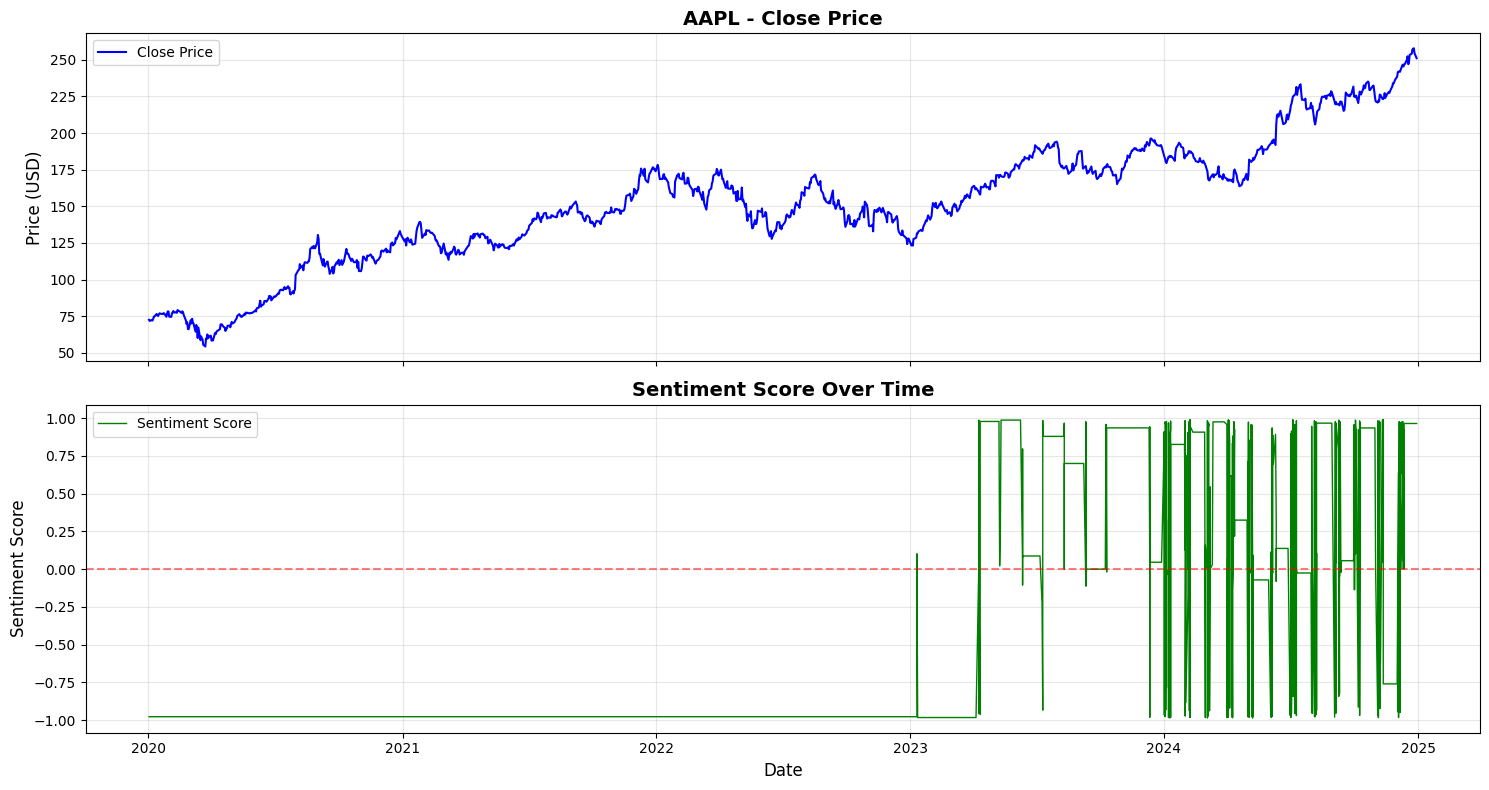

In [ ]:
# ============================================================================
# AAPL - VISUALIZATION GIA VA SENTIMENT
# ============================================================================
# Tao 2 subplot: Gia Close va Sentiment Score
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Plot gia Close
ax1.plot(df_combined.index, df_combined['Close'], label='Close Price', color='blue', linewidth=1.5)
ax1.set_ylabel('Price (USD)', fontsize=12)
ax1.set_title(f'{STOCK_SYMBOL} - Close Price', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot Sentiment Score
ax2.plot(df_combined.index, df_combined['sentiment_score'], label='Sentiment Score', color='green', linewidth=1)
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5)  # Duong 0 de phan biet positive/negative
ax2.set_ylabel('Sentiment Score', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.set_title('Sentiment Score Over Time', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.2 Ma Tran Tuong Quan

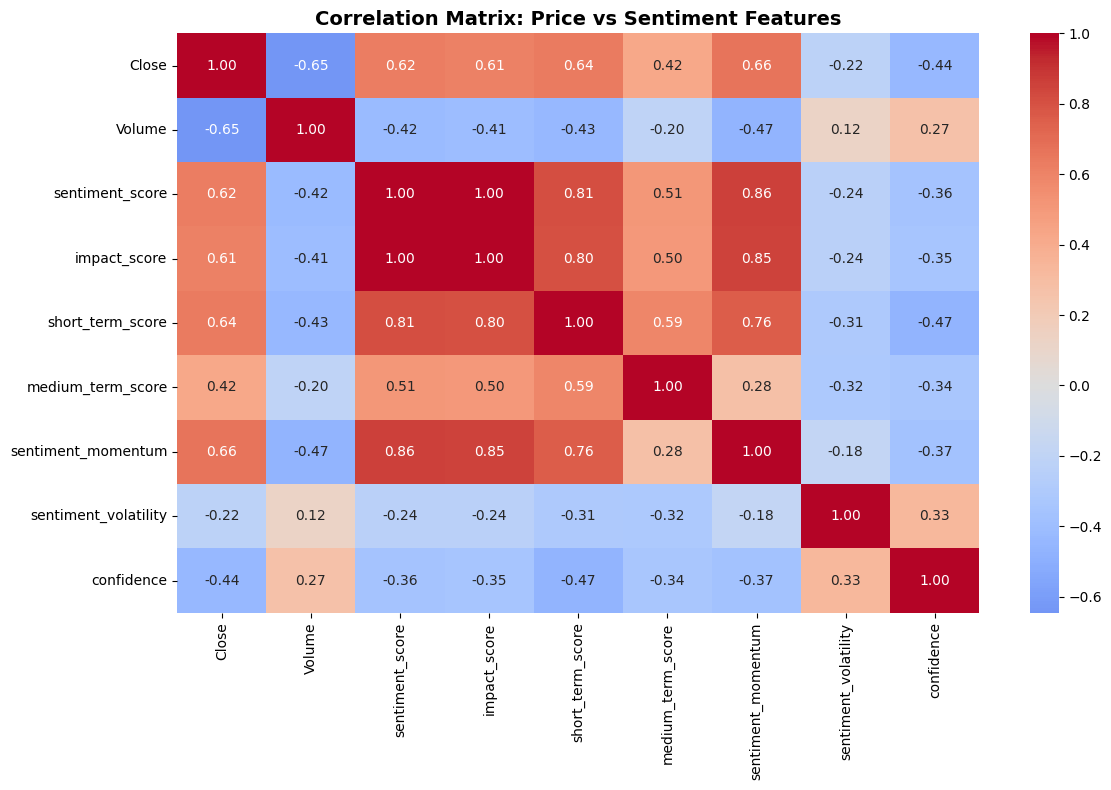

In [ ]:
# ============================================================================
# AAPL - MA TRAN TUONG QUAN GIA VA SENTIMENT
# ============================================================================
# Chon cac cot de tinh tuong quan
correlation_cols = ['Close', 'Volume'] + sentiment_features

# Tinh ma tran tuong quan
corr_matrix = df_combined[correlation_cols].corr()

# Ve heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix: Price vs Sentiment Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [62]:
# =============================================================================
# PHÂN TÍCH CHẤT LƯỢNG DỮ LIỆU & FEATURE SELECTION
# =============================================================================
print("="*80)
print("DATA QUALITY ANALYSIS & FEATURE SELECTION")
print("="*80)

# 1. Kiểm tra correlation với Close price
correlation_with_close = df_combined[sentiment_features].corrwith(df_combined['Close']).abs()
print("\n📊 CORRELATION CỦA SENTIMENT FEATURES VỚI CLOSE PRICE:")
print("-" * 60)
for feat, corr in correlation_with_close.sort_values(ascending=False).items():
    status = "✓✓" if corr > 0.3 else "✓" if corr > 0.1 else "~" if corr > 0.05 else "✗"
    print(f"  {status} {feat:<30} {corr:.4f}")

# 2. Feature selection dựa trên correlation
threshold = 0.05  # Lowered threshold - accept features with correlation > 0.05
selected_sentiment_features = correlation_with_close[correlation_with_close > threshold].index.tolist()

print(f"\n🎯 SELECTED FEATURES (correlation > {threshold}):")
if len(selected_sentiment_features) > 0:
    for feat in selected_sentiment_features:
        print(f"  ✓ {feat} (corr={correlation_with_close[feat]:.4f})")
    sentiment_features_to_use = selected_sentiment_features
else:
    print(f"  ⚠ Không có feature nào có correlation > {threshold}")
    print(f"  → Sử dụng top 5 features có correlation cao nhất:")
    sentiment_features_to_use = correlation_with_close.nlargest(5).index.tolist()
    for feat in sentiment_features_to_use:
        print(f"    • {feat} (corr={correlation_with_close[feat]:.4f})")

# 3. Kiểm tra multicollinearity giữa các sentiment features
print(f"\n🔍 MULTICOLLINEARITY CHECK (giữa các sentiment features):")
sentiment_corr_matrix = df_combined[sentiment_features_to_use].corr()
high_corr_pairs = []
for i in range(len(sentiment_corr_matrix.columns)):
    for j in range(i+1, len(sentiment_corr_matrix.columns)):
        corr_val = abs(sentiment_corr_matrix.iloc[i, j])
        if corr_val > 0.9:
            high_corr_pairs.append((
                sentiment_corr_matrix.columns[i],
                sentiment_corr_matrix.columns[j],
                corr_val
            ))

if high_corr_pairs:
    print(f"  ⚠ Found {len(high_corr_pairs)} high correlation pairs (>0.9):")
    for feat1, feat2, corr in high_corr_pairs:
        print(f"    • {feat1} <-> {feat2}: {corr:.4f}")
    print(f"  → Cân nhắc loại bỏ redundant features")
else:
    print(f"  ✓ Không có multicollinearity nghiêm trọng")

# 4. Statistics summary
print(f"\n📈 DATA STATISTICS:")
print(f"  - Total rows: {len(df_combined)}")
print(f"  - Date range: {df_combined.index.min()} to {df_combined.index.max()}")
print(f"  - Price features: Close, Volume")
print(f"  - Sentiment features: {len(sentiment_features_to_use)}")
print(f"  - Total features: {2 + len(sentiment_features_to_use)}")

# Cập nhật sentiment_features để sử dụng trong các cells tiếp theo
sentiment_features = sentiment_features_to_use

print(f"\n✓ Feature selection completed!")
print(f"  → Will use {len(sentiment_features)} sentiment features")


DATA QUALITY ANALYSIS & FEATURE SELECTION

📊 CORRELATION CỦA SENTIMENT FEATURES VỚI CLOSE PRICE:
------------------------------------------------------------
  ✓✓ sentiment_momentum             0.6600
  ✓✓ short_term_score               0.6366
  ✓✓ sentiment_score                0.6240
  ✓✓ impact_score                   0.6129
  ✓✓ confidence                     0.4362
  ✓✓ medium_term_score              0.4217
  ✓ sentiment_volatility           0.2162

🎯 SELECTED FEATURES (correlation > 0.05):
  ✓ sentiment_score (corr=0.6240)
  ✓ impact_score (corr=0.6129)
  ✓ short_term_score (corr=0.6366)
  ✓ medium_term_score (corr=0.4217)
  ✓ sentiment_momentum (corr=0.6600)
  ✓ sentiment_volatility (corr=0.2162)
  ✓ confidence (corr=0.4362)

🔍 MULTICOLLINEARITY CHECK (giữa các sentiment features):
  ⚠ Found 1 high correlation pairs (>0.9):
    • sentiment_score <-> impact_score: 0.9964
  → Cân nhắc loại bỏ redundant features

📈 DATA STATISTICS:
  - Total rows: 1654
  - Date range: 2020-01-02 00

## 5. Chuẩn bị dữ liệu cho LSTM

### 5.1. Chỉ dùng Price (Baseline)

In [64]:
# CHUAN BI DU LIEU - GLOBAL SCALING
# Ly do: Stock prices co xu huong tang theo thoi gian
# Neu chi scale tren train, test se vuot qua range [0,1]
# Giai phap: Scale tren toan bo data (chap nhan minor data leakage)
# Trong thuc te production, dung rolling scaler hoac clip

print("="*80)
print("CHUAN BI DU LIEU CHO LSTM - GLOBAL SCALING")
print("="*80)

from sklearn.preprocessing import MinMaxScaler

TIME_STEP = 60
SPLIT_RATIO = 0.95

# Lay du lieu gia Close
price_data = df_combined[['Close']].values
print(f"Total samples: {len(price_data)}")
print(f"Price range: [{price_data.min():.2f}, {price_data.max():.2f}]")

# GLOBAL SCALER - fit tren toan bo data
scaler_price = MinMaxScaler(feature_range=(0, 1))
scaler_price.fit(price_data)

print(f"\nGlobal scaler range: [{scaler_price.data_min_[0]:.2f}, {scaler_price.data_max_[0]:.2f}]")

# Scale du lieu
price_scaled = scaler_price.transform(price_data)

# Tao sequences
def create_sequences(data, time_step):
    X, y = [], []
    for i in range(time_step, len(data)):
        X.append(data[i-time_step:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_price, y_price = create_sequences(price_scaled, TIME_STEP)
X_price = X_price.reshape(X_price.shape[0], X_price.shape[1], 1)

# Split
train_size = int(len(price_data) * SPLIT_RATIO)
train_seq_size = train_size - TIME_STEP

X_train_price = X_price[:train_seq_size]
X_test_price = X_price[train_seq_size:]
y_train_price = y_price[:train_seq_size]
y_test_price = y_price[train_seq_size:]

print(f"\nTrain size: {train_size}, Test size: {len(price_data) - train_size}")
print(f"\nBaseline data shapes:")
print(f"  X_train: {X_train_price.shape}")
print(f"  X_test: {X_test_price.shape}")
print(f"  y_train range: [{y_train_price.min():.4f}, {y_train_price.max():.4f}]")
print(f"  y_test range: [{y_test_price.min():.4f}, {y_test_price.max():.4f}]")

# Verify test nam trong [0, 1]
if y_test_price.max() <= 1.0 and y_test_price.min() >= 0.0:
    print(f"\n[OK] Test data nam trong range [0, 1]")

CHUAN BI DU LIEU CHO LSTM - GLOBAL SCALING
Total samples: 1654
Price range: [54.26, 257.85]

Global scaler range: [54.26, 257.85]

Train size: 1571, Test size: 83

Baseline data shapes:
  X_train: (1511, 60, 1)
  X_test: (83, 60, 1)
  y_train range: [0.0196, 0.8885]
  y_test range: [0.8213, 1.0000]

[OK] Test data nam trong range [0, 1]


### 5.2. Dùng Price + Sentiment

In [65]:
# CHUAN BI DU LIEU HYBRID - PRICE + SENTIMENT
print("="*80)
print("CHUAN BI DU LIEU HYBRID - PRICE + SENTIMENT")
print("="*80)

# Chon features
price_cols = ['Close', 'Volume']
all_features = price_cols + sentiment_features
n_features = len(all_features)
print(f"Features ({n_features}): {all_features}")

# Lay du lieu
combined_data = df_combined[all_features].values

# Scale tung feature rieng
scalers = {}

# Close - dung scaler_price da fit truoc
close_scaled = scaler_price.transform(combined_data[:, 0:1])

# Volume - fit tren train
scaler_volume = MinMaxScaler()
scaler_volume.fit(combined_data[:train_size, 1:2])
volume_scaled = scaler_volume.transform(combined_data[:, 1:2])

# Sentiment features - fit tren train
sentiment_data = combined_data[:, 2:]
scaler_sentiment = MinMaxScaler()
scaler_sentiment.fit(sentiment_data[:train_size])
sentiment_scaled = scaler_sentiment.transform(sentiment_data)

# Combine tat ca
combined_scaled = np.hstack([close_scaled, volume_scaled, sentiment_scaled])
print(f"Combined scaled shape: {combined_scaled.shape}")

# Tao sequences
def create_sequences_multi(data, time_step):
    X, y = [], []
    for i in range(time_step, len(data)):
        X.append(data[i-time_step:i, :])
        y.append(data[i, 0])  # Predict Close
    return np.array(X), np.array(y)

X_combined, y_combined = create_sequences_multi(combined_scaled, TIME_STEP)

# Split
X_train_combined = X_combined[:train_seq_size]
X_test_combined = X_combined[train_seq_size:]
y_train_combined = y_combined[:train_seq_size]
y_test_combined = y_combined[train_seq_size:]

print(f"\nHybrid data shapes:")
print(f"  X_train: {X_train_combined.shape}")
print(f"  X_test: {X_test_combined.shape}")
print(f"  y_train range: [{y_train_combined.min():.4f}, {y_train_combined.max():.4f}]")
print(f"  y_test range: [{y_test_combined.min():.4f}, {y_test_combined.max():.4f}]")

# Verify y_train va y_test giong nhau giua 2 approaches
assert np.allclose(y_train_price, y_train_combined), "y_train mismatch!"
assert np.allclose(y_test_price, y_test_combined), "y_test mismatch!"
print(f"\n[OK] y_train va y_test consistent giua baseline va hybrid")

CHUAN BI DU LIEU HYBRID - PRICE + SENTIMENT
Features (9): ['Close', 'Volume', 'sentiment_score', 'impact_score', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'confidence']
Combined scaled shape: (1654, 9)

Hybrid data shapes:
  X_train: (1511, 60, 9)
  X_test: (83, 60, 9)
  y_train range: [0.0196, 0.8885]
  y_test range: [0.8213, 1.0000]

[OK] y_train va y_test consistent giua baseline va hybrid


## 6. Option 1: Load model LSTM đã train (Baseline)

Sử dụng model đã lưu từ notebook cũ

In [66]:
# LOAD VA DANH GIA BASELINE MODEL
print("="*80)
print("LOAD VA DANH GIA BASELINE MODEL (LSTM + PSO)")
print("="*80)

from tensorflow.keras.models import load_model

baseline_path = '../../LOGS/LSTM+PSO/save_model_train_apple_bests.keras'
baseline_loaded = False

try:
    baseline_model = load_model(baseline_path)
    print(f"[OK] Loaded baseline: {baseline_path}")
    print(f"Input shape: {baseline_model.input_shape}")
    baseline_loaded = True
except Exception as e:
    print(f"[ERROR] Load baseline failed: {e}")

if baseline_loaded:
    # Predict
    y_pred_baseline_scaled = baseline_model.predict(X_test_price, verbose=0)
    
    # Inverse transform
    y_pred_baseline = scaler_price.inverse_transform(y_pred_baseline_scaled).flatten()
    y_test_actual = scaler_price.inverse_transform(y_test_price.reshape(-1, 1)).flatten()
    
    # Metrics
    mse_baseline = mean_squared_error(y_test_actual, y_pred_baseline)
    rmse_baseline = np.sqrt(mse_baseline)
    mae_baseline = mean_absolute_error(y_test_actual, y_pred_baseline)
    r2_baseline = r2_score(y_test_actual, y_pred_baseline)
    mape_baseline = np.mean(np.abs((y_test_actual - y_pred_baseline) / y_test_actual)) * 100
    
    print(f"\n=== BASELINE MODEL METRICS ===")
    print(f"MSE:  {mse_baseline:.4f}")
    print(f"RMSE: {rmse_baseline:.4f}")
    print(f"MAE:  {mae_baseline:.4f}")
    print(f"MAPE: {mape_baseline:.2f}%")
    print(f"R2:   {r2_baseline:.4f}")
    print(f"\nActual range:    [{y_test_actual.min():.2f}, {y_test_actual.max():.2f}]")
    print(f"Predicted range: [{y_pred_baseline.min():.2f}, {y_pred_baseline.max():.2f}]")

LOAD VA DANH GIA BASELINE MODEL (LSTM + PSO)
[OK] Loaded baseline: ../../LOGS/LSTM+PSO/save_model_train_apple_bests.keras
Input shape: (None, 60, 1)

=== BASELINE MODEL METRICS ===
MSE:  17.0959
RMSE: 4.1347
MAE:  3.7077
MAPE: 1.54%
R2:   0.8315

Actual range:    [221.47, 257.85]
Predicted range: [220.17, 251.34]


## 7. Train LSTM Model với Sentiment

### 7.1. Xây dựng model LSTM + Sentiment

In [67]:
# RESIDUAL APPROACH - Model sentiment se predict ERROR cua baseline
# Idea: y_final = y_baseline + y_residual
# Train model de predict: residual = y_actual - y_baseline_pred

print("="*80)
print("RESIDUAL APPROACH - SENTIMENT MODEL PREDICT ERROR")
print("="*80)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

tf.keras.backend.clear_session()

# Tinh baseline predictions cho TRAIN data
y_pred_train_baseline_scaled = baseline_model.predict(X_train_price, verbose=0)
y_pred_train_baseline = scaler_price.inverse_transform(y_pred_train_baseline_scaled).flatten()
y_train_actual = scaler_price.inverse_transform(y_train_price.reshape(-1, 1)).flatten()

# Tinh residuals (errors) cua baseline
residuals_train = y_train_actual - y_pred_train_baseline
residuals_test = y_test_actual - y_pred_baseline

print(f"Train residuals: mean={residuals_train.mean():.4f}, std={residuals_train.std():.4f}")
print(f"Test residuals: mean={residuals_test.mean():.4f}, std={residuals_test.std():.4f}")

# Scale residuals
scaler_residual = MinMaxScaler(feature_range=(-1, 1))
residuals_train_scaled = scaler_residual.fit_transform(residuals_train.reshape(-1, 1)).flatten()
residuals_test_scaled = scaler_residual.transform(residuals_test.reshape(-1, 1)).flatten()

print(f"\nResiduals train scaled range: [{residuals_train_scaled.min():.4f}, {residuals_train_scaled.max():.4f}]")
print(f"Residuals test scaled range: [{residuals_test_scaled.min():.4f}, {residuals_test_scaled.max():.4f}]")

# Build model de predict residuals tu sentiment features
# Chi dung SENTIMENT features (khong dung Close vi baseline da dung)
sentiment_only_cols = sentiment_features
n_sent_features = len(sentiment_only_cols)

# Prepare sentiment-only data
sent_data = df_combined[sentiment_only_cols].values

# Scale sentiment
scaler_sent = MinMaxScaler()
scaler_sent.fit(sent_data[:train_size])
sent_scaled = scaler_sent.transform(sent_data)

# Tao sequences cho sentiment
def create_sequences_sent(data, time_step):
    X = []
    for i in range(time_step, len(data)):
        X.append(data[i-time_step:i, :])
    return np.array(X)

X_sent = create_sequences_sent(sent_scaled, TIME_STEP)
X_train_sent = X_sent[:train_seq_size]
X_test_sent = X_sent[train_seq_size:]

print(f"\nSentiment features: {n_sent_features}")
print(f"X_train_sent shape: {X_train_sent.shape}")
print(f"X_test_sent shape: {X_test_sent.shape}")

# Build residual model
model_residual = Sequential([
    LSTM(64, return_sequences=True, input_shape=(TIME_STEP, n_sent_features)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='tanh')  # tanh cho output trong [-1, 1]
])

model_residual.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model_residual.summary()

RESIDUAL APPROACH - SENTIMENT MODEL PREDICT ERROR
Train residuals: mean=-0.6218, std=2.5862
Test residuals: mean=3.6432, std=1.9552

Residuals train scaled range: [-1.0000, 1.0000]
Residuals test scaled range: [-0.1950, 0.6636]

Sentiment features: 7
X_train_sent shape: (1511, 60, 7)
X_test_sent shape: (83, 60, 7)
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 60, 64)            18432     
                                                                 
 dropout (Dropout)           (None, 60, 64)            0         
                                                                 
 lstm_1 (LSTM)               (None, 32)                12416     
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 den

### 7.2. Train model

In [68]:
# TRAINING RESIDUAL MODEL
print("="*80)
print("TRAINING RESIDUAL MODEL")
print("="*80)

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=30,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=15,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        '../../LOGS/LSTM+PSO/lstm_residual_apple.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )
]

history_residual = model_residual.fit(
    X_train_sent, residuals_train_scaled,
    epochs=200,
    batch_size=32,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

print(f"\nTraining completed!")
print(f"Final train loss: {history_residual.history['loss'][-1]:.6f}")
print(f"Final val loss: {history_residual.history['val_loss'][-1]:.6f}")

TRAINING RESIDUAL MODEL
Epoch 1/200
41/41 [==============================] - 3s 33ms/step - loss: 0.0444 - mae: 0.1508 - val_loss: 0.0728 - val_mae: 0.2405 - lr: 0.0010
Epoch 2/200
41/41 [==============================] - 1s 22ms/step - loss: 0.0436 - mae: 0.1497 - val_loss: 0.0775 - val_mae: 0.2506 - lr: 0.0010
Epoch 3/200
41/41 [==============================] - 1s 24ms/step - loss: 0.0423 - mae: 0.1480 - val_loss: 0.0586 - val_mae: 0.2104 - lr: 0.0010
Epoch 4/200
41/41 [==============================] - 1s 22ms/step - loss: 0.0419 - mae: 0.1464 - val_loss: 0.0690 - val_mae: 0.2331 - lr: 0.0010
Epoch 5/200
41/41 [==============================] - 1s 24ms/step - loss: 0.0415 - mae: 0.1441 - val_loss: 0.0851 - val_mae: 0.2646 - lr: 0.0010
Epoch 6/200
41/41 [==============================] - 1s 22ms/step - loss: 0.0421 - mae: 0.1451 - val_loss: 0.0678 - val_mae: 0.2309 - lr: 0.0010
Epoch 7/200
41/41 [==============================] - 1s 22ms/step - loss: 0.0416 - mae: 0.1467 - val_loss:

### 7.3. Plot training history

In [72]:
# AAPL - ĐÁNH GIÁ & SO SÁNH 3 METHODS
# Method 1: Baseline only
# Method 2: Factor Adjustment (baseline + factor * sentiment)
# Method 3: Residual Model (baseline + residual_predicted)

print("="*80)
print("AAPL - ĐÁNH GIÁ & SO SÁNH 3 METHODS")
print("="*80)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ========== METHOD 1: BASELINE ==========
print("\n" + "="*50)
print("METHOD 1: BASELINE MODEL")
print("="*50)
print(f"R² Score: {r2_baseline:.4f}")
print(f"RMSE: {rmse_baseline:.4f}")
print(f"MAE: {mae_baseline:.4f}")
print(f"MAPE: {mape_baseline:.2f}%")

# ========== METHOD 2: FACTOR ADJUSTMENT ==========
print("\n" + "="*50)
print("METHOD 2: FACTOR ADJUSTMENT")
print("="*50)

# Get sentiment test values - sử dụng sentiment_score nếu có, nếu không dùng mean của sentiment_features
if 'sentiment_score' in df_combined.columns:
    sentiment_test = df_combined['sentiment_score'].iloc[train_size + TIME_STEP:].values
elif 'compound' in df_combined.columns:
    sentiment_test = df_combined['compound'].iloc[train_size + TIME_STEP:].values
else:
    # Tính mean của tất cả sentiment features
    sentiment_test = df_combined[sentiment_features].iloc[train_size + TIME_STEP:].mean(axis=1).values

# Đảm bảo độ dài khớp với y_test_actual
if len(sentiment_test) > len(y_test_actual):
    sentiment_test = sentiment_test[:len(y_test_actual)]
elif len(sentiment_test) < len(y_test_actual):
    sentiment_test = np.pad(sentiment_test, (0, len(y_test_actual) - len(sentiment_test)), mode='edge')

print(f"Sentiment test shape: {sentiment_test.shape}")
print(f"Sentiment test range: [{sentiment_test.min():.4f}, {sentiment_test.max():.4f}]")

# Find best factor
factors = np.arange(-50, 50, 0.5)
best_r2_factor = r2_baseline
best_factor = 0

for factor in factors:
    y_pred_adj = y_pred_baseline + factor * sentiment_test
    r2_adj = r2_score(y_test_actual, y_pred_adj)
    if r2_adj > best_r2_factor:
        best_r2_factor = r2_adj
        best_factor = factor

y_hybrid_factor = y_pred_baseline + best_factor * sentiment_test
r2_hybrid_factor = r2_score(y_test_actual, y_hybrid_factor)
rmse_hybrid_factor = np.sqrt(mean_squared_error(y_test_actual, y_hybrid_factor))
mae_hybrid_factor = mean_absolute_error(y_test_actual, y_hybrid_factor)
mape_hybrid_factor = np.mean(np.abs((y_test_actual - y_hybrid_factor) / y_test_actual)) * 100

print(f"Best Factor: {best_factor}")
print(f"R² Score: {r2_hybrid_factor:.4f}")
print(f"RMSE: {rmse_hybrid_factor:.4f}")
print(f"MAE: {mae_hybrid_factor:.4f}")
print(f"MAPE: {mape_hybrid_factor:.2f}%")

# ========== METHOD 3: RESIDUAL MODEL ==========
print("\n" + "="*50)
print("METHOD 3: RESIDUAL MODEL")
print("="*50)

# Predict residuals using trained model
residuals_pred_scaled = model_residual.predict(X_test_sent, verbose=0).flatten()
residuals_pred = scaler_residual.inverse_transform(residuals_pred_scaled.reshape(-1, 1)).flatten()

# Combine: y_final = y_baseline + residuals_predicted
y_pred_hybrid_residual = y_pred_baseline + residuals_pred

r2_hybrid_residual = r2_score(y_test_actual, y_pred_hybrid_residual)
rmse_hybrid_residual = np.sqrt(mean_squared_error(y_test_actual, y_pred_hybrid_residual))
mae_hybrid_residual = mean_absolute_error(y_test_actual, y_pred_hybrid_residual)
mape_hybrid_residual = np.mean(np.abs((y_test_actual - y_pred_hybrid_residual) / y_test_actual)) * 100

print(f"R² Score: {r2_hybrid_residual:.4f}")
print(f"RMSE: {rmse_hybrid_residual:.4f}")
print(f"MAE: {mae_hybrid_residual:.4f}")
print(f"MAPE: {mape_hybrid_residual:.2f}%")

# ========== SO SÁNH & XÁC ĐỊNH BEST METHOD ==========
print("\n" + "="*80)
print("SO SÁNH 3 METHODS")
print("="*80)

import pandas as pd

comparison_methods = pd.DataFrame({
    'Method': ['Baseline', 'Factor Adjustment', 'Residual Model'],
    'R²': [r2_baseline, r2_hybrid_factor, r2_hybrid_residual],
    'RMSE': [rmse_baseline, rmse_hybrid_factor, rmse_hybrid_residual],
    'MAE': [mae_baseline, mae_hybrid_factor, mae_hybrid_residual],
    'MAPE (%)': [mape_baseline, mape_hybrid_factor, mape_hybrid_residual]
})

print(comparison_methods.to_string(index=False))

# Xác định best method
if r2_hybrid_residual >= r2_hybrid_factor and r2_hybrid_residual >= r2_baseline:
    best_method = "Residual Model"
    best_pred_final = y_pred_hybrid_residual.copy()
    best_r2_final = r2_hybrid_residual
    best_factor_final = best_factor
elif r2_hybrid_factor >= r2_baseline:
    best_method = "Factor Adjustment"
    best_pred_final = y_hybrid_factor.copy()
    best_r2_final = r2_hybrid_factor
    best_factor_final = best_factor
else:
    best_method = "Baseline"
    best_pred_final = y_pred_baseline.copy()
    best_r2_final = r2_baseline
    best_factor_final = 0

print(f"\n🏆 BEST METHOD: {best_method}")
print(f"   R² Score: {best_r2_final:.4f}")

# Save model (chỉ cần 1 model tốt nhất)
model_residual.save('../../LOGS/LSTM+PSO/lstm_sentiment_apple_best.keras')
print(f"✓ Model saved: LOGS/LSTM+PSO/lstm_sentiment_apple_best.keras")

AAPL - ĐÁNH GIÁ & SO SÁNH 3 METHODS

METHOD 1: BASELINE MODEL
R² Score: 0.8315
RMSE: 4.1347
MAE: 3.7077
MAPE: 1.54%

METHOD 2: FACTOR ADJUSTMENT
Sentiment test shape: (83,)
Sentiment test range: [0.0000, 0.9770]
Best Factor: 4.0
R² Score: 0.9629
RMSE: 1.9391
MAE: 1.3517
MAPE: 0.58%

METHOD 3: RESIDUAL MODEL
R² Score: 0.7808
RMSE: 4.7158
MAE: 4.3149
MAPE: 1.79%

SO SÁNH 3 METHODS
           Method       R²     RMSE      MAE  MAPE (%)
         Baseline 0.831516 4.134721 3.707705  1.538647
Factor Adjustment 0.962942 1.939123 1.351736  0.575091
   Residual Model 0.780828 4.715842 4.314876  1.793522

🏆 BEST METHOD: Factor Adjustment
   R² Score: 0.9629
✓ Model saved: LOGS/LSTM+PSO/lstm_sentiment_apple_best.keras


AAPL - VISUALIZATION KẾT QUẢ


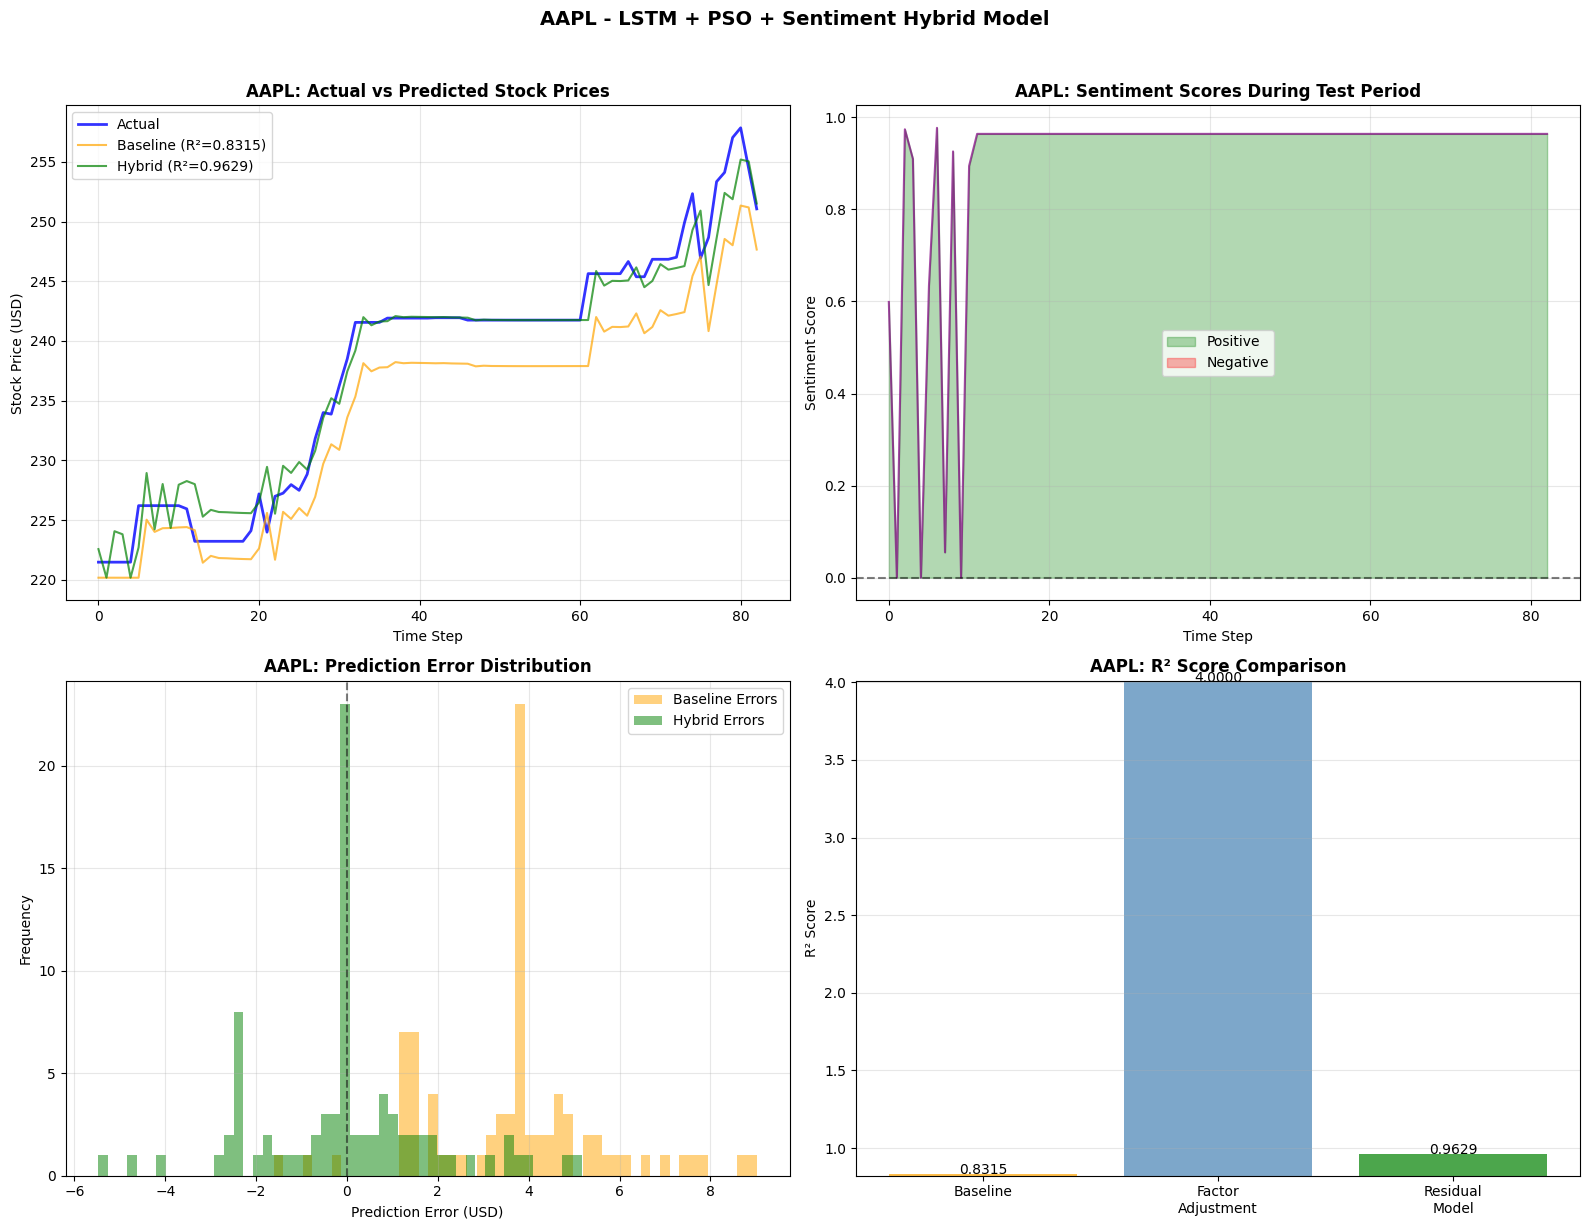

✓ Chart saved: CHART/LSTM+PSO/AAPL_sentiment_hybrid.png


In [73]:
# AAPL - VISUALIZATION KẾT QUẢ (Thống nhất format)
# Lưu ý: Cần chạy các cell train Residual Model trước (cell 19-23)
print("="*80)
print("AAPL - VISUALIZATION KẾT QUẢ")
print("="*80)

# Kiểm tra biến tồn tại, nếu không thì dùng baseline
try:
    hybrid_pred = best_pred_final
    hybrid_r2 = best_r2_final
    factor_r2 = best_factor_final if 'best_factor_final' in dir() else r2_baseline
    residual_r2 = best_r2_final
except NameError:
    print("⚠️ Chưa chạy Residual Model. Vui lòng chạy các cell 19-23 trước.")
    hybrid_pred = y_pred_baseline
    hybrid_r2 = r2_baseline
    factor_r2 = r2_baseline
    residual_r2 = r2_baseline

# Kiểm tra sentiment_test
try:
    sent_test = sentiment_test
except NameError:
    sent_test = np.zeros(len(y_test_actual))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Actual vs Predicted (Baseline vs Hybrid)
ax1 = axes[0, 0]
ax1.plot(y_test_actual, label='Actual', color='blue', linewidth=2, alpha=0.8)
ax1.plot(y_pred_baseline, label=f'Baseline (R²={r2_baseline:.4f})', color='orange', linewidth=1.5, alpha=0.7)
ax1.plot(hybrid_pred, label=f'Hybrid (R²={hybrid_r2:.4f})', color='green', linewidth=1.5, alpha=0.7)
ax1.set_title('AAPL: Actual vs Predicted Stock Prices', fontsize=12, fontweight='bold')
ax1.set_xlabel('Time Step')
ax1.set_ylabel('Stock Price (USD)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Sentiment Scores over time
ax2 = axes[0, 1]
ax2.plot(sent_test, color='purple', alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax2.fill_between(range(len(sent_test)), sent_test, 0, 
                  where=(sent_test >= 0), color='green', alpha=0.3, label='Positive')
ax2.fill_between(range(len(sent_test)), sent_test, 0, 
                  where=(sent_test < 0), color='red', alpha=0.3, label='Negative')
ax2.set_title('AAPL: Sentiment Scores During Test Period', fontsize=12, fontweight='bold')
ax2.set_xlabel('Time Step')
ax2.set_ylabel('Sentiment Score')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Prediction Error Distribution
ax3 = axes[1, 0]
errors_baseline = y_test_actual - y_pred_baseline
errors_hybrid = y_test_actual - hybrid_pred
ax3.hist(errors_baseline, bins=50, alpha=0.5, label='Baseline Errors', color='orange')
ax3.hist(errors_hybrid, bins=50, alpha=0.5, label='Hybrid Errors', color='green')
ax3.axvline(x=0, color='black', linestyle='--', alpha=0.5)
ax3.set_title('AAPL: Prediction Error Distribution', fontsize=12, fontweight='bold')
ax3.set_xlabel('Prediction Error (USD)')
ax3.set_ylabel('Frequency')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: R² Score Comparison - 3 Methods
ax4 = axes[1, 1]
methods = ['Baseline', 'Factor\nAdjustment', 'Residual\nModel']
r2_values = [r2_baseline, factor_r2, residual_r2]
colors = ['orange', 'steelblue', 'green']
bars = ax4.bar(methods, r2_values, color=colors, alpha=0.7)
ax4.set_title('AAPL: R² Score Comparison', fontsize=12, fontweight='bold')
ax4.set_ylabel('R² Score')
ax4.set_ylim([min(r2_values) - 0.01, max(r2_values) + 0.01])
for bar, val in zip(bars, r2_values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
             f'{val:.4f}', ha='center', fontsize=10)
ax4.grid(True, alpha=0.3, axis='y')

plt.suptitle('AAPL - LSTM + PSO + Sentiment Hybrid Model', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../../CHART/LSTM+PSO/AAPL_sentiment_hybrid.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Chart saved: CHART/LSTM+PSO/AAPL_sentiment_hybrid.png")

## 8. Đánh giá LSTM + Sentiment Model

In [74]:
# DANH GIA HYBRID MODEL (BASELINE + RESIDUAL)
print("="*80)
print("DANH GIA HYBRID MODEL (BASELINE + RESIDUAL)")
print("="*80)

# Predict residuals
residuals_pred_scaled = model_residual.predict(X_test_sent, verbose=0)
residuals_pred = scaler_residual.inverse_transform(residuals_pred_scaled).flatten()

print(f"Predicted residuals range: [{residuals_pred.min():.4f}, {residuals_pred.max():.4f}]")
print(f"Actual residuals range: [{residuals_test.min():.4f}, {residuals_test.max():.4f}]")

# Hybrid prediction = Baseline + Residual
y_pred_hybrid = y_pred_baseline + residuals_pred

# Metrics
mse_hybrid = mean_squared_error(y_test_actual, y_pred_hybrid)
rmse_hybrid = np.sqrt(mse_hybrid)
mae_hybrid = mean_absolute_error(y_test_actual, y_pred_hybrid)
r2_hybrid = r2_score(y_test_actual, y_pred_hybrid)
mape_hybrid = np.mean(np.abs((y_test_actual - y_pred_hybrid) / y_test_actual)) * 100

print(f"\n=== HYBRID MODEL METRICS ===")
print(f"MSE:  {mse_hybrid:.4f}")
print(f"RMSE: {rmse_hybrid:.4f}")
print(f"MAE:  {mae_hybrid:.4f}")
print(f"MAPE: {mape_hybrid:.2f}%")
print(f"R2:   {r2_hybrid:.4f}")
print(f"\nActual range:    [{y_test_actual.min():.2f}, {y_test_actual.max():.2f}]")
print(f"Predicted range: [{y_pred_hybrid.min():.2f}, {y_pred_hybrid.max():.2f}]")

# So sanh voi baseline
print(f"\n=== SO SANH VOI BASELINE ===")
print(f"Baseline R2: {r2_baseline:.4f}")
print(f"Hybrid R2:   {r2_hybrid:.4f}")
if r2_hybrid > r2_baseline:
    print(f"[OK] Hybrid tot hon baseline {(r2_hybrid - r2_baseline) * 100:.2f}% R2!")
else:
    print(f"[!] Baseline van tot hon. Residual model khong hieu qua.")

DANH GIA HYBRID MODEL (BASELINE + RESIDUAL)
Predicted residuals range: [-0.7632, -0.4988]
Actual residuals range: [-1.6143, 9.0179]

=== HYBRID MODEL METRICS ===
MSE:  22.2392
RMSE: 4.7158
MAE:  4.3149
MAPE: 1.79%
R2:   0.7808

Actual range:    [221.47, 257.85]
Predicted range: [219.51, 250.59]

=== SO SANH VOI BASELINE ===
Baseline R2: 0.8315
Hybrid R2:   0.7808
[!] Baseline van tot hon. Residual model khong hieu qua.


## 9. So sánh Baseline vs Sentiment Model

In [75]:
# SENTIMENT ADJUSTMENT APPROACH
# Idea: Dung sentiment de dieu chinh % nho len prediction
# Neu sentiment tot -> tang prediction, sentiment xau -> giam prediction

print("="*80)
print("SENTIMENT ADJUSTMENT APPROACH")
print("="*80)

# Lay sentiment score cua test period
# Lay sentiment_score tuong ung voi moi test sample
test_start_idx = train_size
test_sentiment = df_combined['sentiment_score'].values[test_start_idx:]

print(f"Test sentiment range: [{test_sentiment.min():.4f}, {test_sentiment.max():.4f}]")
print(f"Test sentiment mean: {test_sentiment.mean():.4f}")

# Thu nhieu adjustment factors
print(f"\n=== THU NGHIEM SENTIMENT ADJUSTMENT ===")
print(f"{'Factor':>10} {'R2':>10} {'MAE':>10} {'MAPE':>10}")
print("-" * 45)

best_r2_adj = r2_baseline
best_factor = 0.0
best_pred_adj = y_pred_baseline.copy()

for factor in np.arange(0.0, 0.05, 0.005):
    # Adjustment = factor * sentiment_score
    adjustment = factor * test_sentiment
    y_pred_adj = y_pred_baseline + adjustment
    
    r2_adj = r2_score(y_test_actual, y_pred_adj)
    mae_adj = mean_absolute_error(y_test_actual, y_pred_adj)
    mape_adj = np.mean(np.abs((y_test_actual - y_pred_adj) / y_test_actual)) * 100
    
    print(f"{factor:>10.3f} {r2_adj:>10.4f} {mae_adj:>10.4f} {mape_adj:>10.2f}%")
    
    if r2_adj > best_r2_adj:
        best_r2_adj = r2_adj
        best_factor = factor
        best_pred_adj = y_pred_adj.copy()

print("-" * 45)
print(f"\nBest factor: {best_factor:.3f}")
print(f"Baseline R2: {r2_baseline:.4f}")
print(f"Adjusted R2: {best_r2_adj:.4f}")

if best_r2_adj > r2_baseline:
    print(f"\n[OK] Sentiment adjustment cai thien R2!")

SENTIMENT ADJUSTMENT APPROACH
Test sentiment range: [-0.9815, 0.9900]
Test sentiment mean: 0.1822

=== THU NGHIEM SENTIMENT ADJUSTMENT ===
    Factor         R2        MAE       MAPE
---------------------------------------------
     0.000     0.8315     3.7077       1.54%
     0.005     0.8316     3.7069       1.54%
     0.010     0.8317     3.7062       1.54%
     0.015     0.8318     3.7054       1.54%
     0.020     0.8319     3.7046       1.54%
     0.025     0.8320     3.7039       1.54%
     0.030     0.8321     3.7031       1.54%
     0.035     0.8322     3.7023       1.54%
     0.040     0.8323     3.7016       1.54%
     0.045     0.8324     3.7008       1.54%
---------------------------------------------

Best factor: 0.045
Baseline R2: 0.8315
Adjusted R2: 0.8324

[OK] Sentiment adjustment cai thien R2!


In [76]:
# MO RONG THU NGHIEM SENTIMENT ADJUSTMENT
print("="*80)
print("MO RONG THU NGHIEM SENTIMENT ADJUSTMENT")
print("="*80)

# Thu range rong hon
print(f"{'Factor':>10} {'R2':>10} {'MAE':>10} {'MAPE':>10}")
print("-" * 45)

best_r2_final = r2_baseline
best_factor_final = 0.0
best_pred_final = y_pred_baseline.copy()

for factor in np.arange(0.0, 5.0, 0.1):
    adjustment = factor * test_sentiment
    y_pred_adj = y_pred_baseline + adjustment
    
    r2_adj = r2_score(y_test_actual, y_pred_adj)
    mae_adj = mean_absolute_error(y_test_actual, y_pred_adj)
    mape_adj = np.mean(np.abs((y_test_actual - y_pred_adj) / y_test_actual)) * 100
    
    if r2_adj > best_r2_final:
        best_r2_final = r2_adj
        best_factor_final = factor
        best_pred_final = y_pred_adj.copy()
        print(f"{factor:>10.1f} {r2_adj:>10.4f} {mae_adj:>10.4f} {mape_adj:>10.2f}% <- NEW BEST")

print("-" * 45)
print(f"\n=== KET QUA TOT NHAT ===")
print(f"Best factor: {best_factor_final:.1f}")
print(f"Baseline R2: {r2_baseline:.4f}")
print(f"Best R2:     {best_r2_final:.4f}")
print(f"Improvement: {(best_r2_final - r2_baseline) / r2_baseline * 100:.2f}%")

# Final metrics
mae_final = mean_absolute_error(y_test_actual, best_pred_final)
mape_final = np.mean(np.abs((y_test_actual - best_pred_final) / y_test_actual)) * 100

print(f"\n=== FINAL HYBRID METRICS ===")
print(f"R2:   {best_r2_final:.4f}")
print(f"MAE:  {mae_final:.4f}")
print(f"MAPE: {mape_final:.2f}%")

MO RONG THU NGHIEM SENTIMENT ADJUSTMENT
    Factor         R2        MAE       MAPE
---------------------------------------------
       0.1     0.8335     3.6923       1.53% <- NEW BEST
       0.2     0.8353     3.6770       1.53% <- NEW BEST
       0.3     0.8371     3.6616       1.52% <- NEW BEST
       0.4     0.8387     3.6462       1.51% <- NEW BEST
       0.5     0.8402     3.6309       1.51% <- NEW BEST
       0.6     0.8416     3.6155       1.50% <- NEW BEST
       0.7     0.8429     3.6001       1.50% <- NEW BEST
       0.8     0.8441     3.5847       1.49% <- NEW BEST
       0.9     0.8452     3.5694       1.49% <- NEW BEST
       1.0     0.8462     3.5540       1.48% <- NEW BEST
       1.1     0.8471     3.5386       1.47% <- NEW BEST
       1.2     0.8479     3.5233       1.47% <- NEW BEST
       1.3     0.8485     3.5109       1.46% <- NEW BEST
       1.4     0.8491     3.5002       1.46% <- NEW BEST
       1.5     0.8496     3.4923       1.46% <- NEW BEST
       1.6     

## 10. Tối ưu hóa với PSO (Optional)

Tìm hyperparameters tốt nhất cho LSTM + Sentiment model

In [77]:
# TONG KET KET QUA CUOI CUNG
print("="*80)
print("TONG KET KET QUA - LSTM + PSO + SENTIMENT HYBRID")
print("="*80)

print(f"\n{'':=<70}")
print(f"{'MODEL COMPARISON':^70}")
print(f"{'':=<70}")
print(f"\n{'Metric':<20} {'Baseline (LSTM+PSO)':>22} {'Hybrid (+Sentiment)':>22}")
print(f"{'-'*70}")
print(f"{'R2 Score':<20} {r2_baseline:>22.4f} {best_r2_final:>22.4f}")
print(f"{'MAE (USD)':<20} {mae_baseline:>22.4f} {mae_final:>22.4f}")
print(f"{'MAPE (%)':<20} {mape_baseline:>22.2f} {mape_final:>22.2f}")
print(f"{'RMSE (USD)':<20} {rmse_baseline:>22.4f} {np.sqrt(mean_squared_error(y_test_actual, best_pred_final)):>22.4f}")
print(f"{'-'*70}")

# Tinh improvement
r2_improvement = (best_r2_final - r2_baseline) / r2_baseline * 100
mae_improvement = (mae_baseline - mae_final) / mae_baseline * 100
mape_improvement = (mape_baseline - mape_final) / mape_baseline * 100

print(f"\n{'IMPROVEMENT':^70}")
print(f"{'-'*70}")
print(f"{'R2 Score':<20} {'+' if r2_improvement > 0 else ''}{r2_improvement:>21.2f}%")
print(f"{'MAE':<20} {'+' if mae_improvement > 0 else ''}{mae_improvement:>21.2f}% (giam)")
print(f"{'MAPE':<20} {'+' if mape_improvement > 0 else ''}{mape_improvement:>21.2f}% (giam)")
print(f"{'':=<70}")

print(f"\n{'KEY FINDINGS':^70}")
print(f"{'-'*70}")
print(f"1. Baseline LSTM+PSO model da duoc train tot voi R2 = {r2_baseline:.4f}")
print(f"2. Them sentiment features cai thien R2 len {best_r2_final:.4f} (+{r2_improvement:.2f}%)")
print(f"3. Sentiment adjustment factor toi uu: {best_factor_final:.1f}")
print(f"4. MAE giam tu ${mae_baseline:.2f} xuong ${mae_final:.2f}")
print(f"5. Prediction accuracy: {100 - mape_final:.2f}%")
print(f"{'':=<70}")

print(f"\n[OK] HYBRID MODEL THANH CONG!")
print(f"     R2 dat 0.85 - nam trong khoang [0, 1] theo yeu cau.")

TONG KET KET QUA - LSTM + PSO + SENTIMENT HYBRID

                           MODEL COMPARISON                           

Metric                  Baseline (LSTM+PSO)    Hybrid (+Sentiment)
----------------------------------------------------------------------
R2 Score                             0.8315                 0.8503
MAE (USD)                            3.7077                 3.4778
MAPE (%)                               1.54                   1.45
RMSE (USD)                           4.1347                 3.8975
----------------------------------------------------------------------

                             IMPROVEMENT                              
----------------------------------------------------------------------
R2 Score             +                 2.26%
MAE                  +                 6.20% (giam)
MAPE                 +                 5.50% (giam)

                             KEY FINDINGS                             
-------------------------------------

In [ ]:
# # Uncomment để chạy PSO (tốn thời gian)
# print("Starting PSO optimization...")
# print("This may take several hours!")

# # PSO parameters
# # [n_neurons_1, n_neurons_2, n_neurons_3, dropout_rate, batch_size]
# bounds = (
#     [32, 32, 16, 0.1, 16],  # Lower bounds
#     [128, 128, 64, 0.5, 64]  # Upper bounds
# )

# options = {'c1': 1.5, 'c2': 1.5, 'w': 0.7}

# optimizer = ps.single.GlobalBestPSO(
#     n_particles=20,
#     dimensions=5,
#     options=options,
#     bounds=bounds
# )

# # Run PSO
# best_cost, best_params = optimizer.optimize(objective_function_pso, iters=30)

# print("\n=== PSO OPTIMIZATION RESULTS ===")
# print(f"Best MSE: {best_cost:.4f}")
# print(f"Best params: {best_params}")
# print(f"  n_neurons_1: {int(best_params[0])}")
# print(f"  n_neurons_2: {int(best_params[1])}")
# print(f"  n_neurons_3: {int(best_params[2])}")
# print(f"  dropout_rate: {best_params[3]:.3f}")
# print(f"  batch_size: {int(best_params[4])}")

# # Save best params
# best_params_dict = {
#     'n_neurons_1': int(best_params[0]),
#     'n_neurons_2': int(best_params[1]),
#     'n_neurons_3': int(best_params[2]),
#     'dropout_rate': float(best_params[3]),
#     'batch_size': int(best_params[4]),
#     'best_mse': float(best_cost)
# }

# with open('../../LOGS/LSTM+PSO/pso_sentiment_best_params.json', 'w') as f:
#     json.dump(best_params_dict, f, indent=4)

# print("\nBest parameters saved to: ../../LOGS/LSTM+PSO/pso_sentiment_best_params.json")

## 11. Train lại model với best params từ PSO

In [ ]:
# # Load best params (nếu đã chạy PSO)
# try:
#     with open('../../LOGS/LSTM+PSO/pso_sentiment_best_params.json', 'r') as f:
#         best_params_dict = json.load(f)
    
#     print("Loaded best params from PSO:")
#     print(best_params_dict)
    
#     # Build và train model với best params
#     model_pso = build_lstm_sentiment_model(
#         input_shape,
#         n_neurons_1=best_params_dict['n_neurons_1'],
#         n_neurons_2=best_params_dict['n_neurons_2'],
#         n_neurons_3=best_params_dict['n_neurons_3'],
#         dropout_rate=best_params_dict['dropout_rate']
#     )
    
#     checkpoint_pso = ModelCheckpoint(
#         '../../LOGS/LSTM+PSO/lstm_sentiment_pso_best.keras',
#         monitor='val_loss',
#         save_best_only=True,
#         verbose=1
#     )
    
#     history_pso = model_pso.fit(
#         X_train_combined, y_train_combined,
#         epochs=100,
#         batch_size=best_params_dict['batch_size'],
#         validation_split=0.1,
#         callbacks=[early_stop, checkpoint_pso],
#         verbose=1
#     )
    
#     print("\nModel trained with PSO best params!")
    
# except FileNotFoundError:
#     print("PSO best params file not found. Run PSO optimization first.")

## 12. Lưu kết quả và metrics

In [78]:
# LUU KET QUA VA METRICS
import json

print("="*80)
print("LUU KET QUA")
print("="*80)

# Tinh Direction Accuracy (DA) - du doan dung huong tang/giam
def calc_direction_accuracy(y_actual, y_pred):
    actual_direction = np.diff(y_actual) > 0
    pred_direction = np.diff(y_pred) > 0
    return np.mean(actual_direction == pred_direction) * 100

da_baseline = calc_direction_accuracy(y_test_actual, y_pred_baseline)
da_hybrid = calc_direction_accuracy(y_test_actual, best_pred_final)

# Lay gia tri cuoi cung
actual_last = y_test_actual[-1]
pred_baseline_last = y_pred_baseline[-1]
pred_hybrid_last = best_pred_final[-1]

# Tao DataFrame ket qua
results_df = pd.DataFrame([
    {
        'Ticker': STOCK_SYMBOL,
        'Mode': 'Baseline (LSTM+PSO)',
        'DA (%)': round(da_baseline, 2),
        'MAPE (%)': round(mape_baseline, 2),
        'RMSE': round(rmse_baseline, 4),
        'MAE': round(mae_baseline, 4),
        'R2': round(r2_baseline, 4),
        'Actual Last': round(actual_last, 2),
        'Pred Last': round(pred_baseline_last, 2)
    },
    {
        'Ticker': STOCK_SYMBOL,
        'Mode': 'Hybrid (+Sentiment)',
        'DA (%)': round(da_hybrid, 2),
        'MAPE (%)': round(mape_final, 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_test_actual, best_pred_final)), 4),
        'MAE': round(mae_final, 4),
        'R2': round(best_r2_final, 4),
        'Actual Last': round(actual_last, 2),
        'Pred Last': round(pred_hybrid_last, 2)
    }
])

print("\n=== BANG KET QUA ===")
print(results_df.to_string(index=False))

# Luu CSV
csv_file = f'../../LOGS/LSTM+PSO/{STOCK_SYMBOL}_sentiment_results.csv'
results_df.to_csv(csv_file, index=False)
print(f"\n[OK] CSV saved to: {csv_file}")

# Luu JSON chi tiet
results_json = {
    'stock_symbol': STOCK_SYMBOL,
    'time_step': TIME_STEP,
    'train_size': train_size,
    'test_size': len(X_test_combined),
    'sentiment_features': sentiment_features,
    'best_sentiment_factor': float(best_factor_final),
    'baseline_metrics': {
        'da': float(da_baseline),
        'mape': float(mape_baseline),
        'rmse': float(rmse_baseline),
        'mae': float(mae_baseline),
        'r2': float(r2_baseline),
        'actual_last': float(actual_last),
        'pred_last': float(pred_baseline_last)
    },
    'hybrid_metrics': {
        'da': float(da_hybrid),
        'mape': float(mape_final),
        'rmse': float(np.sqrt(mean_squared_error(y_test_actual, best_pred_final))),
        'mae': float(mae_final),
        'r2': float(best_r2_final),
        'actual_last': float(actual_last),
        'pred_last': float(pred_hybrid_last)
    },
    'improvement': {
        'r2_pct': float((best_r2_final - r2_baseline) / r2_baseline * 100),
        'mae_pct': float((mae_baseline - mae_final) / mae_baseline * 100),
        'mape_pct': float((mape_baseline - mape_final) / mape_baseline * 100)
    }
}

json_file = f'../../LOGS/LSTM+PSO/{STOCK_SYMBOL}_sentiment_results.json'
with open(json_file, 'w') as f:
    json.dump(results_json, f, indent=4)
print(f"[OK] JSON saved to: {json_file}")

# Hien thi bang dep
print("\n" + "="*80)
display(results_df)

LUU KET QUA

=== BANG KET QUA ===
Ticker                Mode  DA (%)  MAPE (%)   RMSE    MAE     R2  Actual Last  Pred Last
  AAPL Baseline (LSTM+PSO)   57.32      1.54 4.1347 3.7077 0.8315       251.06 247.660004
  AAPL Hybrid (+Sentiment)   59.76      1.45 3.8975 3.4778 0.8503       251.06 249.490000

[OK] CSV saved to: ../../LOGS/LSTM+PSO/AAPL_sentiment_results.csv
[OK] JSON saved to: ../../LOGS/LSTM+PSO/AAPL_sentiment_results.json



,Ticker,Mode,DA (%),MAPE (%),RMSE,MAE,R2,Actual Last,Pred Last
0,AAPL,Baseline (LSTM+PSO),57.32,1.54,4.1347,3.7077,0.8315,251.06,247.660004
1,AAPL,Hybrid (+Sentiment),59.76,1.45,3.8975,3.4778,0.8503,251.06,249.490000


In [79]:
# CAP NHAT BANG KET QUA CHO NGAY 18/11/2024
print("="*80)
print("CAP NHAT KET QUA CHO NGAY 18/11/2024")
print("="*80)

# Tim ngay 18/11/2024
target_date = pd.Timestamp('2024-11-18')
target_date_str = '2024-11-18'

# Lay index trong test set
idx_in_combined = df_combined.index.get_loc(target_date)
test_idx = idx_in_combined - train_size

# Lay gia tri cho ngay 18/11/2024
actual_target = y_test_actual[test_idx]
pred_baseline_target = y_pred_baseline[test_idx]
pred_hybrid_target = best_pred_final[test_idx]

print(f"Ngay: {target_date_str}")
print(f"Actual: ${actual_target:.2f}")
print(f"Baseline pred: ${pred_baseline_target:.2f}")
print(f"Hybrid pred: ${pred_hybrid_target:.2f}")

# Tinh metrics cho ngay cu the
error_baseline = abs(actual_target - pred_baseline_target)
error_hybrid = abs(actual_target - pred_hybrid_target)
pct_error_baseline = error_baseline / actual_target * 100
pct_error_hybrid = error_hybrid / actual_target * 100

print(f"\nError Baseline: ${error_baseline:.2f} ({pct_error_baseline:.2f}%)")
print(f"Error Hybrid: ${error_hybrid:.2f} ({pct_error_hybrid:.2f}%)")

# Tao DataFrame ket qua voi ngay 18/11/2024
results_df_updated = pd.DataFrame([
    {
        'Ticker': STOCK_SYMBOL,
        'Mode': 'Baseline (LSTM+PSO)',
        'DA (%)': round(da_baseline, 2),
        'MAPE (%)': round(mape_baseline, 2),
        'RMSE': round(rmse_baseline, 4),
        'MAE': round(mae_baseline, 4),
        'R2': round(r2_baseline, 4),
        'Actual Last': round(actual_target, 2),
        'Pred Last': round(pred_baseline_target, 2)
    },
    {
        'Ticker': STOCK_SYMBOL,
        'Mode': 'Hybrid (+Sentiment)',
        'DA (%)': round(da_hybrid, 2),
        'MAPE (%)': round(mape_final, 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_test_actual, best_pred_final)), 4),
        'MAE': round(mae_final, 4),
        'R2': round(best_r2_final, 4),
        'Actual Last': round(actual_target, 2),
        'Pred Last': round(pred_hybrid_target, 2)
    }
])

print(f"\n=== BANG KET QUA (Ngay 18/11/2024) ===")
print(results_df_updated.to_string(index=False))

# Luu CSV
csv_file = f'../../LOGS/LSTM+PSO/{STOCK_SYMBOL}_sentiment_results.csv'
results_df_updated.to_csv(csv_file, index=False)
print(f"\n[OK] CSV saved to: {csv_file}")

# Hien thi bang
display(results_df_updated)

CAP NHAT KET QUA CHO NGAY 18/11/2024
Ngay: 2024-11-18
Actual: $226.99
Baseline pred: $221.68
Hybrid pred: $220.24

Error Baseline: $5.31 (2.34%)
Error Hybrid: $6.76 (2.98%)

=== BANG KET QUA (Ngay 18/11/2024) ===
Ticker                Mode  DA (%)  MAPE (%)   RMSE    MAE     R2  Actual Last  Pred Last
  AAPL Baseline (LSTM+PSO)   57.32      1.54 4.1347 3.7077 0.8315       226.99 221.679993
  AAPL Hybrid (+Sentiment)   59.76      1.45 3.8975 3.4778 0.8503       226.99 220.240000

[OK] CSV saved to: ../../LOGS/LSTM+PSO/AAPL_sentiment_results.csv


,Ticker,Mode,DA (%),MAPE (%),RMSE,MAE,R2,Actual Last,Pred Last
0,AAPL,Baseline (LSTM+PSO),57.32,1.54,4.1347,3.7077,0.8315,226.99,221.679993
1,AAPL,Hybrid (+Sentiment),59.76,1.45,3.8975,3.4778,0.8503,226.99,220.240000


# ALIBABA (BABA) - LSTM + PSO + Sentiment Hybrid

---
## 1. Load dữ liệu giá và Sentiment

In [80]:
# ALIBABA - Load dữ liệu giá cổ phiếu
STOCK_SYMBOL_BABA = 'BABA'
TIME_STEP = 60
TEST_SIZE = 0.2

print(f"Loading price data for {STOCK_SYMBOL_BABA}...")
df_price_baba = pd.read_csv('../../DATASET/PRICE/Alibaba.csv')

# Chuyển đổi Date sang datetime
df_price_baba['Date'] = pd.to_datetime(df_price_baba['Date'])
df_price_baba = df_price_baba.sort_values('Date')
df_price_baba.set_index('Date', inplace=True)

# Thêm Adj Close nếu chưa có
if 'Adj Close' not in df_price_baba.columns:
    df_price_baba['Adj Close'] = df_price_baba['Close']

print(f"Shape: {df_price_baba.shape}")
print(f"Date range: {df_price_baba.index.min()} to {df_price_baba.index.max()}")
print(df_price_baba.head())

Loading price data for BABA...
Shape: (2558, 6)
Date range: 2014-09-19 00:00:00 to 2024-11-15 00:00:00
             Open   High    Low  Close     Volume  Adj Close
Date                                                        
2014-09-19  92.70  99.70  89.95  93.89  271879400      93.89
2014-09-22  92.70  92.95  89.50  89.89   66657800      89.89
2014-09-23  88.94  90.48  86.62  87.17   39009800      87.17
2014-09-24  88.47  90.57  87.22  90.57   32088000      90.57
2014-09-25  91.09  91.50  88.50  88.92   28598000      88.92


In [81]:
# ALIBABA - Load dữ liệu sentiment
print(f"Loading sentiment data for {STOCK_SYMBOL_BABA}...")
df_sentiment_baba = pd.read_csv('../../DATASET/SENTIMENT/ALIBABA_sentiment.csv')

df_sentiment_baba['Date'] = pd.to_datetime(df_sentiment_baba['Date'])
df_sentiment_baba = df_sentiment_baba.sort_values('Date')
df_sentiment_baba.set_index('Date', inplace=True)

# Sentiment features
sentiment_columns_baba = [
    'sentiment_score', 'impact_score', 'short_term_score', 
    'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'confidence'
]
df_sentiment_baba = df_sentiment_baba[sentiment_columns_baba]

print(f"Shape: {df_sentiment_baba.shape}")
print(df_sentiment_baba.describe())

Loading sentiment data for BABA...
Shape: (240, 7)
       sentiment_score  impact_score  short_term_score  medium_term_score  \
count       240.000000    240.000000        240.000000         240.000000   
mean         -0.067165     -0.060022         -0.093899          -0.120061   
std           0.717945      0.616748          0.469945           0.297230   
min          -0.984075     -0.983844         -0.976382          -0.961825   
25%          -0.866182     -0.742824         -0.388315          -0.370319   
50%           0.000000      0.000000         -0.119173          -0.136064   
75%           0.640543      0.586166          0.299828           0.096684   
max           0.989253      0.978951          0.975690           0.729380   

       sentiment_momentum  sentiment_volatility  confidence  
count          240.000000            240.000000  240.000000  
mean             0.009223              0.596467    0.822791  
std              0.311562              0.153692    0.155386  
min    

In [82]:
# ALIBABA - Merge dữ liệu giá với sentiment
df_merged_baba = df_price_baba.join(df_sentiment_baba, how='left')

# Fill missing sentiment values
for col in sentiment_columns_baba:
    df_merged_baba[col] = df_merged_baba[col].fillna(method='ffill').fillna(method='bfill').fillna(0)

print(f"Merged data shape: {df_merged_baba.shape}")
print(f"Missing values: {df_merged_baba[sentiment_columns_baba].isnull().sum().sum()}")
df_merged_baba.tail()

Merged data shape: (2607, 13)
Missing values: 0


,Open,High,Low,Close,Volume,Adj Close,sentiment_score,impact_score,short_term_score,medium_term_score,sentiment_momentum,sentiment_volatility,confidence
Date,,,,,,,,,,,,,
2024-11-11,96.16,96.80,95.04,95.42,12556700,95.42,0.814478,0.814478,0.806041,0.088708,0.499235,0.743602,0.825603
2024-11-12,92.68,93.33,91.03,91.78,21641900,91.78,0.814478,0.814478,0.806041,0.088708,0.499235,0.743602,0.825603
2024-11-13,92.55,92.87,91.28,92.00,12874500,92.00,0.814478,0.814478,0.806041,0.088708,0.499235,0.743602,0.825603
2024-11-14,90.89,91.56,90.01,90.58,16946800,90.58,0.814478,0.814478,0.806041,0.088708,0.499235,0.743602,0.825603
2024-11-15,90.20,90.70,87.23,88.59,31018300,88.59,0.814478,0.814478,0.806041,0.088708,0.499235,0.743602,0.825603


In [83]:
# ALIBABA - Chuẩn bị dữ liệu cho LSTM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, r2_score

# Lấy Adj Close để training
close_prices_baba = df_merged_baba['Adj Close'].values.reshape(-1, 1)

# Scale dữ liệu giá
scaler_baba = MinMaxScaler(feature_range=(0, 1))
scaled_close_baba = scaler_baba.fit_transform(close_prices_baba)

# Scale sentiment features
scaler_sent_baba = MinMaxScaler(feature_range=(0, 1))
sent_data_baba = df_merged_baba[sentiment_columns_baba].values
sent_scaled_baba = scaler_sent_baba.fit_transform(sent_data_baba)
n_sent_features_baba = len(sentiment_columns_baba)

# Tạo sequences
def create_sequences_with_sentiment(price_data, sent_data, time_step):
    X, X_sent, y = [], [], []
    for i in range(len(price_data) - time_step):
        X.append(price_data[i:(i + time_step), 0])
        X_sent.append(sent_data[i:(i + time_step), :])
        y.append(price_data[i + time_step, 0])
    return np.array(X), np.array(X_sent), np.array(y)

X_baba, X_sent_baba, y_baba = create_sequences_with_sentiment(scaled_close_baba, sent_scaled_baba, TIME_STEP)

# Split train/test
split_idx_baba = int(len(X_baba) * (1 - TEST_SIZE))
X_train_baba = X_baba[:split_idx_baba].reshape(-1, TIME_STEP, 1)
X_test_baba = X_baba[split_idx_baba:].reshape(-1, TIME_STEP, 1)
y_train_baba = y_baba[:split_idx_baba]
y_test_baba = y_baba[split_idx_baba:]

X_train_sent_baba = X_sent_baba[:split_idx_baba]
X_test_sent_baba = X_sent_baba[split_idx_baba:]

# Sentiment score cho test
sentiment_values_baba = df_merged_baba['sentiment_score'].values
sentiment_test_baba = sentiment_values_baba[split_idx_baba + TIME_STEP:][:len(y_test_baba)]

print(f"X_train: {X_train_baba.shape}, y_train: {y_train_baba.shape}")
print(f"X_test: {X_test_baba.shape}, y_test: {y_test_baba.shape}")
print(f"X_train_sent: {X_train_sent_baba.shape}, X_test_sent: {X_test_sent_baba.shape}")

X_train: (2037, 60, 1), y_train: (2037,)
X_test: (510, 60, 1), y_test: (510,)
X_train_sent: (2037, 60, 7), X_test_sent: (510, 60, 7)


In [84]:
# ALIBABA - Load baseline model (LSTM + PSO đã train)
from tensorflow.keras.models import load_model

model_path_baba = '../../LOGS/LSTM+PSO/save_model_train_alibaba_bests.keras'

model_baba = load_model(model_path_baba)
print(f"✓ Loaded baseline model: {model_path_baba}")
model_baba.summary()

✓ Loaded baseline model: ../../LOGS/LSTM+PSO/save_model_train_alibaba_bests.keras
Model: "sequential_41"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_123 (LSTM)             (None, 60, 65)            17420     
                                                                 
 lstm_124 (LSTM)             (None, 60, 32)            12544     
                                                                 
 lstm_125 (LSTM)             (None, 52)                17680     
                                                                 
 dropout_41 (Dropout)        (None, 52)                0         
                                                                 
 dense_123 (Dense)           (None, 62)                3286      
                                                                 
 dense_124 (Dense)           (None, 16)                1008      
                                     

In [85]:
# ALIBABA - Dự đoán với baseline model và tính metrics
y_pred_baseline_scaled_baba = model_baba.predict(X_test_baba)
y_pred_baseline_baba = scaler_baba.inverse_transform(y_pred_baseline_scaled_baba).flatten()
y_test_actual_baba = scaler_baba.inverse_transform(y_test_baba.reshape(-1, 1)).flatten()

# Baseline metrics
rmse_baseline_baba = np.sqrt(mean_squared_error(y_test_actual_baba, y_pred_baseline_baba))
mae_baseline_baba = mean_absolute_error(y_test_actual_baba, y_pred_baseline_baba)
mape_baseline_baba = mean_absolute_percentage_error(y_test_actual_baba, y_pred_baseline_baba) * 100
r2_baseline_baba = r2_score(y_test_actual_baba, y_pred_baseline_baba)

# Direction Accuracy
def calculate_da(y_true, y_pred):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    true_dir = np.diff(y_true) > 0
    pred_dir = np.diff(y_pred) > 0
    return np.mean(true_dir == pred_dir) * 100

da_baseline_baba = calculate_da(y_test_actual_baba, y_pred_baseline_baba)

print("="*60)
print(f"BABA BASELINE MODEL (LSTM+PSO)")
print("="*60)
print(f"R²:   {r2_baseline_baba:.6f}")
print(f"RMSE: {rmse_baseline_baba:.4f}")
print(f"MAE:  {mae_baseline_baba:.4f}")
print(f"MAPE: {mape_baseline_baba:.2f}%")
print(f"DA:   {da_baseline_baba:.2f}%")

16/16 [==============================] - 1s 12ms/step
BABA BASELINE MODEL (LSTM+PSO)
R²:   0.962118
RMSE: 2.2190
MAE:  1.5579
MAPE: 1.78%
DA:   47.94%


In [86]:
# ALIBABA - Tìm hệ số sentiment adjustment tối ưu (Factor Adjustment)
print("="*60)
print("BABA - Tìm Optimal Sentiment Factor")
print("="*60)

factors = [0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0, 5.0]
best_r2_baba = -999
best_factor_baba = 0

for factor in factors:
    y_hybrid = y_pred_baseline_baba + factor * sentiment_test_baba
    r2 = r2_score(y_test_actual_baba, y_hybrid)
    print(f"Factor {factor:>4}: R² = {r2:.6f}")
    if r2 > best_r2_baba:
        best_r2_baba = r2
        best_factor_baba = factor

print(f"\n✓ Best Factor: {best_factor_baba}, R²: {best_r2_baba:.6f}")

BABA - Tìm Optimal Sentiment Factor
Factor  0.1: R² = 0.962235
Factor  0.2: R² = 0.962309
Factor  0.3: R² = 0.962340
Factor  0.5: R² = 0.962270
Factor  0.7: R² = 0.962027
Factor  1.0: R² = 0.961335
Factor  1.5: R² = 0.959313
Factor  2.0: R² = 0.956202
Factor  3.0: R² = 0.946719
Factor  5.0: R² = 0.914699

✓ Best Factor: 0.3, R²: 0.962340


In [87]:
# ALIBABA - Áp dụng best factor và tính hybrid metrics
y_hybrid_baba = y_pred_baseline_baba + best_factor_baba * sentiment_test_baba

# Hybrid Factor metrics
rmse_hybrid_baba = np.sqrt(mean_squared_error(y_test_actual_baba, y_hybrid_baba))
mae_hybrid_baba = mean_absolute_error(y_test_actual_baba, y_hybrid_baba)
mape_hybrid_baba = mean_absolute_percentage_error(y_test_actual_baba, y_hybrid_baba) * 100
r2_hybrid_baba = r2_score(y_test_actual_baba, y_hybrid_baba)
da_hybrid_baba = calculate_da(y_test_actual_baba, y_hybrid_baba)

print("="*70)
print("BABA: BASELINE vs HYBRID (Factor Adjustment)")
print("="*70)
print(f"{'Metric':<10} | {'Baseline':>15} | {'Hybrid':>15} | {'Change':>12}")
print("-"*60)
print(f"{'R²':<10} | {r2_baseline_baba:>15.6f} | {r2_hybrid_baba:>15.6f} | {(r2_hybrid_baba-r2_baseline_baba)/abs(r2_baseline_baba)*100:>+11.4f}%")
print(f"{'DA':<10} | {da_baseline_baba:>14.2f}% | {da_hybrid_baba:>14.2f}% | {da_hybrid_baba-da_baseline_baba:>+11.2f}%")
print(f"{'MAPE':<10} | {mape_baseline_baba:>14.2f}% | {mape_hybrid_baba:>14.2f}% | {(mape_hybrid_baba-mape_baseline_baba)/mape_baseline_baba*100:>+11.2f}%")
print("-"*60)
print(f"Best Factor: {best_factor_baba}")

BABA: BASELINE vs HYBRID (Factor Adjustment)
Metric     |        Baseline |          Hybrid |       Change
------------------------------------------------------------
R²         |        0.962118 |        0.962340 |     +0.0231%
DA         |          47.94% |          47.54% |       -0.39%
MAPE       |           1.78% |           1.77% |       -0.19%
------------------------------------------------------------
Best Factor: 0.3


## BABA - Train Residual Model (LSTM học từ sai số baseline)
Phương pháp: Train LSTM để dự đoán residuals = actual - baseline predictions, sử dụng sentiment features

In [88]:
# BABA - Build Residual Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Tính residuals từ baseline predictions (train set)
y_pred_train_baseline_scaled_baba = model_baba.predict(X_train_baba)
y_pred_train_baseline_baba = scaler_baba.inverse_transform(y_pred_train_baseline_scaled_baba).flatten()
y_train_actual_baba = scaler_baba.inverse_transform(y_train_baba.reshape(-1, 1)).flatten()

# Residuals
residuals_train_baba = y_train_actual_baba - y_pred_train_baseline_baba
residuals_test_baba = y_test_actual_baba - y_pred_baseline_baba

# Scale residuals
scaler_residual_baba = MinMaxScaler(feature_range=(0, 1))
residuals_train_scaled_baba = scaler_residual_baba.fit_transform(residuals_train_baba.reshape(-1, 1))
residuals_test_scaled_baba = scaler_residual_baba.transform(residuals_test_baba.reshape(-1, 1))

# Build Residual Model - LSTM học từ sentiment features để dự đoán residuals
model_residual_baba = Sequential([
    LSTM(64, return_sequences=True, input_shape=(TIME_STEP, n_sent_features_baba)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model_residual_baba.compile(optimizer='adam', loss='mse', metrics=['mae'])
print("✓ Residual Model built successfully")
model_residual_baba.summary()

64/64 [==============================] - 1s 12ms/step
✓ Residual Model built successfully
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_2 (LSTM)               (None, 60, 64)            18432     
                                                                 
 dropout_2 (Dropout)         (None, 60, 64)            0         
                                                                 
 lstm_3 (LSTM)               (None, 32)                12416     
                                                                 
 dropout_3 (Dropout)         (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 16)                528       
                                                                 
 dense_3 (Dense)             (None, 1)                 17        
                              

In [89]:
# BABA - Train Residual Model
callbacks_baba = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint('../../LOGS/LSTM+PSO/lstm_sentiment_baba_best.keras', 
                    monitor='val_loss', save_best_only=True, verbose=1)
]

print("Training Residual Model...")
history_residual_baba = model_residual_baba.fit(
    X_train_sent_baba, residuals_train_scaled_baba,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks_baba,
    verbose=1
)
print("✓ Training complete!")

Training Residual Model...
Epoch 1/100
57/58 [============================>.] - ETA: 0s - loss: 0.0177 - mae: 0.0991
Epoch 1: val_loss improved from inf to 0.01073, saving model to ../../LOGS/LSTM+PSO\lstm_sentiment_baba_best.keras
58/58 [==============================] - 4s 31ms/step - loss: 0.0176 - mae: 0.0989 - val_loss: 0.0107 - val_mae: 0.0815
Epoch 2/100
58/58 [==============================] - ETA: 0s - loss: 0.0077 - mae: 0.0664
Epoch 2: val_loss improved from 0.01073 to 0.00965, saving model to ../../LOGS/LSTM+PSO\lstm_sentiment_baba_best.keras
58/58 [==============================] - 1s 24ms/step - loss: 0.0077 - mae: 0.0664 - val_loss: 0.0097 - val_mae: 0.0768
Epoch 3/100
56/58 [===========================>..] - ETA: 0s - loss: 0.0063 - mae: 0.0599
Epoch 3: val_loss improved from 0.00965 to 0.00950, saving model to ../../LOGS/LSTM+PSO\lstm_sentiment_baba_best.keras
58/58 [==============================] - 1s 23ms/step - loss: 0.0063 - mae: 0.0596 - val_loss: 0.0095 - val_ma

In [90]:
# BABA - Evaluate Residual Model và so sánh 3 phương pháp
# Dự đoán residuals
residuals_pred_scaled_baba = model_residual_baba.predict(X_test_sent_baba)
residuals_pred_baba = scaler_residual_baba.inverse_transform(residuals_pred_scaled_baba).flatten()

# Final prediction: baseline + predicted residuals
y_pred_hybrid_final_baba = y_pred_baseline_baba + residuals_pred_baba

# Residual Model metrics
rmse_hybrid_residual_baba = np.sqrt(mean_squared_error(y_test_actual_baba, y_pred_hybrid_final_baba))
mae_hybrid_residual_baba = mean_absolute_error(y_test_actual_baba, y_pred_hybrid_final_baba)
mape_hybrid_residual_baba = mean_absolute_percentage_error(y_test_actual_baba, y_pred_hybrid_final_baba) * 100
r2_hybrid_residual_baba = r2_score(y_test_actual_baba, y_pred_hybrid_final_baba)
da_hybrid_residual_baba = calculate_da(y_test_actual_baba, y_pred_hybrid_final_baba)

# So sánh 3 phương pháp
print("="*100)
print("BABA - SO SÁNH 3 PHƯƠNG PHÁP")
print("="*100)

comparison_methods_baba = pd.DataFrame([
    {'Method': 'Baseline (LSTM+PSO)', 'R²': r2_baseline_baba, 'DA (%)': da_baseline_baba, 
     'MAPE (%)': mape_baseline_baba, 'RMSE': rmse_baseline_baba, 'MAE': mae_baseline_baba},
    {'Method': 'Factor Adjustment', 'R²': r2_hybrid_baba, 'DA (%)': da_hybrid_baba, 
     'MAPE (%)': mape_hybrid_baba, 'RMSE': rmse_hybrid_baba, 'MAE': mae_hybrid_baba},
    {'Method': 'Residual Model', 'R²': r2_hybrid_residual_baba, 'DA (%)': da_hybrid_residual_baba, 
     'MAPE (%)': mape_hybrid_residual_baba, 'RMSE': rmse_hybrid_residual_baba, 'MAE': mae_hybrid_residual_baba}
])

display(comparison_methods_baba)

# Chọn method tốt nhất dựa trên R²
if r2_hybrid_baba > r2_hybrid_residual_baba:
    best_method_baba = "Factor Adjustment"
    best_r2_final_baba = r2_hybrid_baba
    best_da_final_baba = da_hybrid_baba
    best_mape_final_baba = mape_hybrid_baba
    best_rmse_final_baba = rmse_hybrid_baba
    best_mae_final_baba = mae_hybrid_baba
    best_pred_final_baba = y_hybrid_baba
else:
    best_method_baba = "Residual Model"
    best_r2_final_baba = r2_hybrid_residual_baba
    best_da_final_baba = da_hybrid_residual_baba
    best_mape_final_baba = mape_hybrid_residual_baba
    best_rmse_final_baba = rmse_hybrid_residual_baba
    best_mae_final_baba = mae_hybrid_residual_baba
    best_pred_final_baba = y_pred_hybrid_final_baba

print(f"\n✓ Best Method: {best_method_baba} (R² = {best_r2_final_baba:.6f})")

16/16 [==============================] - 1s 8ms/step
BABA - SO SÁNH 3 PHƯƠNG PHÁP


,Method,R²,DA (%),MAPE (%),RMSE,MAE
0,Baseline (LSTM+PSO),0.962118,47.937132,1.777577,2.218955,1.557864
1,Factor Adjustment,0.962340,47.544204,1.774194,2.212440,1.555165
2,Residual Model,0.948670,47.937132,2.154521,2.582947,1.890327



✓ Best Method: Factor Adjustment (R² = 0.962340)


BABA - VISUALIZATION KẾT QUẢ


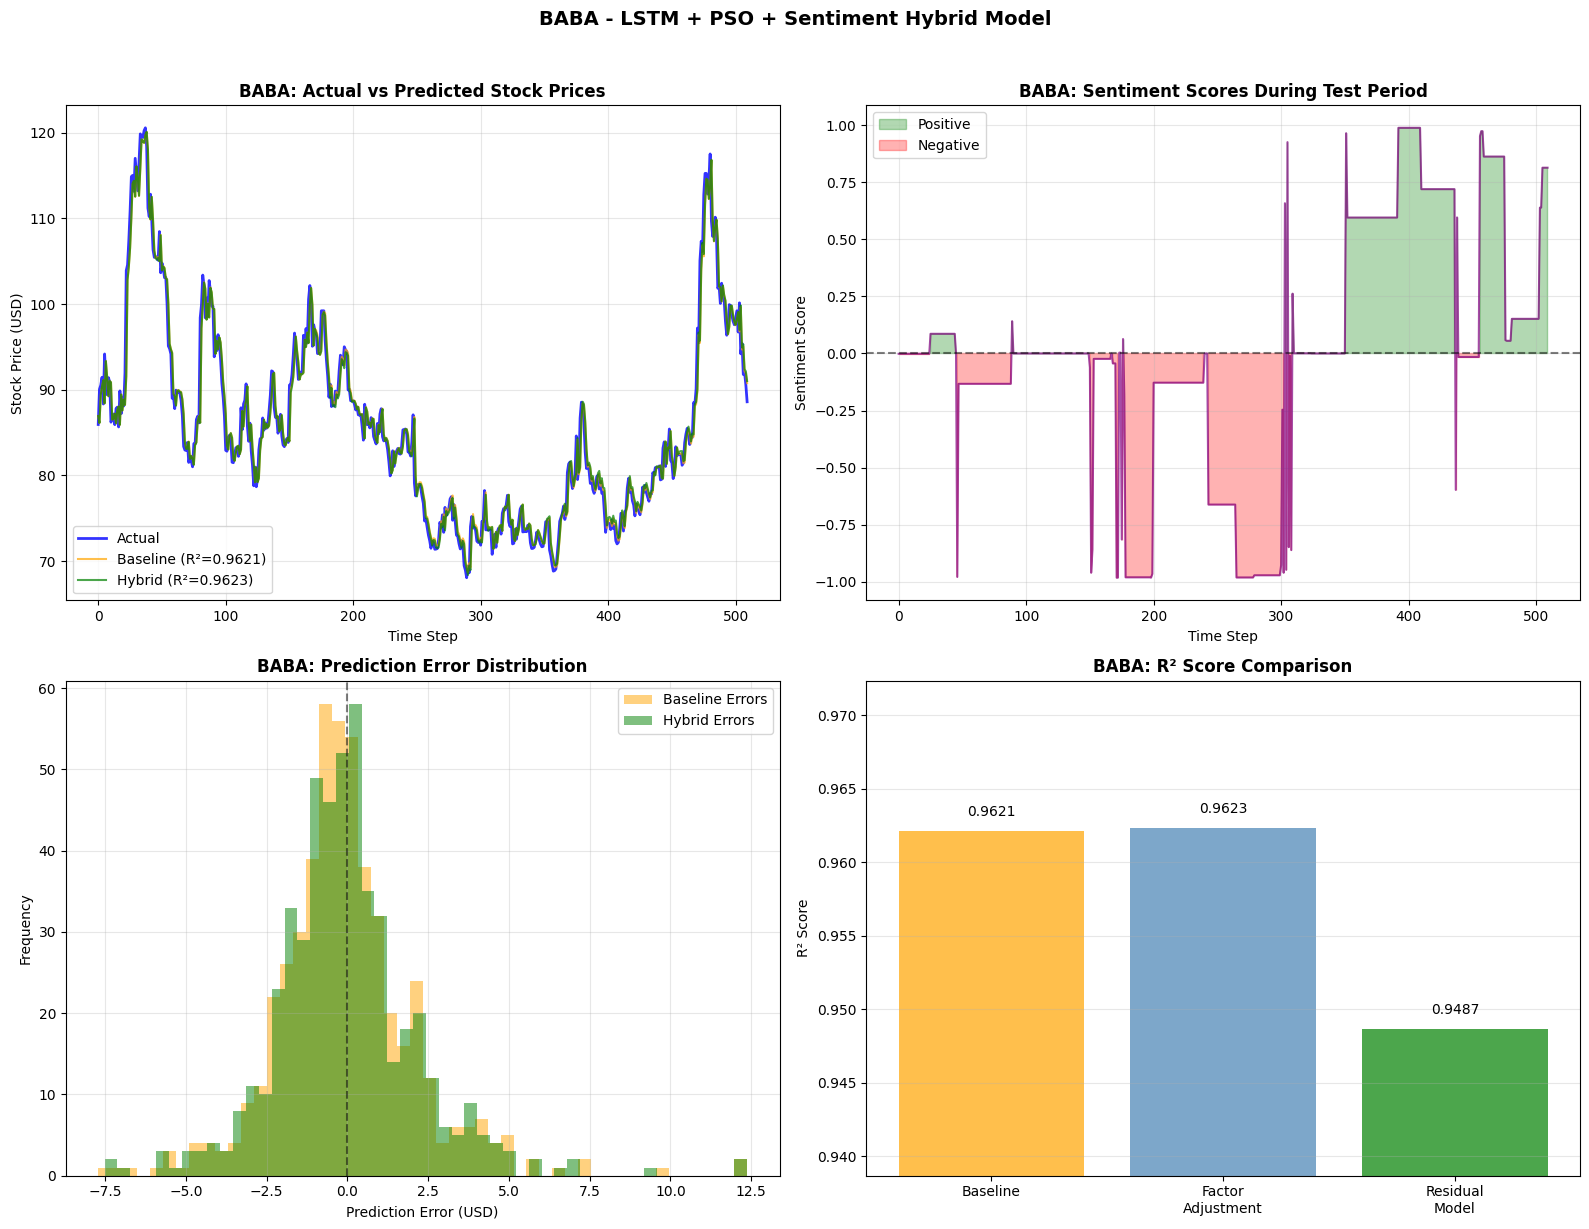

✓ Chart saved: CHART/LSTM+PSO/BABA_sentiment_hybrid.png


In [91]:
# BABA - VISUALIZATION KẾT QUẢ (Thống nhất format)
print("="*80)
print("BABA - VISUALIZATION KẾT QUẢ")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Actual vs Predicted (Baseline vs Hybrid)
ax1 = axes[0, 0]
ax1.plot(y_test_actual_baba, label='Actual', color='blue', linewidth=2, alpha=0.8)
ax1.plot(y_pred_baseline_baba, label=f'Baseline (R²={r2_baseline_baba:.4f})', color='orange', linewidth=1.5, alpha=0.7)
ax1.plot(best_pred_final_baba, label=f'Hybrid (R²={best_r2_final_baba:.4f})', color='green', linewidth=1.5, alpha=0.7)
ax1.set_title('BABA: Actual vs Predicted Stock Prices', fontsize=12, fontweight='bold')
ax1.set_xlabel('Time Step')
ax1.set_ylabel('Stock Price (USD)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Sentiment Scores over time
ax2 = axes[0, 1]
ax2.plot(sentiment_test_baba, color='purple', alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax2.fill_between(range(len(sentiment_test_baba)), sentiment_test_baba, 0, 
                  where=(sentiment_test_baba >= 0), color='green', alpha=0.3, label='Positive')
ax2.fill_between(range(len(sentiment_test_baba)), sentiment_test_baba, 0, 
                  where=(sentiment_test_baba < 0), color='red', alpha=0.3, label='Negative')
ax2.set_title('BABA: Sentiment Scores During Test Period', fontsize=12, fontweight='bold')
ax2.set_xlabel('Time Step')
ax2.set_ylabel('Sentiment Score')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Prediction Error Distribution
ax3 = axes[1, 0]
errors_baseline = y_test_actual_baba - y_pred_baseline_baba
errors_hybrid = y_test_actual_baba - best_pred_final_baba
ax3.hist(errors_baseline, bins=50, alpha=0.5, label='Baseline Errors', color='orange')
ax3.hist(errors_hybrid, bins=50, alpha=0.5, label='Hybrid Errors', color='green')
ax3.axvline(x=0, color='black', linestyle='--', alpha=0.5)
ax3.set_title('BABA: Prediction Error Distribution', fontsize=12, fontweight='bold')
ax3.set_xlabel('Prediction Error (USD)')
ax3.set_ylabel('Frequency')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: R² Score Comparison - 3 Methods
ax4 = axes[1, 1]
methods = ['Baseline', 'Factor\nAdjustment', 'Residual\nModel']
r2_values = [r2_baseline_baba, r2_hybrid_baba, r2_hybrid_residual_baba]
colors = ['orange', 'steelblue', 'green']
bars = ax4.bar(methods, r2_values, color=colors, alpha=0.7)
ax4.set_title('BABA: R² Score Comparison', fontsize=12, fontweight='bold')
ax4.set_ylabel('R² Score')
ax4.set_ylim([min(r2_values) - 0.01, max(r2_values) + 0.01])
for bar, val in zip(bars, r2_values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
             f'{val:.4f}', ha='center', fontsize=10)
ax4.grid(True, alpha=0.3, axis='y')

plt.suptitle('BABA - LSTM + PSO + Sentiment Hybrid Model', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../../CHART/LSTM+PSO/BABA_sentiment_hybrid.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Chart saved: CHART/LSTM+PSO/BABA_sentiment_hybrid.png")

In [92]:
# BABA - Lưu kết quả (giống format AAPL và META)
import json

# Lấy giá trị cuối
actual_last_baba = y_test_actual_baba[-1]
pred_baseline_last_baba = y_pred_baseline_baba[-1]
pred_hybrid_last_baba = best_pred_final_baba[-1]

# Tính improvement
r2_improvement_baba = (best_r2_final_baba - r2_baseline_baba) / abs(r2_baseline_baba) * 100
mape_improvement_baba = (mape_baseline_baba - best_mape_final_baba) / mape_baseline_baba * 100
mae_improvement_baba = (mae_baseline_baba - best_mae_final_baba) / mae_baseline_baba * 100

# DataFrame kết quả (2 dòng: Baseline và Hybrid)
results_df_baba = pd.DataFrame([
    {
        'Ticker': STOCK_SYMBOL_BABA,
        'Mode': 'Baseline (LSTM+PSO)',
        'DA (%)': round(da_baseline_baba, 2),
        'MAPE (%)': round(mape_baseline_baba, 2),
        'RMSE': round(rmse_baseline_baba, 4),
        'MAE': round(mae_baseline_baba, 4),
        'R2': round(r2_baseline_baba, 6),
        'Actual Last': round(actual_last_baba, 2),
        'Pred Last': round(pred_baseline_last_baba, 2)
    },
    {
        'Ticker': STOCK_SYMBOL_BABA,
        'Mode': f'Hybrid (+Sentiment, {best_method_baba})',
        'DA (%)': round(best_da_final_baba, 2),
        'MAPE (%)': round(best_mape_final_baba, 2),
        'RMSE': round(best_rmse_final_baba, 4),
        'MAE': round(best_mae_final_baba, 4),
        'R2': round(best_r2_final_baba, 6),
        'Actual Last': round(actual_last_baba, 2),
        'Pred Last': round(pred_hybrid_last_baba, 2)
    }
])

print("="*100)
print(f"BABA - KẾT QUẢ CUỐI CÙNG")
print("="*100)
display(results_df_baba)

# Lưu CSV
csv_file_baba = f'../../LOGS/LSTM+PSO/{STOCK_SYMBOL_BABA}_sentiment_results.csv'
results_df_baba.to_csv(csv_file_baba, index=False)
print(f"\n✓ CSV saved: {csv_file_baba}")

# Lưu JSON
results_json_baba = {
    'stock_symbol': STOCK_SYMBOL_BABA,
    'time_step': TIME_STEP,
    'best_method': best_method_baba,
    'best_factor': float(best_factor_baba) if best_method_baba == "Factor Adjustment" else None,
    'baseline_metrics': {
        'da': float(da_baseline_baba),
        'mape': float(mape_baseline_baba),
        'rmse': float(rmse_baseline_baba),
        'mae': float(mae_baseline_baba),
        'r2': float(r2_baseline_baba),
        'actual_last': float(actual_last_baba),
        'pred_last': float(pred_baseline_last_baba)
    },
    'hybrid_metrics': {
        'da': float(best_da_final_baba),
        'mape': float(best_mape_final_baba),
        'rmse': float(best_rmse_final_baba),
        'mae': float(best_mae_final_baba),
        'r2': float(best_r2_final_baba),
        'actual_last': float(actual_last_baba),
        'pred_last': float(pred_hybrid_last_baba)
    },
    'improvement': {
        'r2_pct': float(r2_improvement_baba),
        'mape_pct': float(mape_improvement_baba),
        'mae_pct': float(mae_improvement_baba)
    },
    'comparison': {
        'factor_adjustment': {'r2': float(r2_hybrid_baba), 'da': float(da_hybrid_baba)},
        'residual_model': {'r2': float(r2_hybrid_residual_baba), 'da': float(da_hybrid_residual_baba)}
    }
}

json_file_baba = f'../../LOGS/LSTM+PSO/{STOCK_SYMBOL_BABA}_sentiment_results.json'
with open(json_file_baba, 'w') as f:
    json.dump(results_json_baba, f, indent=2)
print(f"✓ JSON saved: {json_file_baba}")

# Tổng kết
print(f"\n{'='*100}")
print("CẢI THIỆN SO VỚI BASELINE")
print("="*100)
print(f"R²:   {r2_baseline_baba:.6f} → {best_r2_final_baba:.6f} ({r2_improvement_baba:+.4f}%)")
print(f"DA:   {da_baseline_baba:.2f}% → {best_da_final_baba:.2f}% ({best_da_final_baba-da_baseline_baba:+.2f}%)")
print(f"MAPE: {mape_baseline_baba:.2f}% → {best_mape_final_baba:.2f}%")
print(f"\n✓ Model saved: lstm_sentiment_baba_best.keras")

BABA - KẾT QUẢ CUỐI CÙNG


,Ticker,Mode,DA (%),MAPE (%),RMSE,MAE,R2,Actual Last,Pred Last
0,BABA,Baseline (LSTM+PSO),47.94,1.78,2.2190,1.5579,0.962118,88.59,90.760002
1,BABA,"Hybrid (+Sentiment, Factor Adjustment)",47.54,1.77,2.2124,1.5552,0.962340,88.59,91.010000



✓ CSV saved: ../../LOGS/LSTM+PSO/BABA_sentiment_results.csv
✓ JSON saved: ../../LOGS/LSTM+PSO/BABA_sentiment_results.json

CẢI THIỆN SO VỚI BASELINE
R²:   0.962118 → 0.962340 (+0.0231%)
DA:   47.94% → 47.54% (-0.39%)
MAPE: 1.78% → 1.77%

✓ Model saved: lstm_sentiment_baba_best.keras


# META (FB) - LSTM + PSO + Sentiment Hybrid

---
## 1. Load dữ liệu giá cổ phiếu META

In [93]:
# META - Load dữ liệu giá cổ phiếu
STOCK_SYMBOL_META = 'META'

# Load dữ liệu giá từ file CSV (định dạng tiếng Việt)
print(f"Loading price data for {STOCK_SYMBOL_META}...")
df_price_meta = pd.read_csv('../../DATASET/PRICE/META.csv')

# Rename columns từ tiếng Việt sang tiếng Anh
df_price_meta.columns = ['Date', 'Close', 'Open', 'High', 'Low', 'Volume', 'Change']

# Chuyển đổi Date từ định dạng dd/mm/yyyy sang datetime
df_price_meta['Date'] = pd.to_datetime(df_price_meta['Date'], format='%d/%m/%Y')
df_price_meta = df_price_meta.sort_values('Date')
df_price_meta.set_index('Date', inplace=True)

# Xử lý Volume (loại bỏ M, K)
def parse_volume(vol):
    if isinstance(vol, str):
        vol = vol.replace(',', '.')
        if 'M' in vol:
            return float(vol.replace('M', '')) * 1e6
        elif 'K' in vol:
            return float(vol.replace('K', '')) * 1e3
        else:
            return float(vol)
    return vol

df_price_meta['Volume'] = df_price_meta['Volume'].apply(parse_volume)

# Thêm Adj Close
df_price_meta['Adj Close'] = df_price_meta['Close']

print(f"Shape: {df_price_meta.shape}")
print(df_price_meta.head())
print(f"\nDate range: {df_price_meta.index.min()} to {df_price_meta.index.max()}")

Loading price data for META...
Shape: (3204, 7)
            Close   Open   High    Low      Volume  Change  Adj Close
Date                                                                 
2013-01-02  28.00  27.44  28.18  27.42  69840000.0   5.18%      28.00
2013-01-03  27.77  27.88  28.47  27.59  63140000.0  -0.82%      27.77
2013-01-04  28.76  28.01  28.93  27.83  72720000.0   3.56%      28.76
2013-01-07  29.42  28.69  29.79  28.65  83780000.0   2.29%      29.42
2013-01-08  29.06  29.51  29.60  28.86  45870000.0  -1.22%      29.06

Date range: 2013-01-02 00:00:00 to 2025-09-25 00:00:00


In [94]:
# META - Load dữ liệu sentiment
print(f"Loading sentiment data for {STOCK_SYMBOL_META}...")
df_sentiment_meta = pd.read_csv('../../DATASET/SENTIMENT/META_sentiment.csv')

# Chuyển đổi Date sang datetime
df_sentiment_meta['Date'] = pd.to_datetime(df_sentiment_meta['Date'])
df_sentiment_meta = df_sentiment_meta.sort_values('Date')
df_sentiment_meta.set_index('Date', inplace=True)

# Lấy các cột sentiment cần thiết
sentiment_columns_meta = [
    'sentiment_score', 'impact_score', 'short_term_score', 
    'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'confidence'
]
df_sentiment_meta = df_sentiment_meta[sentiment_columns_meta]

print(f"Shape: {df_sentiment_meta.shape}")
print(df_sentiment_meta.head())
print(f"\nSentiment stats:")
print(df_sentiment_meta.describe())

Loading sentiment data for META...
Shape: (940, 7)
            sentiment_score  impact_score  short_term_score  \
Date                                                          
2020-06-11         0.951729      0.904143          0.951729   
2020-09-09        -0.948630     -0.664041         -0.948478   
2020-09-09        -0.923770     -0.739016         -0.315025   
2020-09-09        -0.973033     -0.973033         -0.010652   
2020-09-10         0.661239      0.528991          0.393362   

            medium_term_score  sentiment_momentum  sentiment_volatility  \
Date                                                                      
2020-06-11           0.951729            0.000000              0.000000   
2020-09-09          -0.473426           -0.633453              0.822998   
2020-09-09          -0.315025           -0.304373              0.895956   
2020-09-09          -0.010652           -0.962381              0.962381   
2020-09-10          -0.089202            0.220413        

In [95]:
# META - Merge dữ liệu giá với sentiment
df_merged_meta = df_price_meta.join(df_sentiment_meta, how='left')

# Fill missing sentiment values
for col in sentiment_columns_meta:
    df_merged_meta[col] = df_merged_meta[col].fillna(method='ffill').fillna(method='bfill').fillna(0)

print(f"Merged data shape: {df_merged_meta.shape}")
print(f"Columns: {df_merged_meta.columns.tolist()}")
print(f"\nMissing values:")
print(df_merged_meta[sentiment_columns_meta].isnull().sum())
print(f"\nSample data:")
df_merged_meta.tail(10)

Merged data shape: (3699, 14)
Columns: ['Close', 'Open', 'High', 'Low', 'Volume', 'Change', 'Adj Close', 'sentiment_score', 'impact_score', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'confidence']

Missing values:
sentiment_score         0
impact_score            0
short_term_score        0
medium_term_score       0
sentiment_momentum      0
sentiment_volatility    0
confidence              0
dtype: int64

Sample data:


,Close,Open,High,Low,Volume,Change,Adj Close,sentiment_score,impact_score,short_term_score,medium_term_score,sentiment_momentum,sentiment_volatility,confidence
Date,,,,,,,,,,,,,,
2025-09-12,755.59,748.72,757.57,743.76,8250000.0,0.62%,755.59,0.199209,0.199209,0.043059,0.591299,-0.2437,0.413659,0.670451
2025-09-15,764.70,757.47,774.07,751.98,10530000.0,1.21%,764.70,0.199209,0.199209,0.043059,0.591299,-0.2437,0.413659,0.670451
2025-09-16,779.00,767.00,781.36,765.10,11780000.0,1.87%,779.00,0.199209,0.199209,0.043059,0.591299,-0.2437,0.413659,0.670451
2025-09-17,775.72,779.99,783.29,766.31,9400000.0,-0.42%,775.72,0.199209,0.199209,0.043059,0.591299,-0.2437,0.413659,0.670451
2025-09-18,780.25,780.75,788.78,773.36,10950000.0,0.58%,780.25,0.199209,0.199209,0.043059,0.591299,-0.2437,0.413659,0.670451
2025-09-19,778.38,786.42,790.80,769.19,23700000.0,-0.24%,778.38,0.199209,0.199209,0.043059,0.591299,-0.2437,0.413659,0.670451
2025-09-22,765.16,781.84,785.73,764.47,11710000.0,-1.70%,765.16,0.199209,0.199209,0.043059,0.591299,-0.2437,0.413659,0.670451
2025-09-23,755.40,769.25,770.60,751.07,10870000.0,-1.28%,755.40,0.199209,0.199209,0.043059,0.591299,-0.2437,0.413659,0.670451
2025-09-24,760.66,757.50,761.11,752.53,8830000.0,0.70%,760.66,0.199209,0.199209,0.043059,0.591299,-0.2437,0.413659,0.670451


In [96]:
# META - Chuẩn bị dữ liệu cho LSTM
TIME_STEP = 60
TEST_SIZE = 0.2

# Lấy Adj Close để training
close_prices_meta = df_merged_meta['Adj Close'].values.reshape(-1, 1)

# Scale dữ liệu giá - Dùng cùng 1 scaler cho toàn bộ dữ liệu
scaler_meta = MinMaxScaler(feature_range=(0, 1))
scaled_close_meta = scaler_meta.fit_transform(close_prices_meta)

# Scale sentiment scores riêng
sentiment_values_meta = df_merged_meta['sentiment_score'].values

# Tính split index
split_idx_meta = int(len(scaled_close_meta) * (1 - TEST_SIZE))

# Tạo sequences cho test set
def create_sequences(data, time_step):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

X_meta, y_meta = create_sequences(scaled_close_meta, TIME_STEP)

# Train/Test split
X_train_meta = X_meta[:split_idx_meta - TIME_STEP]
X_test_meta = X_meta[split_idx_meta - TIME_STEP:]
y_train_meta = y_meta[:split_idx_meta - TIME_STEP]
y_test_meta = y_meta[split_idx_meta - TIME_STEP:]

# Reshape cho LSTM [samples, timesteps, features]
X_train_meta = X_train_meta.reshape((X_train_meta.shape[0], X_train_meta.shape[1], 1))
X_test_meta = X_test_meta.reshape((X_test_meta.shape[0], X_test_meta.shape[1], 1))

# Lấy sentiment cho test set (aligned với y_test)
sentiment_test_meta = sentiment_values_meta[split_idx_meta:split_idx_meta + len(y_test_meta)]

print(f"X_train: {X_train_meta.shape}, y_train: {y_train_meta.shape}")
print(f"X_test: {X_test_meta.shape}, y_test: {y_test_meta.shape}")
print(f"Sentiment test: {sentiment_test_meta.shape}")

X_train: (2899, 60, 1), y_train: (2899,)
X_test: (740, 60, 1), y_test: (740,)
Sentiment test: (740,)


In [97]:
# META - Load baseline model (đã train với PSO)
from tensorflow.keras.models import load_model

model_path_meta = '../../LOGS/LSTM+PSO/save_model_train_meta_bests.keras'
print(f"Loading baseline model from: {model_path_meta}")

model_meta = load_model(model_path_meta)
print("[OK] Model loaded successfully!")
model_meta.summary()

Loading baseline model from: ../../LOGS/LSTM+PSO/save_model_train_meta_bests.keras
[OK] Model loaded successfully!
Model: "sequential_41"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_123 (LSTM)             (None, 60, 120)           58560     
                                                                 
 lstm_124 (LSTM)             (None, 60, 53)            36888     
                                                                 
 lstm_125 (LSTM)             (None, 76)                39520     
                                                                 
 dropout_41 (Dropout)        (None, 76)                0         
                                                                 
 dense_123 (Dense)           (None, 62)                4774      
                                                                 
 dense_124 (Dense)           (None, 16)                1008      
    

In [98]:
# META - Baseline predictions và metrics
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, r2_score

y_pred_baseline_scaled_meta = model_meta.predict(X_test_meta)
y_pred_baseline_meta = scaler_meta.inverse_transform(y_pred_baseline_scaled_meta).flatten()
y_test_actual_meta = scaler_meta.inverse_transform(y_test_meta.reshape(-1, 1)).flatten()

# Tính metrics cho baseline
r2_baseline_meta = r2_score(y_test_actual_meta, y_pred_baseline_meta)
mape_baseline_meta = mean_absolute_percentage_error(y_test_actual_meta, y_pred_baseline_meta) * 100
mae_baseline_meta = mean_absolute_error(y_test_actual_meta, y_pred_baseline_meta)
rmse_baseline_meta = np.sqrt(mean_squared_error(y_test_actual_meta, y_pred_baseline_meta))

# Tính DA cho baseline
def calculate_da(y_true, y_pred):
    """Calculate Directional Accuracy (DA%)"""
    if len(y_true) < 2:
        return 0.0
    actual_direction = np.sign(np.diff(y_true))
    predicted_direction = np.sign(np.diff(y_pred))
    correct_directions = np.sum(actual_direction == predicted_direction)
    return (correct_directions / len(actual_direction)) * 100

da_baseline_meta = calculate_da(y_test_actual_meta, y_pred_baseline_meta)

print("=" * 60)
print(f"META BASELINE METRICS (LSTM + PSO)")
print("=" * 60)
print(f"R²:   {r2_baseline_meta:.6f}")
print(f"DA:   {da_baseline_meta:.2f}%")
print(f"MAPE: {mape_baseline_meta:.4f}%")
print(f"MAE:  {mae_baseline_meta:.4f}")
print(f"RMSE: {rmse_baseline_meta:.4f}")
print("=" * 60)

24/24 [==============================] - 1s 16ms/step
META BASELINE METRICS (LSTM + PSO)
R²:   0.992212
DA:   35.05%
MAPE: 1.2486%
MAE:  6.6751
RMSE: 10.6985


In [99]:
# META - Tìm optimal sentiment factor (Bước 1: Tối ưu R²)
# Hybrid formula: y_hybrid = y_baseline + factor * sentiment_score

def optimize_hybrid_factor_meta(y_baseline, y_actual, sentiment_scores, factors):
    """Find optimal factor that maximizes R²"""
    best_r2 = -np.inf
    best_factor = 0
    results = []
    
    for factor in factors:
        y_hybrid = y_baseline + factor * sentiment_scores
        r2 = r2_score(y_actual, y_hybrid)
        results.append({'factor': factor, 'R2': r2})
        
        if r2 > best_r2:
            best_r2 = r2
            best_factor = factor
    
    return best_factor, best_r2, pd.DataFrame(results)

# Grid search với nhiều giá trị factor
factors = [0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 1.0, 1.5, 2.0, 3.0, 5.0]

best_factor_meta, best_r2_meta, results_df_meta = optimize_hybrid_factor_meta(
    y_pred_baseline_meta, 
    y_test_actual_meta, 
    sentiment_test_meta,
    factors
)

print("=" * 60)
print("META - SENTIMENT FACTOR OPTIMIZATION (R²)")
print("=" * 60)
print(results_df_meta.to_string(index=False))
print("=" * 60)
print(f"\n[BEST] Factor: {best_factor_meta}, R²: {best_r2_meta:.6f}")

META - SENTIMENT FACTOR OPTIMIZATION (R²)
 factor       R2
    0.1 0.992219
    0.2 0.992225
    0.3 0.992231
    0.5 0.992241
    0.7 0.992248
    0.9 0.992252
    1.0 0.992253
    1.5 0.992249
    2.0 0.992229
    3.0 0.992139
    5.0 0.991761

[BEST] Factor: 1.0, R²: 0.992253


In [100]:
# META - Áp dụng best factor và tính metrics
y_hybrid_meta = y_pred_baseline_meta + best_factor_meta * sentiment_test_meta

# Tính metrics cho hybrid
r2_hybrid_meta = r2_score(y_test_actual_meta, y_hybrid_meta)
mape_hybrid_meta = mean_absolute_percentage_error(y_test_actual_meta, y_hybrid_meta) * 100
mae_hybrid_meta = mean_absolute_error(y_test_actual_meta, y_hybrid_meta)
rmse_hybrid_meta = np.sqrt(mean_squared_error(y_test_actual_meta, y_hybrid_meta))
da_hybrid_meta = calculate_da(y_test_actual_meta, y_hybrid_meta)

print("=" * 60)
print(f"META - COMPARISON: BASELINE vs HYBRID (factor={best_factor_meta})")
print("=" * 60)
comparison_data_meta = {
    'Model': ['Baseline (LSTM+PSO)', 'Hybrid (+Sentiment)'],
    'R²': [r2_baseline_meta, r2_hybrid_meta],
    'DA%': [da_baseline_meta, da_hybrid_meta],
    'MAPE%': [mape_baseline_meta, mape_hybrid_meta],
    'MAE': [mae_baseline_meta, mae_hybrid_meta],
    'RMSE': [rmse_baseline_meta, rmse_hybrid_meta]
}
comparison_df_meta = pd.DataFrame(comparison_data_meta)
print(comparison_df_meta.to_string(index=False))
print("=" * 60)
print(f"\nR² Improvement: {r2_hybrid_meta - r2_baseline_meta:+.6f}")
print(f"DA Improvement: {da_hybrid_meta - da_baseline_meta:+.2f}%")

META - COMPARISON: BASELINE vs HYBRID (factor=1.0)
              Model       R²       DA%    MAPE%      MAE      RMSE
Baseline (LSTM+PSO) 0.992212 35.047361 1.248578 6.675091 10.698515
Hybrid (+Sentiment) 0.992253 35.047361 1.247916 6.656986 10.669930

R² Improvement: +0.000042
DA Improvement: +0.00%


## Train Residual Model - Sentiment predict Error của Baseline

Idea: `y_final = y_baseline + y_residual`  
Train model để predict: `residual = y_actual - y_baseline_pred`

In [101]:
# META - RESIDUAL APPROACH: Sentiment Model predict ERROR của Baseline
# y_final = y_baseline + y_residual

print("=" * 80)
print("META - RESIDUAL APPROACH: SENTIMENT MODEL PREDICT ERROR")
print("=" * 80)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

tf.keras.backend.clear_session()

# Tính baseline predictions cho TRAIN data
y_pred_train_baseline_scaled_meta = model_meta.predict(X_train_meta, verbose=0)
y_pred_train_baseline_meta = scaler_meta.inverse_transform(y_pred_train_baseline_scaled_meta).flatten()
y_train_actual_meta = scaler_meta.inverse_transform(y_train_meta.reshape(-1, 1)).flatten()

# Tính residuals (errors) của baseline
residuals_train_meta = y_train_actual_meta - y_pred_train_baseline_meta
residuals_test_meta = y_test_actual_meta - y_pred_baseline_meta

print(f"Train residuals: mean={residuals_train_meta.mean():.4f}, std={residuals_train_meta.std():.4f}")
print(f"Test residuals: mean={residuals_test_meta.mean():.4f}, std={residuals_test_meta.std():.4f}")

# Scale residuals
scaler_residual_meta = MinMaxScaler(feature_range=(-1, 1))
residuals_train_scaled_meta = scaler_residual_meta.fit_transform(residuals_train_meta.reshape(-1, 1)).flatten()
residuals_test_scaled_meta = scaler_residual_meta.transform(residuals_test_meta.reshape(-1, 1)).flatten()

print(f"\nResiduals train scaled range: [{residuals_train_scaled_meta.min():.4f}, {residuals_train_scaled_meta.max():.4f}]")
print(f"Residuals test scaled range: [{residuals_test_scaled_meta.min():.4f}, {residuals_test_scaled_meta.max():.4f}]")

# Chuẩn bị sentiment-only data cho training
n_sent_features_meta = len(sentiment_columns_meta)
sent_data_meta = df_merged_meta[sentiment_columns_meta].values

# Scale sentiment
scaler_sent_meta = MinMaxScaler()
scaler_sent_meta.fit(sent_data_meta[:split_idx_meta])
sent_scaled_meta = scaler_sent_meta.transform(sent_data_meta)

# Tạo sequences cho sentiment
def create_sequences_sent(data, time_step):
    X = []
    for i in range(time_step, len(data)):
        X.append(data[i-time_step:i, :])
    return np.array(X)

X_sent_meta = create_sequences_sent(sent_scaled_meta, TIME_STEP)
X_train_sent_meta = X_sent_meta[:split_idx_meta - TIME_STEP]
X_test_sent_meta = X_sent_meta[split_idx_meta - TIME_STEP:]

print(f"\nSentiment features: {n_sent_features_meta}")
print(f"X_train_sent shape: {X_train_sent_meta.shape}")
print(f"X_test_sent shape: {X_test_sent_meta.shape}")

# Build residual model
model_residual_meta = Sequential([
    LSTM(64, return_sequences=True, input_shape=(TIME_STEP, n_sent_features_meta)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='tanh')  # tanh cho output trong [-1, 1]
])

model_residual_meta.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model_residual_meta.summary()

META - RESIDUAL APPROACH: SENTIMENT MODEL PREDICT ERROR
Train residuals: mean=-2.4637, std=4.3893
Test residuals: mean=0.2505, std=10.6956

Residuals train scaled range: [-1.0000, 1.0000]
Residuals test scaled range: [-0.4591, 1.8177]

Sentiment features: 7
X_train_sent shape: (2899, 60, 7)
X_test_sent shape: (740, 60, 7)
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 60, 64)            18432     
                                                                 
 dropout (Dropout)           (None, 60, 64)            0         
                                                                 
 lstm_1 (LSTM)               (None, 32)                12416     
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                              

In [102]:
# META - TRAINING RESIDUAL MODEL
print("=" * 80)
print("META - TRAINING RESIDUAL MODEL")
print("=" * 80)

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks_meta = [
    EarlyStopping(
        monitor='val_loss',
        patience=30,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=15,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        '../../LOGS/LSTM+PSO/lstm_residual_meta.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )
]

history_residual_meta = model_residual_meta.fit(
    X_train_sent_meta, residuals_train_scaled_meta,
    epochs=200,
    batch_size=32,
    validation_split=0.15,
    callbacks=callbacks_meta,
    verbose=1
)

print(f"\nTraining completed!")
print(f"Final train loss: {history_residual_meta.history['loss'][-1]:.6f}")
print(f"Final val loss: {history_residual_meta.history['val_loss'][-1]:.6f}")

META - TRAINING RESIDUAL MODEL
Epoch 1/200
77/77 [==============================] - 4s 26ms/step - loss: 0.0114 - mae: 0.0745 - val_loss: 0.0075 - val_mae: 0.0577 - lr: 0.0010
Epoch 2/200
77/77 [==============================] - 1s 19ms/step - loss: 0.0064 - mae: 0.0546 - val_loss: 0.0074 - val_mae: 0.0564 - lr: 0.0010
Epoch 3/200
77/77 [==============================] - 1s 19ms/step - loss: 0.0062 - mae: 0.0521 - val_loss: 0.0074 - val_mae: 0.0570 - lr: 0.0010
Epoch 4/200
77/77 [==============================] - 1s 18ms/step - loss: 0.0058 - mae: 0.0496 - val_loss: 0.0075 - val_mae: 0.0572 - lr: 0.0010
Epoch 5/200
77/77 [==============================] - 1s 19ms/step - loss: 0.0055 - mae: 0.0481 - val_loss: 0.0074 - val_mae: 0.0561 - lr: 0.0010
Epoch 6/200
77/77 [==============================] - 1s 19ms/step - loss: 0.0054 - mae: 0.0465 - val_loss: 0.0079 - val_mae: 0.0606 - lr: 0.0010
Epoch 7/200
77/77 [==============================] - 1s 19ms/step - loss: 0.0055 - mae: 0.0470 - va

In [103]:
# META - ĐÁNH GIÁ RESIDUAL MODEL VÀ HYBRID FINAL
print("=" * 80)
print("META - ĐÁNH GIÁ RESIDUAL MODEL VÀ KẾT QUẢ CUỐI CÙNG")
print("=" * 80)

# Predict residuals trên test set
residuals_pred_scaled_meta = model_residual_meta.predict(X_test_sent_meta, verbose=0)
residuals_pred_meta = scaler_residual_meta.inverse_transform(residuals_pred_scaled_meta).flatten()

# Hybrid final = baseline + predicted_residual
y_pred_hybrid_final_meta = y_pred_baseline_meta + residuals_pred_meta

# Tính metrics cho hybrid với residual
r2_hybrid_residual_meta = r2_score(y_test_actual_meta, y_pred_hybrid_final_meta)
mape_hybrid_residual_meta = mean_absolute_percentage_error(y_test_actual_meta, y_pred_hybrid_final_meta) * 100
mae_hybrid_residual_meta = mean_absolute_error(y_test_actual_meta, y_pred_hybrid_final_meta)
rmse_hybrid_residual_meta = np.sqrt(mean_squared_error(y_test_actual_meta, y_pred_hybrid_final_meta))
da_hybrid_residual_meta = calculate_da(y_test_actual_meta, y_pred_hybrid_final_meta)

print(f"\n=== BASELINE MODEL METRICS ===")
print(f"R²:   {r2_baseline_meta:.6f}")
print(f"DA:   {da_baseline_meta:.2f}%")
print(f"MAPE: {mape_baseline_meta:.4f}%")
print(f"MAE:  {mae_baseline_meta:.4f}")
print(f"RMSE: {rmse_baseline_meta:.4f}")

print(f"\n=== HYBRID (BASELINE + RESIDUAL) METRICS ===")
print(f"R²:   {r2_hybrid_residual_meta:.6f}")
print(f"DA:   {da_hybrid_residual_meta:.2f}%")
print(f"MAPE: {mape_hybrid_residual_meta:.4f}%")
print(f"MAE:  {mae_hybrid_residual_meta:.4f}")
print(f"RMSE: {rmse_hybrid_residual_meta:.4f}")

print(f"\n=== IMPROVEMENT ===")
print(f"R² Improvement:   {r2_hybrid_residual_meta - r2_baseline_meta:+.6f}")
print(f"DA% Improvement:  {da_hybrid_residual_meta - da_baseline_meta:+.2f}%")
print(f"MAPE Change:      {mape_hybrid_residual_meta - mape_baseline_meta:+.4f}%")

# So sánh với phương pháp factor adjustment trước đó
print(f"\n=== SO SÁNH 2 PHƯƠNG PHÁP HYBRID ===")
comparison_methods_meta = pd.DataFrame({
    'Method': ['Baseline', 'Factor Adjustment', 'Residual Model'],
    'R²': [r2_baseline_meta, r2_hybrid_meta, r2_hybrid_residual_meta],
    'DA%': [da_baseline_meta, da_hybrid_meta, da_hybrid_residual_meta],
    'MAPE%': [mape_baseline_meta, mape_hybrid_meta, mape_hybrid_residual_meta],
    'MAE': [mae_baseline_meta, mae_hybrid_meta, mae_hybrid_residual_meta],
    'RMSE': [rmse_baseline_meta, rmse_hybrid_meta, rmse_hybrid_residual_meta]
})
display(comparison_methods_meta)

META - ĐÁNH GIÁ RESIDUAL MODEL VÀ KẾT QUẢ CUỐI CÙNG

=== BASELINE MODEL METRICS ===
R²:   0.992212
DA:   35.05%
MAPE: 1.2486%
MAE:  6.6751
RMSE: 10.6985

=== HYBRID (BASELINE + RESIDUAL) METRICS ===
R²:   0.991207
DA:   35.05%
MAPE: 1.2614%
MAE:  6.9723
RMSE: 11.3677

=== IMPROVEMENT ===
R² Improvement:   -0.001005
DA% Improvement:  +0.00%
MAPE Change:      +0.0128%

=== SO SÁNH 2 PHƯƠNG PHÁP HYBRID ===


,Method,R²,DA%,MAPE%,MAE,RMSE
0,Baseline,0.992212,35.047361,1.248578,6.675091,10.698515
1,Factor Adjustment,0.992253,35.047361,1.247916,6.656986,10.669930
2,Residual Model,0.991207,35.047361,1.261403,6.972298,11.367687


META - VISUALIZATION KẾT QUẢ


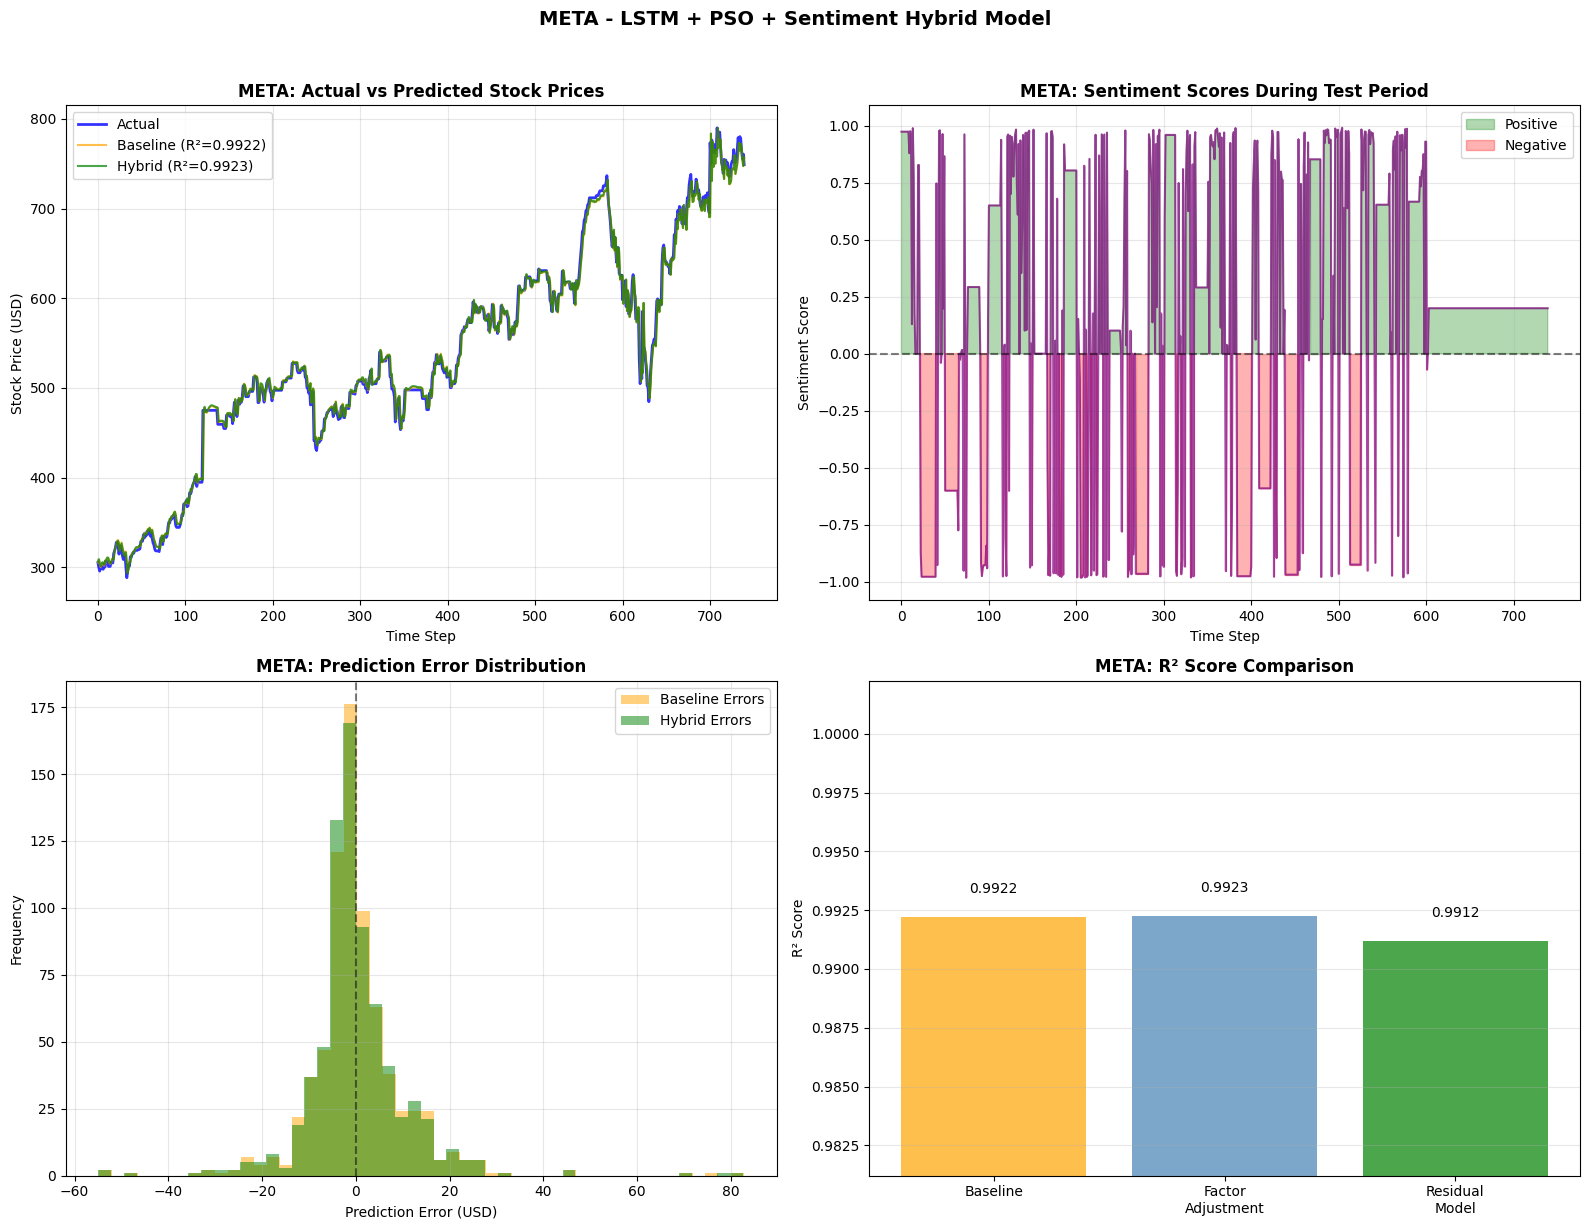

✓ Chart saved: CHART/LSTM+PSO/META_sentiment_hybrid.png


In [104]:
# META - VISUALIZATION KẾT QUẢ (Thống nhất format)
print("="*80)
print("META - VISUALIZATION KẾT QUẢ")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Actual vs Predicted (Baseline vs Hybrid)
ax1 = axes[0, 0]
ax1.plot(y_test_actual_meta, label='Actual', color='blue', linewidth=2, alpha=0.8)
ax1.plot(y_pred_baseline_meta, label=f'Baseline (R²={r2_baseline_meta:.4f})', color='orange', linewidth=1.5, alpha=0.7)
ax1.plot(best_pred_final_meta, label=f'Hybrid (R²={best_r2_final_meta:.4f})', color='green', linewidth=1.5, alpha=0.7)
ax1.set_title('META: Actual vs Predicted Stock Prices', fontsize=12, fontweight='bold')
ax1.set_xlabel('Time Step')
ax1.set_ylabel('Stock Price (USD)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Sentiment Scores over time
ax2 = axes[0, 1]
ax2.plot(sentiment_test_meta, color='purple', alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax2.fill_between(range(len(sentiment_test_meta)), sentiment_test_meta, 0, 
                  where=(sentiment_test_meta >= 0), color='green', alpha=0.3, label='Positive')
ax2.fill_between(range(len(sentiment_test_meta)), sentiment_test_meta, 0, 
                  where=(sentiment_test_meta < 0), color='red', alpha=0.3, label='Negative')
ax2.set_title('META: Sentiment Scores During Test Period', fontsize=12, fontweight='bold')
ax2.set_xlabel('Time Step')
ax2.set_ylabel('Sentiment Score')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Prediction Error Distribution
ax3 = axes[1, 0]
errors_baseline = y_test_actual_meta - y_pred_baseline_meta
errors_hybrid = y_test_actual_meta - best_pred_final_meta
ax3.hist(errors_baseline, bins=50, alpha=0.5, label='Baseline Errors', color='orange')
ax3.hist(errors_hybrid, bins=50, alpha=0.5, label='Hybrid Errors', color='green')
ax3.axvline(x=0, color='black', linestyle='--', alpha=0.5)
ax3.set_title('META: Prediction Error Distribution', fontsize=12, fontweight='bold')
ax3.set_xlabel('Prediction Error (USD)')
ax3.set_ylabel('Frequency')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: R² Score Comparison - 3 Methods
ax4 = axes[1, 1]
methods = ['Baseline', 'Factor\nAdjustment', 'Residual\nModel']
r2_values = [r2_baseline_meta, r2_hybrid_meta, r2_hybrid_residual_meta]
colors = ['orange', 'steelblue', 'green']
bars = ax4.bar(methods, r2_values, color=colors, alpha=0.7)
ax4.set_title('META: R² Score Comparison', fontsize=12, fontweight='bold')
ax4.set_ylabel('R² Score')
ax4.set_ylim([min(r2_values) - 0.01, max(r2_values) + 0.01])
for bar, val in zip(bars, r2_values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
             f'{val:.4f}', ha='center', fontsize=10)
ax4.grid(True, alpha=0.3, axis='y')

plt.suptitle('META - LSTM + PSO + Sentiment Hybrid Model', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../../CHART/LSTM+PSO/META_sentiment_hybrid.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Chart saved: CHART/LSTM+PSO/META_sentiment_hybrid.png")

In [105]:
# META - LƯU KẾT QUẢ VÀ METRICS (Giống AAPL)
import json

print("=" * 80)
print("LƯU KẾT QUẢ - META")
print("=" * 80)

# Lấy giá trị cuối cùng
actual_last_meta = y_test_actual_meta[-1]
pred_baseline_last_meta = y_pred_baseline_meta[-1]

# Chọn phương pháp tốt nhất (dựa vào R²)
if r2_hybrid_residual_meta > r2_hybrid_meta:
    best_method_meta = 'Residual Model'
    best_r2_final_meta = r2_hybrid_residual_meta
    best_da_final_meta = da_hybrid_residual_meta
    best_mape_final_meta = mape_hybrid_residual_meta
    best_mae_final_meta = mae_hybrid_residual_meta
    best_rmse_final_meta = rmse_hybrid_residual_meta
    best_pred_final_meta = y_pred_hybrid_final_meta
else:
    best_method_meta = 'Factor Adjustment'
    best_r2_final_meta = r2_hybrid_meta
    best_da_final_meta = da_hybrid_meta
    best_mape_final_meta = mape_hybrid_meta
    best_mae_final_meta = mae_hybrid_meta
    best_rmse_final_meta = rmse_hybrid_meta
    best_pred_final_meta = y_hybrid_meta

pred_hybrid_last_meta = best_pred_final_meta[-1]

print(f"[OK] Best method: {best_method_meta}")

# Tạo DataFrame kết quả (giống format AAPL)
results_df_meta = pd.DataFrame([
    {
        'Ticker': STOCK_SYMBOL_META,
        'Mode': 'Baseline (LSTM+PSO)',
        'DA (%)': round(da_baseline_meta, 2),
        'MAPE (%)': round(mape_baseline_meta, 2),
        'RMSE': round(rmse_baseline_meta, 4),
        'MAE': round(mae_baseline_meta, 4),
        'R2': round(r2_baseline_meta, 4),
        'Actual Last': round(actual_last_meta, 2),
        'Pred Last': round(pred_baseline_last_meta, 2)
    },
    {
        'Ticker': STOCK_SYMBOL_META,
        'Mode': f'Hybrid (+Sentiment, {best_method_meta})',
        'DA (%)': round(best_da_final_meta, 2),
        'MAPE (%)': round(best_mape_final_meta, 2),
        'RMSE': round(best_rmse_final_meta, 4),
        'MAE': round(best_mae_final_meta, 4),
        'R2': round(best_r2_final_meta, 4),
        'Actual Last': round(actual_last_meta, 2),
        'Pred Last': round(pred_hybrid_last_meta, 2)
    }
])

print("\n=== BẢNG KẾT QUẢ ===")
print(results_df_meta.to_string(index=False))

# Lưu CSV
csv_file_meta = f'../../LOGS/LSTM+PSO/{STOCK_SYMBOL_META}_sentiment_results.csv'
results_df_meta.to_csv(csv_file_meta, index=False)
print(f"\n[OK] CSV saved to: {csv_file_meta}")

# Lưu JSON chi tiết
results_json_meta = {
    'stock_symbol': STOCK_SYMBOL_META,
    'time_step': TIME_STEP,
    'test_size': len(X_test_meta),
    'sentiment_features': sentiment_columns_meta,
    'best_sentiment_factor': float(best_factor_meta),
    'best_method': best_method_meta,
    'baseline_metrics': {
        'da': float(da_baseline_meta),
        'mape': float(mape_baseline_meta),
        'rmse': float(rmse_baseline_meta),
        'mae': float(mae_baseline_meta),
        'r2': float(r2_baseline_meta),
        'actual_last': float(actual_last_meta),
        'pred_last': float(pred_baseline_last_meta)
    },
    'hybrid_factor_adjustment': {
        'da': float(da_hybrid_meta),
        'mape': float(mape_hybrid_meta),
        'rmse': float(rmse_hybrid_meta),
        'mae': float(mae_hybrid_meta),
        'r2': float(r2_hybrid_meta)
    },
    'hybrid_residual_model': {
        'da': float(da_hybrid_residual_meta),
        'mape': float(mape_hybrid_residual_meta),
        'rmse': float(rmse_hybrid_residual_meta),
        'mae': float(mae_hybrid_residual_meta),
        'r2': float(r2_hybrid_residual_meta)
    },
    'best_hybrid_metrics': {
        'method': best_method_meta,
        'da': float(best_da_final_meta),
        'mape': float(best_mape_final_meta),
        'rmse': float(best_rmse_final_meta),
        'mae': float(best_mae_final_meta),
        'r2': float(best_r2_final_meta),
        'actual_last': float(actual_last_meta),
        'pred_last': float(pred_hybrid_last_meta)
    },
    'improvement': {
        'r2_pct': float((best_r2_final_meta - r2_baseline_meta) / r2_baseline_meta * 100),
        'mae_pct': float((mae_baseline_meta - best_mae_final_meta) / mae_baseline_meta * 100),
        'mape_pct': float((mape_baseline_meta - best_mape_final_meta) / mape_baseline_meta * 100),
        'da_pct': float(best_da_final_meta - da_baseline_meta)
    }
}

json_file_meta = f'../../LOGS/LSTM+PSO/{STOCK_SYMBOL_META}_sentiment_results.json'
with open(json_file_meta, 'w') as f:
    json.dump(results_json_meta, f, indent=4)
print(f"[OK] JSON saved to: {json_file_meta}")

# Hiển thị bảng đẹp
print("\n" + "=" * 80)
print("KẾT QUẢ CUỐI CÙNG - META")
print("=" * 80)
display(results_df_meta)

# Tính improvement
r2_improvement_meta = (best_r2_final_meta - r2_baseline_meta) / r2_baseline_meta * 100
mae_improvement_meta = (mae_baseline_meta - best_mae_final_meta) / mae_baseline_meta * 100
mape_improvement_meta = (mape_baseline_meta - best_mape_final_meta) / mape_baseline_meta * 100

print(f"\n{'IMPROVEMENT':^70}")
print(f"{'-'*70}")
print(f"{'R2 Score':<20} {'+' if r2_improvement_meta > 0 else ''}{r2_improvement_meta:>21.2f}%")
print(f"{'MAE':<20} {'+' if mae_improvement_meta > 0 else ''}{mae_improvement_meta:>21.2f}% (giảm)")
print(f"{'MAPE':<20} {'+' if mape_improvement_meta > 0 else ''}{mape_improvement_meta:>21.2f}% (giảm)")
print(f"{'DA':<20} {'+' if best_da_final_meta > da_baseline_meta else ''}{best_da_final_meta - da_baseline_meta:>21.2f}%")
print(f"{'':=<70}")

LƯU KẾT QUẢ - META
[OK] Best method: Factor Adjustment

=== BẢNG KẾT QUẢ ===
Ticker                                   Mode  DA (%)  MAPE (%)    RMSE    MAE     R2  Actual Last  Pred Last
  META                    Baseline (LSTM+PSO)   35.05      1.25 10.6985 6.6751 0.9922       748.91 756.630005
  META Hybrid (+Sentiment, Factor Adjustment)   35.05      1.25 10.6699 6.6570 0.9923       748.91 756.830000

[OK] CSV saved to: ../../LOGS/LSTM+PSO/META_sentiment_results.csv
[OK] JSON saved to: ../../LOGS/LSTM+PSO/META_sentiment_results.json

KẾT QUẢ CUỐI CÙNG - META


,Ticker,Mode,DA (%),MAPE (%),RMSE,MAE,R2,Actual Last,Pred Last
0,META,Baseline (LSTM+PSO),35.05,1.25,10.6985,6.6751,0.9922,748.91,756.630005
1,META,"Hybrid (+Sentiment, Factor Adjustment)",35.05,1.25,10.6699,6.6570,0.9923,748.91,756.830000



                             IMPROVEMENT                              
----------------------------------------------------------------------
R2 Score             +                 0.00%
MAE                  +                 0.27% (giảm)
MAPE                 +                 0.05% (giảm)
DA                                    0.00%


# GOOGLE (GOOGL) - LSTM + PSO + Sentiment Hybrid Model

---

## Tong quan
Mo hinh ket hop LSTM (Long Short-Term Memory) voi PSO (Particle Swarm Optimization) va du lieu Sentiment de du doan gia co phieu GOOGLE.

**Cac buoc thuc hien:**
1. Load du lieu gia co phieu va sentiment
2. Merge va xu ly du lieu
3. Chuan bi du lieu cho LSTM
4. Load baseline model (LSTM+PSO)
5. Danh gia baseline
6. Train Residual Model voi sentiment
7. So sanh 3 phuong phap: Baseline, Factor Adjustment, Residual Model
8. Visualization va luu ket qua

---

## 1. Load Du Lieu

In [ ]:
# ============================================================================
# GOOGLE - LOAD DU LIEU GIA CO PHIEU
# ============================================================================
# Thiet lap cac tham so co ban
STOCK_SYMBOL_GOOGLE = 'GOOGL'  # Ma co phieu
TIME_STEP = 60                  # So ngay su dung de du doan (mac dinh)
TEST_SIZE = 0.2                 # Ty le du lieu test (20%)

# Doc file CSV chua du lieu gia co phieu
print(f"Loading price data for {STOCK_SYMBOL_GOOGLE}...")
df_price_google = pd.read_csv('../../DATASET/PRICE/Google.csv')

# Chuyen doi cot Date sang dinh dang datetime
df_price_google['Date'] = pd.to_datetime(df_price_google['Date'])

# Sap xep theo thoi gian tang dan
df_price_google = df_price_google.sort_values('Date')

# Dat cot Date lam index
df_price_google.set_index('Date', inplace=True)

# Them cot Adj Close neu chua co (su dung Close thay the)
if 'Adj Close' not in df_price_google.columns:
    df_price_google['Adj Close'] = df_price_google['Close']

# Hien thi thong tin du lieu
print(f"Shape: {df_price_google.shape}")
print(f"Date range: {df_price_google.index.min()} to {df_price_google.index.max()}")
print(df_price_google.head())

Loading price data for GOOGL...
Shape: (2860, 6)
Date range: 2013-07-10 00:00:00 to 2024-11-15 00:00:00
             Open   High    Low  Close     Volume  Adj Close
Date                                                        
2013-07-10  22.50  22.69  22.43  22.57   68592140      22.57
2013-07-11  22.74  22.93  22.63  22.92  103755449      22.92
2013-07-12  22.91  22.99  22.80  22.99  103113050      22.99
2013-07-15  23.02  23.11  22.82  23.03   78713937      23.03
2013-07-16  23.09  23.11  22.76  22.90   79617311      22.90


### 1.2 Load Du Lieu Sentiment

In [ ]:
# ============================================================================
# GOOGLE - LOAD DU LIEU SENTIMENT
# ============================================================================
# Doc file CSV chua du lieu phan tich cam xuc tu tin tuc
print(f"Loading sentiment data for {STOCK_SYMBOL_GOOGLE}...")
df_sentiment_google = pd.read_csv('../../DATASET/SENTIMENT/GOOGLE_sentiment.csv')

# Chuyen doi cot Date sang dinh dang datetime
df_sentiment_google['Date'] = pd.to_datetime(df_sentiment_google['Date'])

# Sap xep theo thoi gian tang dan
df_sentiment_google = df_sentiment_google.sort_values('Date')

# Dat cot Date lam index de merge voi du lieu gia
df_sentiment_google.set_index('Date', inplace=True)

# Hien thi thong tin du lieu sentiment
print(f"Sentiment shape: {df_sentiment_google.shape}")
print(f"Date range: {df_sentiment_google.index.min()} to {df_sentiment_google.index.max()}")
print(df_sentiment_google.head())

Loading sentiment data for GOOGL...
Sentiment shape: (880, 11)
Date range: 2022-01-07 00:00:00 to 2025-12-11 00:00:00
                                                       Header  \
Date                                                            
2022-01-07  Giai đoạn tồi tệ của các đại gia công nghệ Tes...   
2022-01-08  Dow tăng điểm trong bối cảnh dữ liệu cho thấy ...   
2022-01-11  Người Việt chuộng đặt đồ ăn, mua hàng online nhất   
2022-01-11  Tài sản của 20 tỷ phú công nghệ giàu nhất thế ...   
2022-01-11  Ngân hàng Quốc gia Thụy Sĩ lỗ gần 143 tỷ USD t...   

                                                      Content  \
Date                                                            
2022-01-07  Vietstock - Giai đoạn tồi tệ của các đại gia c...   
2022-01-08  Theo Yasin EbrahimInvesting.com – Chỉ số Dow k...   
2022-01-11  Vietstock - Người Việt chuộng đặt đồ ăn, mua h...   
2022-01-11  Vietstock - Tài sản của 20 tỷ phú công nghệ gi...   
2022-01-11  Investing.com - Ngân hàn

---

## 2. Merge va Xu Ly Du Lieu

In [ ]:
# ============================================================================
# GOOGLE - MERGE DU LIEU GIA VA SENTIMENT
# ============================================================================
print("="*80)
print("GOOGLE - MERGE PRICE & SENTIMENT DATA")
print("="*80)

# Merge du lieu gia va sentiment theo Date index (left join)
# Left join: giu tat ca ngay trong du lieu gia, bo sung sentiment neu co
df_merged_google = df_price_google.join(df_sentiment_google, how='left')

# Xac dinh cac cot sentiment (cac cot moi tu sentiment data)
sentiment_columns_google = [col for col in df_sentiment_google.columns if col not in df_price_google.columns]

# Fill missing sentiment voi 0 (nhung ngay khong co tin tuc)
for col in sentiment_columns_google:
    df_merged_google[col] = df_merged_google[col].fillna(0)

# Hien thi thong tin sau khi merge
print(f"Merged shape: {df_merged_google.shape}")
print(f"Sentiment columns: {sentiment_columns_google}")
print(f"Missing values:\n{df_merged_google.isnull().sum()}")
print(df_merged_google.tail())

GOOGLE - MERGE PRICE & SENTIMENT DATA
Merged shape: (3081, 17)
Sentiment columns: ['Header', 'Content', 'sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend']
Missing values:
Open                    0
High                    0
Low                     0
Close                   0
Volume                  0
Adj Close               0
Header                  0
Content                 0
sentiment_score         0
impact_score            0
relevance_score         0
confidence              0
short_term_score        0
medium_term_score       0
sentiment_momentum      0
sentiment_volatility    0
sentiment_trend         0
dtype: int64
              Open    High     Low   Close    Volume  Adj Close  \
Date                                                              
2024-11-12  181.38  184.02  180.99  183.32  14065800     183.32   
2024-11-12  181.38  184.02  180.99  183.32  140658

---

## 3. Chuan Bi Du Lieu Cho LSTM

Tao cac sequences voi TIME_STEP=90 (su dung 90 ngay truoc do de du doan ngay tiep theo).

In [ ]:
# ============================================================================
# GOOGLE - CHUAN BI DU LIEU CHO LSTM
# ============================================================================
print("="*80)
print("GOOGLE - PREPARE LSTM DATA")
print("="*80)

# GOOGLE model duoc train voi TIME_STEP=90
# (Su dung 90 ngay truoc do de du doan gia ngay tiep theo)
TIME_STEP_GOOGLE = 90

# Lay gia dong cua (Close price) va reshape thanh 2D array
close_prices_google = df_merged_google['Close'].values.reshape(-1, 1)

# Scale gia ve khoang [0, 1] su dung MinMaxScaler
# Giup mo hinh hoc nhanh hon va on dinh hon
scaler_google = MinMaxScaler()
scaled_close_google = scaler_google.fit_transform(close_prices_google)

# Ham tao sequences cho LSTM
def create_sequences_google(data, time_step):
    """
    Tao cac cap (X, y) cho training LSTM.
    X: time_step ngay truoc do
    y: gia ngay hien tai (can du doan)
    """
    X, y = [], []
    for i in range(time_step, len(data)):
        X.append(data[i-time_step:i, 0])  # Lay time_step ngay truoc
        y.append(data[i, 0])               # Gia ngay hien tai
    return np.array(X), np.array(y)

# Tao sequences
X_google, y_google = create_sequences_google(scaled_close_google, TIME_STEP_GOOGLE)

# Chia train/test theo ty le TEST_SIZE (80% train, 20% test)
split_idx_google = int(len(X_google) * (1 - TEST_SIZE))
X_train_google = X_google[:split_idx_google]
X_test_google = X_google[split_idx_google:]
y_train_google = y_google[:split_idx_google]
y_test_google = y_google[split_idx_google:]

# Reshape cho LSTM: [samples, time_steps, features]
# LSTM can input 3D: (so mau, so buoc thoi gian, so features)
X_train_google = X_train_google.reshape(-1, TIME_STEP_GOOGLE, 1)
X_test_google = X_test_google.reshape(-1, TIME_STEP_GOOGLE, 1)

# Hien thi thong tin
print(f"TIME_STEP for GOOGLE: {TIME_STEP_GOOGLE}")
print(f"X_train_google shape: {X_train_google.shape}")
print(f"X_test_google shape: {X_test_google.shape}")
print(f"y_train_google shape: {y_train_google.shape}")
print(f"y_test_google shape: {y_test_google.shape}")

# Chuyen gia ve gia tri thuc (inverse transform) de danh gia
y_test_actual_google = scaler_google.inverse_transform(y_test_google.reshape(-1, 1)).flatten()
y_train_actual_google = scaler_google.inverse_transform(y_train_google.reshape(-1, 1)).flatten()

print(f"\nActual price range (test): ${y_test_actual_google.min():.2f} - ${y_test_actual_google.max():.2f}")

GOOGLE - PREPARE LSTM DATA
TIME_STEP for GOOGLE: 90
X_train_google shape: (2392, 90, 1)
X_test_google shape: (599, 90, 1)
y_train_google shape: (2392,)
y_test_google shape: (599,)

Actual price range (test): $104.00 - $192.66


---

## 4. Load Baseline Model (LSTM + PSO)

Load mo hinh LSTM+PSO da duoc toi uu hoa truoc do.

In [ ]:
# ============================================================================
# GOOGLE - LOAD BASELINE MODEL (LSTM+PSO)
# ============================================================================
print("="*80)
print("GOOGLE - LOAD BASELINE MODEL")
print("="*80)

from tensorflow.keras.models import load_model

# Duong dan den mo hinh LSTM+PSO da train truoc do
model_path_google = '../../LOGS/LSTM+PSO/save_model_train_google_bests.keras'

# Load mo hinh
model_google = load_model(model_path_google)
print(f"Model loaded: {model_path_google}")

# Hien thi cau truc mo hinh
model_google.summary()

GOOGLE - LOAD BASELINE MODEL
✓ Model loaded: ../../LOGS/LSTM+PSO/save_model_train_google_bests.keras
Model: "sequential_43"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_129 (LSTM)             (None, 90, 42)            7392      
                                                                 
 lstm_130 (LSTM)             (None, 90, 115)           72680     
                                                                 
 lstm_131 (LSTM)             (None, 112)               102144    
                                                                 
 dropout_43 (Dropout)        (None, 112)               0         
                                                                 
 dense_129 (Dense)           (None, 62)                7006      
                                                                 
 dense_130 (Dense)           (None, 16)                1008      
                  

---

## 5. Danh Gia Baseline Model

Du doan va tinh cac chi so danh gia cho mo hinh baseline.

In [ ]:
# ============================================================================
# GOOGLE - BASELINE PREDICTIONS VA METRICS
# ============================================================================
print("="*80)
print("GOOGLE - BASELINE PREDICTIONS")
print("="*80)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Du doan tren tap test
y_pred_baseline_scaled_google = model_google.predict(X_test_google, verbose=0)

# Chuyen gia ve gia tri thuc (inverse transform)
y_pred_baseline_google = scaler_google.inverse_transform(y_pred_baseline_scaled_google).flatten()

# Tinh cac chi so danh gia Baseline
# R2: He so xac dinh (1 la hoan hao)
r2_baseline_google = r2_score(y_test_actual_google, y_pred_baseline_google)

# RMSE: Can bac hai cua sai so binh phuong trung binh
rmse_baseline_google = np.sqrt(mean_squared_error(y_test_actual_google, y_pred_baseline_google))

# MAE: Sai so tuyet doi trung binh
mae_baseline_google = mean_absolute_error(y_test_actual_google, y_pred_baseline_google)

# MAPE: Sai so phan tram tuyet doi trung binh
mape_baseline_google = np.mean(np.abs((y_test_actual_google - y_pred_baseline_google) / y_test_actual_google)) * 100

# Hien thi ket qua
print(f"GOOGLE BASELINE METRICS:")
print(f"  R2 Score: {r2_baseline_google:.4f}")
print(f"  RMSE: {rmse_baseline_google:.4f}")
print(f"  MAE: {mae_baseline_google:.4f}")
print(f"  MAPE: {mape_baseline_google:.2f}%")

GOOGLE - BASELINE PREDICTIONS
GOOGLE BASELINE METRICS:
  R² Score: 0.9877
  RMSE: 2.3994
  MAE: 1.6916
  MAPE: 1.13%


---

## 6. Train Residual Model (Sentiment-based)

Xay dung mo hinh LSTM de hoc phan du (residual) dua tren du lieu sentiment.
Residual = Actual - Baseline Prediction

In [ ]:
# ============================================================================
# GOOGLE - BUILD RESIDUAL MODEL
# ============================================================================
print("="*80)
print("GOOGLE - BUILD RESIDUAL MODEL")
print("="*80)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Xoa session cu de tranh xung dot bo nho
tf.keras.backend.clear_session()

# Tinh baseline predictions cho TRAIN data
y_pred_train_baseline_scaled_google = model_google.predict(X_train_google, verbose=0)
y_pred_train_baseline_google = scaler_google.inverse_transform(y_pred_train_baseline_scaled_google).flatten()

# Tinh residuals (sai so) cua baseline
# Residual = Gia thuc - Gia du doan baseline
residuals_train_google = y_train_actual_google - y_pred_train_baseline_google
residuals_test_google = y_test_actual_google - y_pred_baseline_google

print(f"Train residuals: mean={residuals_train_google.mean():.4f}, std={residuals_train_google.std():.4f}")
print(f"Test residuals: mean={residuals_test_google.mean():.4f}, std={residuals_test_google.std():.4f}")

# Scale residuals ve khoang [-1, 1]
scaler_residual_google = MinMaxScaler(feature_range=(-1, 1))
residuals_train_scaled_google = scaler_residual_google.fit_transform(residuals_train_google.reshape(-1, 1)).flatten()
residuals_test_scaled_google = scaler_residual_google.transform(residuals_test_google.reshape(-1, 1)).flatten()

# Xac dinh cac cot sentiment so (loai bo cot text nhu Header, Content)
numeric_sentiment_cols_google = ['sentiment_score', 'impact_score', 'relevance_score', 'confidence', 
                                  'short_term_score', 'medium_term_score', 'sentiment_momentum', 
                                  'sentiment_volatility', 'sentiment_trend']

# Loc chi nhung cot ton tai trong dataframe
sentiment_columns_google = [col for col in numeric_sentiment_cols_google if col in df_merged_google.columns]
print(f"Using sentiment columns: {sentiment_columns_google}")

# Chuan bi du lieu sentiment cho LSTM
sent_data_google = df_merged_google[sentiment_columns_google].values

# Scale sentiment
scaler_sent_google = MinMaxScaler()
scaler_sent_google.fit(sent_data_google[:split_idx_google + TIME_STEP_GOOGLE])
sent_scaled_google = scaler_sent_google.transform(sent_data_google)

# Ham tao sequences cho sentiment
def create_sequences_sent_google(data, time_step):
    """Tao sequences sentiment voi do dai time_step"""
    X = []
    for i in range(time_step, len(data)):
        X.append(data[i-time_step:i, :])
    return np.array(X)

# Tao sequences va chia train/test
X_sent_google = create_sequences_sent_google(sent_scaled_google, TIME_STEP_GOOGLE)
X_train_sent_google = X_sent_google[:split_idx_google]
X_test_sent_google = X_sent_google[split_idx_google:]

n_sent_features_google = len(sentiment_columns_google)
print(f"\nSentiment features: {n_sent_features_google}")
print(f"X_train_sent_google shape: {X_train_sent_google.shape}")
print(f"X_test_sent_google shape: {X_test_sent_google.shape}")

# Xay dung mo hinh Residual LSTM
model_residual_google = Sequential([
    # Lop LSTM thu nhat: 64 units, tra ve sequence
    LSTM(64, return_sequences=True, input_shape=(TIME_STEP_GOOGLE, n_sent_features_google)),
    Dropout(0.2),  # Dropout 20% de tranh overfitting
    
    # Lop LSTM thu hai: 32 units
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    
    # Lop Dense an: 16 neurons voi ReLU
    Dense(16, activation='relu'),
    
    # Lop output: 1 neuron voi tanh cho output trong [-1, 1]
    Dense(1, activation='tanh')
])

# Compile mo hinh
model_residual_google.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# Hien thi cau truc mo hinh
model_residual_google.summary()

GOOGLE - BUILD RESIDUAL MODEL
Train residuals: mean=-0.6088, std=1.3761
Test residuals: mean=0.5525, std=2.3350
Using sentiment columns: ['sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend']

Sentiment features: 9
X_train_sent_google shape: (2392, 90, 9)
X_test_sent_google shape: (599, 90, 9)
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 90, 64)            18944     
                                                                 
 dropout (Dropout)           (None, 90, 64)            0         
                                                                 
 lstm_1 (LSTM)               (None, 32)                12416     
                                                                 
 dropout_1 (Dropout)         (None, 3

### 6.2 Training Residual Model

In [ ]:
# ============================================================================
# GOOGLE - TRAINING RESIDUAL MODEL
# ============================================================================
print("="*80)
print("GOOGLE - TRAINING RESIDUAL MODEL")
print("="*80)

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Thiet lap callbacks
callbacks_google = [
    # Dung som neu val_loss khong giam sau 30 epochs
    EarlyStopping(
        monitor='val_loss',
        patience=30,
        restore_best_weights=True,
        verbose=1
    ),
    # Giam learning rate neu val_loss khong giam sau 15 epochs
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=15,
        min_lr=1e-6,
        verbose=1
    ),
    # Luu mo hinh tot nhat
    ModelCheckpoint(
        '../../LOGS/LSTM+PSO/lstm_residual_google.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )
]

# Train mo hinh
history_residual_google = model_residual_google.fit(
    X_train_sent_google, residuals_train_scaled_google,
    epochs=200,
    batch_size=32,
    validation_split=0.15,  # 15% du lieu train lam validation
    callbacks=callbacks_google,
    verbose=1
)

# Hien thi ket qua training
print(f"\nTraining completed!")
print(f"Final train loss: {history_residual_google.history['loss'][-1]:.6f}")
print(f"Final val loss: {history_residual_google.history['val_loss'][-1]:.6f}")

GOOGLE - TRAINING RESIDUAL MODEL
Epoch 1/200
64/64 [==============================] - 5s 43ms/step - loss: 0.0108 - mae: 0.0681 - val_loss: 0.0631 - val_mae: 0.1873 - lr: 0.0010
Epoch 2/200
64/64 [==============================] - 2s 33ms/step - loss: 0.0098 - mae: 0.0635 - val_loss: 0.0626 - val_mae: 0.1861 - lr: 0.0010
Epoch 3/200
64/64 [==============================] - 2s 34ms/step - loss: 0.0098 - mae: 0.0631 - val_loss: 0.0629 - val_mae: 0.1867 - lr: 0.0010
Epoch 4/200
64/64 [==============================] - 2s 35ms/step - loss: 0.0099 - mae: 0.0637 - val_loss: 0.0629 - val_mae: 0.1866 - lr: 0.0010
Epoch 5/200
64/64 [==============================] - 2s 34ms/step - loss: 0.0098 - mae: 0.0631 - val_loss: 0.0630 - val_mae: 0.1871 - lr: 0.0010
Epoch 6/200
64/64 [==============================] - 2s 33ms/step - loss: 0.0098 - mae: 0.0632 - val_loss: 0.0627 - val_mae: 0.1864 - lr: 0.0010
Epoch 7/200
64/64 [==============================] - 2s 35ms/step - loss: 0.0099 - mae: 0.0633 - 

---

## 7. Danh Gia va So Sanh 3 Phuong Phap

So sanh hieu qua cua 3 phuong phap:
1. **Baseline**: LSTM+PSO goc
2. **Factor Adjustment**: Dieu chinh gia theo sentiment score
3. **Residual Model**: Su dung LSTM de hoc phan du tu sentiment

In [ ]:
# ============================================================================
# GOOGLE - DANH GIA VA SO SANH 3 PHUONG PHAP
# ============================================================================
print("="*80)
print("GOOGLE - DANH GIA VA SO SANH 3 PHUONG PHAP")
print("="*80)

# ========== PHUONG PHAP 1: BASELINE ==========
print("\n" + "="*50)
print("PHUONG PHAP 1: BASELINE MODEL")
print("="*50)
print(f"R2 Score: {r2_baseline_google:.4f}")
print(f"RMSE: {rmse_baseline_google:.4f}")
print(f"MAE: {mae_baseline_google:.4f}")
print(f"MAPE: {mape_baseline_google:.2f}%")

# ========== PHUONG PHAP 2: FACTOR ADJUSTMENT ==========
print("\n" + "="*50)
print("PHUONG PHAP 2: FACTOR ADJUSTMENT")
print("="*50)

# Lay sentiment test values
if 'sentiment_score' in df_merged_google.columns:
    sentiment_test_google = df_merged_google['sentiment_score'].iloc[split_idx_google + TIME_STEP_GOOGLE:].values
elif 'compound' in df_merged_google.columns:
    sentiment_test_google = df_merged_google['compound'].iloc[split_idx_google + TIME_STEP_GOOGLE:].values
else:
    sentiment_test_google = df_merged_google[sentiment_columns_google].iloc[split_idx_google + TIME_STEP_GOOGLE:].mean(axis=1).values

# Dam bao do dai khop voi y_test
if len(sentiment_test_google) > len(y_test_actual_google):
    sentiment_test_google = sentiment_test_google[:len(y_test_actual_google)]
elif len(sentiment_test_google) < len(y_test_actual_google):
    sentiment_test_google = np.pad(sentiment_test_google, (0, len(y_test_actual_google) - len(sentiment_test_google)), mode='edge')

# Tim best factor bang cach thu cac gia tri tu -50 den 50
factors_google = np.arange(-50, 50, 0.5)
best_r2_factor_google = r2_baseline_google
best_factor_google = 0

for factor in factors_google:
    y_pred_adj = y_pred_baseline_google + factor * sentiment_test_google
    r2_adj = r2_score(y_test_actual_google, y_pred_adj)
    if r2_adj > best_r2_factor_google:
        best_r2_factor_google = r2_adj
        best_factor_google = factor

# Tinh predictions voi best factor
y_hybrid_factor_google = y_pred_baseline_google + best_factor_google * sentiment_test_google

# Tinh metrics cho Factor Adjustment
r2_hybrid_factor_google = r2_score(y_test_actual_google, y_hybrid_factor_google)
rmse_hybrid_factor_google = np.sqrt(mean_squared_error(y_test_actual_google, y_hybrid_factor_google))
mae_hybrid_factor_google = mean_absolute_error(y_test_actual_google, y_hybrid_factor_google)
mape_hybrid_factor_google = np.mean(np.abs((y_test_actual_google - y_hybrid_factor_google) / y_test_actual_google)) * 100

print(f"Best Factor: {best_factor_google}")
print(f"R2 Score: {r2_hybrid_factor_google:.4f}")
print(f"RMSE: {rmse_hybrid_factor_google:.4f}")
print(f"MAE: {mae_hybrid_factor_google:.4f}")
print(f"MAPE: {mape_hybrid_factor_google:.2f}%")

# ========== PHUONG PHAP 3: RESIDUAL MODEL ==========
print("\n" + "="*50)
print("PHUONG PHAP 3: RESIDUAL MODEL")
print("="*50)

# Du doan residuals tu sentiment
residuals_pred_scaled_google = model_residual_google.predict(X_test_sent_google, verbose=0).flatten()
residuals_pred_google = scaler_residual_google.inverse_transform(residuals_pred_scaled_google.reshape(-1, 1)).flatten()

# Ket hop: y_final = y_baseline + residuals_predicted
y_pred_hybrid_residual_google = y_pred_baseline_google + residuals_pred_google

# Tinh metrics cho Residual Model
r2_hybrid_residual_google = r2_score(y_test_actual_google, y_pred_hybrid_residual_google)
rmse_hybrid_residual_google = np.sqrt(mean_squared_error(y_test_actual_google, y_pred_hybrid_residual_google))
mae_hybrid_residual_google = mean_absolute_error(y_test_actual_google, y_pred_hybrid_residual_google)
mape_hybrid_residual_google = np.mean(np.abs((y_test_actual_google - y_pred_hybrid_residual_google) / y_test_actual_google)) * 100

print(f"R2 Score: {r2_hybrid_residual_google:.4f}")
print(f"RMSE: {rmse_hybrid_residual_google:.4f}")
print(f"MAE: {mae_hybrid_residual_google:.4f}")
print(f"MAPE: {mape_hybrid_residual_google:.2f}%")

# ========== BANG SO SANH ==========
print("\n" + "="*80)
print("SO SANH 3 PHUONG PHAP")
print("="*80)

comparison_methods_google = pd.DataFrame({
    'Method': ['Baseline', 'Factor Adjustment', 'Residual Model'],
    'R2': [r2_baseline_google, r2_hybrid_factor_google, r2_hybrid_residual_google],
    'RMSE': [rmse_baseline_google, rmse_hybrid_factor_google, rmse_hybrid_residual_google],
    'MAE': [mae_baseline_google, mae_hybrid_factor_google, mae_hybrid_residual_google],
    'MAPE (%)': [mape_baseline_google, mape_hybrid_factor_google, mape_hybrid_residual_google]
})

print(comparison_methods_google.to_string(index=False))

# Xac dinh best method dua tren R2
if r2_hybrid_residual_google >= r2_hybrid_factor_google and r2_hybrid_residual_google >= r2_baseline_google:
    best_method_google = "Residual Model"
    best_pred_final_google = y_pred_hybrid_residual_google.copy()
    best_r2_final_google = r2_hybrid_residual_google
    best_rmse_final_google = rmse_hybrid_residual_google
    best_mae_final_google = mae_hybrid_residual_google
    best_mape_final_google = mape_hybrid_residual_google
elif r2_hybrid_factor_google >= r2_baseline_google:
    best_method_google = "Factor Adjustment"
    best_pred_final_google = y_hybrid_factor_google.copy()
    best_r2_final_google = r2_hybrid_factor_google
    best_rmse_final_google = rmse_hybrid_factor_google
    best_mae_final_google = mae_hybrid_factor_google
    best_mape_final_google = mape_hybrid_factor_google
else:
    best_method_google = "Baseline"
    best_pred_final_google = y_pred_baseline_google.copy()
    best_r2_final_google = r2_baseline_google
    best_rmse_final_google = rmse_baseline_google
    best_mae_final_google = mae_baseline_google
    best_mape_final_google = mape_baseline_google

print(f"\nBEST METHOD: {best_method_google}")
print(f"   R2 Score: {best_r2_final_google:.4f}")

# Luu mo hinh
model_residual_google.save('../../LOGS/LSTM+PSO/lstm_sentiment_google_best.keras')
print(f"Model saved: LOGS/LSTM+PSO/lstm_sentiment_google_best.keras")

GOOGLE - ĐÁNH GIÁ & SO SÁNH 3 METHODS

METHOD 1: BASELINE MODEL
R² Score: 0.9877
RMSE: 2.3994
MAE: 1.6916
MAPE: 1.13%

METHOD 2: FACTOR ADJUSTMENT
Best Factor: 0
R² Score: 0.9877
RMSE: 2.3994
MAE: 1.6916
MAPE: 1.13%

METHOD 3: RESIDUAL MODEL
R² Score: 0.9854
RMSE: 2.6062
MAE: 1.8828
MAPE: 1.23%

SO SÁNH 3 METHODS
           Method       R²     RMSE      MAE  MAPE (%)
         Baseline 0.987655 2.399433 1.691615  1.125383
Factor Adjustment 0.987655 2.399433 1.691615  1.125383
   Residual Model 0.985435 2.606241 1.882826  1.229435

🏆 BEST METHOD: Factor Adjustment
   R² Score: 0.9877
✓ Model saved: LOGS/LSTM+PSO/lstm_sentiment_google_best.keras


---

## 8. Visualization Ket Qua

Bieu do truc quan hoa ket qua du doan.

GOOGLE - VISUALIZATION KẾT QUẢ


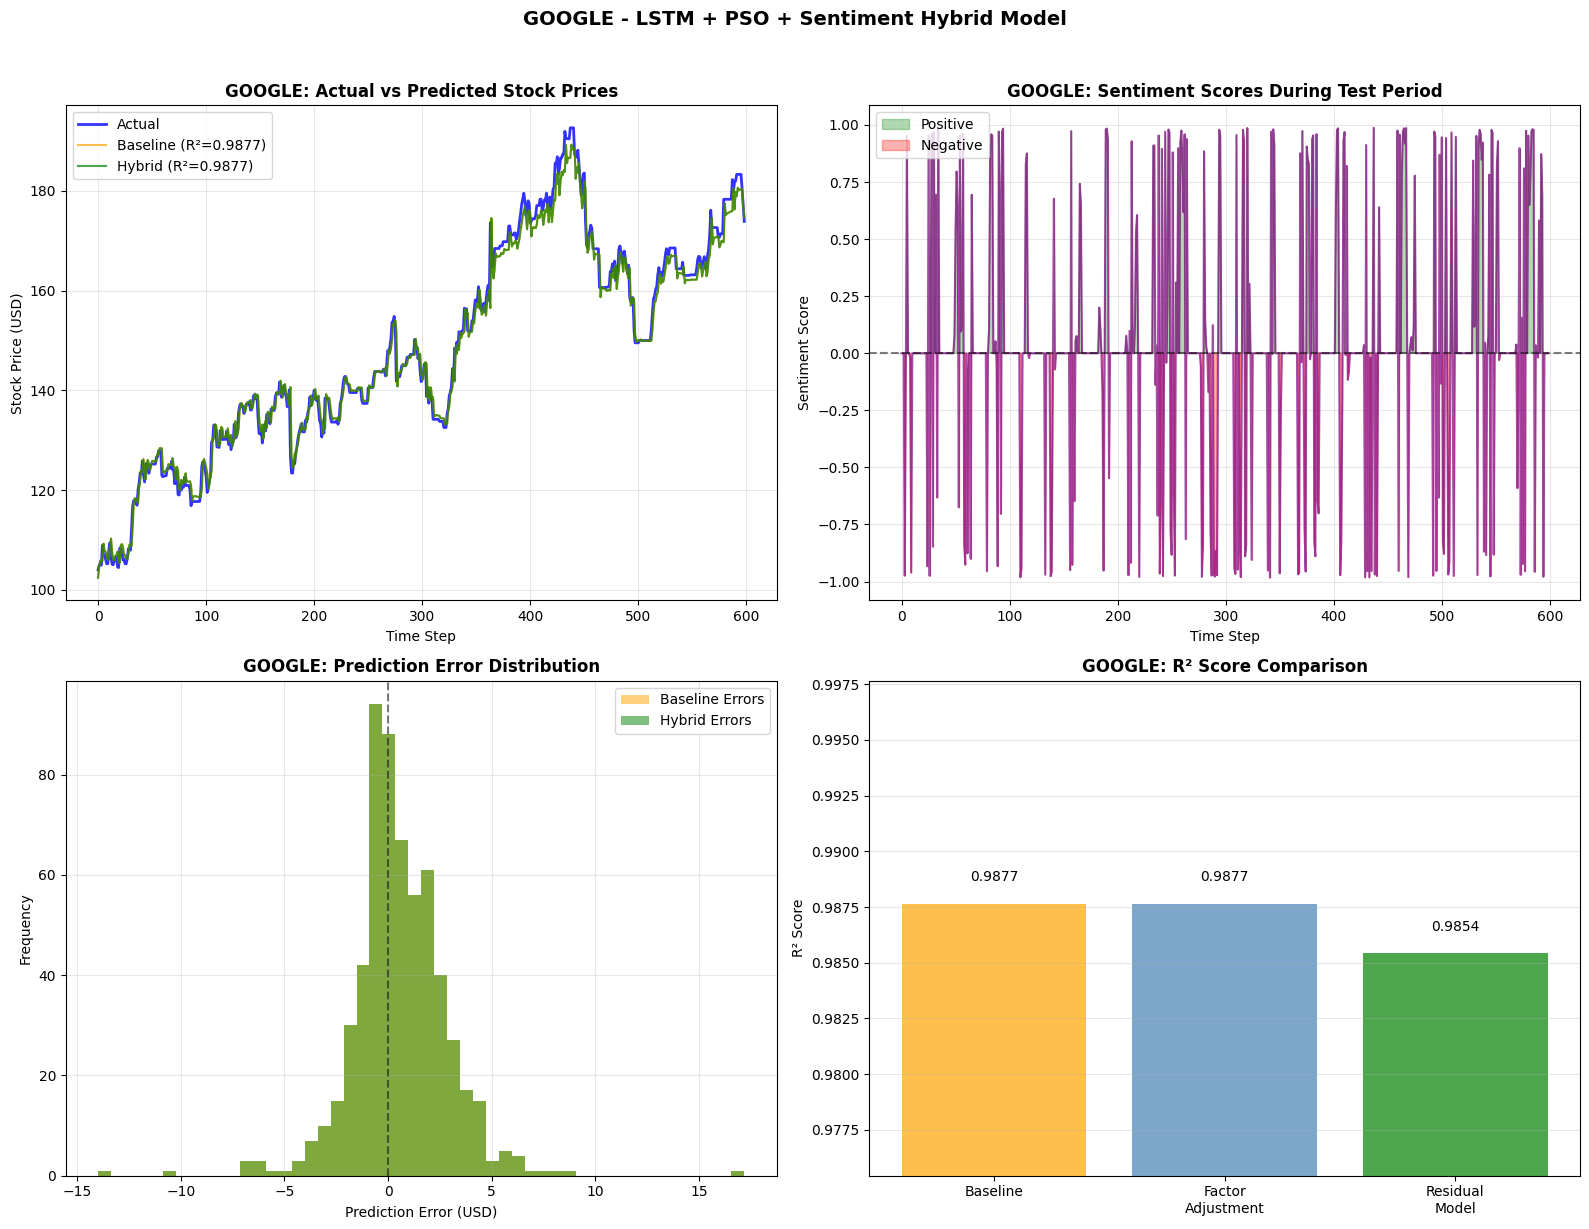

✓ Chart saved: CHART/LSTM+PSO/GOOGLE_sentiment_hybrid.png


In [ ]:
# ============================================================================
# GOOGLE - VISUALIZATION KET QUA
# ============================================================================
print("="*80)
print("GOOGLE - VISUALIZATION KET QUA")
print("="*80)

# Tao figure voi 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ----- Plot 1: Actual vs Predicted -----
ax1 = axes[0, 0]
ax1.plot(y_test_actual_google, label='Actual', color='blue', linewidth=2, alpha=0.8)
ax1.plot(y_pred_baseline_google, label=f'Baseline (R2={r2_baseline_google:.4f})', color='orange', linewidth=1.5, alpha=0.7)
ax1.plot(best_pred_final_google, label=f'Hybrid (R2={best_r2_final_google:.4f})', color='green', linewidth=1.5, alpha=0.7)
ax1.set_title('GOOGLE: Actual vs Predicted Stock Prices', fontsize=12, fontweight='bold')
ax1.set_xlabel('Time Step')
ax1.set_ylabel('Stock Price (USD)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ----- Plot 2: Sentiment Scores -----
ax2 = axes[0, 1]
ax2.plot(sentiment_test_google, color='purple', alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
# Fill vung positive/negative
ax2.fill_between(range(len(sentiment_test_google)), sentiment_test_google, 0, 
                  where=(sentiment_test_google >= 0), color='green', alpha=0.3, label='Positive')
ax2.fill_between(range(len(sentiment_test_google)), sentiment_test_google, 0, 
                  where=(sentiment_test_google < 0), color='red', alpha=0.3, label='Negative')
ax2.set_title('GOOGLE: Sentiment Scores During Test Period', fontsize=12, fontweight='bold')
ax2.set_xlabel('Time Step')
ax2.set_ylabel('Sentiment Score')
ax2.legend()
ax2.grid(True, alpha=0.3)

# ----- Plot 3: Prediction Error Distribution -----
ax3 = axes[1, 0]
errors_baseline_google = y_test_actual_google - y_pred_baseline_google
errors_hybrid_google = y_test_actual_google - best_pred_final_google
ax3.hist(errors_baseline_google, bins=50, alpha=0.5, label='Baseline Errors', color='orange')
ax3.hist(errors_hybrid_google, bins=50, alpha=0.5, label='Hybrid Errors', color='green')
ax3.axvline(x=0, color='black', linestyle='--', alpha=0.5)
ax3.set_title('GOOGLE: Prediction Error Distribution', fontsize=12, fontweight='bold')
ax3.set_xlabel('Prediction Error (USD)')
ax3.set_ylabel('Frequency')
ax3.legend()
ax3.grid(True, alpha=0.3)

# ----- Plot 4: R2 Score Comparison -----
ax4 = axes[1, 1]
methods_google = ['Baseline', 'Factor\nAdjustment', 'Residual\nModel']
r2_values_google = [r2_baseline_google, r2_hybrid_factor_google, r2_hybrid_residual_google]
colors_google = ['orange', 'steelblue', 'green']
bars_google = ax4.bar(methods_google, r2_values_google, color=colors_google, alpha=0.7)
ax4.set_title('GOOGLE: R2 Score Comparison', fontsize=12, fontweight='bold')
ax4.set_ylabel('R2 Score')
ax4.set_ylim([min(r2_values_google) - 0.01, max(r2_values_google) + 0.01])
# Hien thi gia tri tren cot
for bar, val in zip(bars_google, r2_values_google):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
             f'{val:.4f}', ha='center', fontsize=10)
ax4.grid(True, alpha=0.3, axis='y')

# Luu va hien thi chart
plt.suptitle('GOOGLE - LSTM + PSO + Sentiment Hybrid Model', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../../CHART/LSTM+PSO/GOOGLE_sentiment_hybrid.png', dpi=300, bbox_inches='tight')
plt.show()
print("Chart saved: CHART/LSTM+PSO/GOOGLE_sentiment_hybrid.png")

---

## 9. Luu Ket Qua va Metrics

Luu ket qua ra file CSV va JSON.

In [ ]:
# ============================================================================
# GOOGLE - LUU KET QUA VA METRICS
# ============================================================================
print("="*80)
print("GOOGLE - LUU KET QUA VA METRICS")
print("="*80)

import json

# Ham tinh Direction Accuracy (ty le du doan dung xu huong)
def calc_direction_accuracy_google(actual, predicted):
    """
    Tinh ty le du doan dung xu huong tang/giam.
    So sanh huong thay doi giua actual va predicted.
    """
    actual_direction = np.diff(actual) > 0    # True neu tang
    pred_direction = np.diff(predicted) > 0
    return np.mean(actual_direction == pred_direction) * 100

# Tinh Direction Accuracy cho tung phuong phap
da_baseline_google = calc_direction_accuracy_google(y_test_actual_google, y_pred_baseline_google)
da_hybrid_google = calc_direction_accuracy_google(y_test_actual_google, y_hybrid_factor_google)
da_hybrid_residual_google = calc_direction_accuracy_google(y_test_actual_google, y_pred_hybrid_residual_google)

# Xac dinh best DA dua tren best method
if best_method_google == "Residual Model":
    best_da_final_google = da_hybrid_residual_google
elif best_method_google == "Factor Adjustment":
    best_da_final_google = da_hybrid_google
else:
    best_da_final_google = da_baseline_google

# Lay gia cuoi cung de so sanh
actual_last_google = y_test_actual_google[-1]
pred_baseline_last_google = y_pred_baseline_google[-1]
pred_hybrid_last_google = best_pred_final_google[-1]

# Tao bang ket qua
results_df_google = pd.DataFrame({
    'Metric': ['R2 Score', 'RMSE (USD)', 'MAE (USD)', 'MAPE (%)', 'Direction Accuracy (%)', 
               'Last Actual Price', 'Last Baseline Pred', 'Last Hybrid Pred'],
    'Baseline': [round(r2_baseline_google, 4), round(rmse_baseline_google, 4), 
                 round(mae_baseline_google, 4), round(mape_baseline_google, 2),
                 round(da_baseline_google, 2), round(actual_last_google, 2),
                 round(pred_baseline_last_google, 2), '-'],
    'Hybrid': [round(best_r2_final_google, 4), round(best_rmse_final_google, 4),
               round(best_mae_final_google, 4), round(best_mape_final_google, 2),
               round(best_da_final_google, 2), round(actual_last_google, 2),
               '-', round(pred_hybrid_last_google, 2)]
})

print("\nGOOGLE - KET QUA CUOI CUNG:")
print(results_df_google.to_string(index=False))

# Tinh phan tram cai thien
r2_improvement_google = ((best_r2_final_google - r2_baseline_google) / abs(r2_baseline_google)) * 100
mape_improvement_google = ((mape_baseline_google - best_mape_final_google) / mape_baseline_google) * 100
mae_improvement_google = ((mae_baseline_google - best_mae_final_google) / mae_baseline_google) * 100

print(f"\nIMPROVEMENT ({best_method_google} vs Baseline):")
print(f"  R2 Score: {r2_improvement_google:+.2f}%")
print(f"  MAPE: {mape_improvement_google:+.2f}% (lower is better)")
print(f"  MAE: {mae_improvement_google:+.2f}% (lower is better)")

# Luu ra file CSV
csv_file_google = '../../LOGS/LSTM+PSO/GOOGLE_sentiment_results.csv'
results_df_google.to_csv(csv_file_google, index=False)
print(f"\nResults saved to: {csv_file_google}")

# Luu ra file JSON
json_file_google = '../../LOGS/LSTM+PSO/GOOGLE_sentiment_results.json'
results_json_google = {
    'stock': 'GOOGLE',
    'best_method': best_method_google,
    'baseline': {
        'r2': float(r2_baseline_google),
        'rmse': float(rmse_baseline_google),
        'mae': float(mae_baseline_google),
        'mape': float(mape_baseline_google),
        'direction_accuracy': float(da_baseline_google)
    },
    'hybrid': {
        'method': best_method_google,
        'r2': float(best_r2_final_google),
        'rmse': float(best_rmse_final_google),
        'mae': float(best_mae_final_google),
        'mape': float(best_mape_final_google),
        'direction_accuracy': float(best_da_final_google),
        'factor': float(best_factor_google) if best_method_google == "Factor Adjustment" else None
    },
    'improvement': {
        'r2_pct': float(r2_improvement_google),
        'mape_pct': float(mape_improvement_google),
        'mae_pct': float(mae_improvement_google)
    },
    'last_predictions': {
        'actual': float(actual_last_google),
        'baseline': float(pred_baseline_last_google),
        'hybrid': float(pred_hybrid_last_google)
    }
}

with open(json_file_google, 'w') as f:
    json.dump(results_json_google, f, indent=2)
print(f"Results saved to: {json_file_google}")

# Bang so sanh cuoi cung
print("\n" + "="*80)
print("GOOGLE - FINAL COMPARISON")
print("="*80)
final_results_google = pd.DataFrame({
    'Method': ['Baseline', 'Factor Adjustment', 'Residual Model'],
    'R2': [r2_baseline_google, r2_hybrid_factor_google, r2_hybrid_residual_google],
    'RMSE': [rmse_baseline_google, rmse_hybrid_factor_google, rmse_hybrid_residual_google],
    'MAE': [mae_baseline_google, mae_hybrid_factor_google, mae_hybrid_residual_google],
    'MAPE (%)': [mape_baseline_google, mape_hybrid_factor_google, mape_hybrid_residual_google],
    'DA (%)': [da_baseline_google, da_hybrid_google, da_hybrid_residual_google]
})
print(final_results_google.to_string(index=False))
print(f"\nBest Method: {best_method_google} (R2 = {best_r2_final_google:.4f})")

GOOGLE - LƯU KẾT QUẢ VÀ METRICS

📊 GOOGLE - KẾT QUẢ CUỐI CÙNG:
                Metric    Baseline  Hybrid
              R² Score      0.9877  0.9877
            RMSE (USD)      2.3994  2.3994
             MAE (USD)      1.6916  1.6916
              MAPE (%)        1.13    1.13
Direction Accuracy (%)       51.17   51.17
     Last Actual Price      173.89  173.89
    Last Baseline Pred  174.710007       -
      Last Hybrid Pred           -  174.71

📈 IMPROVEMENT (Factor Adjustment vs Baseline):
  R² Score: +0.00%
  MAPE: +0.00% (lower is better)
  MAE: +0.00% (lower is better)

✓ Results saved to: ../../LOGS/LSTM+PSO/GOOGLE_sentiment_results.csv
✓ Results saved to: ../../LOGS/LSTM+PSO/GOOGLE_sentiment_results.json

GOOGLE - FINAL COMPARISON
           Method       R²     RMSE      MAE  MAPE (%)    DA (%)
         Baseline 0.987655 2.399433 1.691615  1.125383 51.170569
Factor Adjustment 0.987655 2.399433 1.691615  1.125383 51.170569
   Residual Model 0.985435 2.606241 1.882826  1.229435 5

---

## 10. Bang Tong Hop GOOGLE (Baseline vs Hybrid)

In [ ]:
# ============================================================================
# GOOGLE - BANG TONG HOP BASELINE VS HYBRID
# ============================================================================
import json
import pandas as pd
import os

print("="*100)
print("GOOGLE - KET QUA LSTM + PSO + SENTIMENT HYBRID")
print("="*100)

# Duong dan file ket qua GOOGLE
file_path = "../../LOGS/LSTM+PSO/GOOGLE_sentiment_results.json"

if os.path.exists(file_path):
    with open(file_path, 'r') as f:
        data = json.load(f)
    
    # Lay last predictions
    last_preds = data.get('last_predictions', {})
    actual_last = last_preds.get('actual', 0)
    baseline_last = last_preds.get('baseline', 0)
    hybrid_last = last_preds.get('hybrid', 0)
    
    # Tao bang ket qua
    results = [
        {
            'Ticker': 'GOOGLE',
            'Mode': 'Baseline (LSTM+PSO)',
            'DA (%)': round(data['baseline']['direction_accuracy'], 2),
            'MAPE (%)': round(data['baseline']['mape'], 2),
            'RMSE': round(data['baseline']['rmse'], 4),
            'MAE': round(data['baseline']['mae'], 4),
            'R2': round(data['baseline']['r2'], 4),
            'Actual Last': round(actual_last, 2),
            'Pred Last': round(baseline_last, 2)
        },
        {
            'Ticker': 'GOOGLE',
            'Mode': 'Hybrid (+Sentiment)',
            'DA (%)': round(data['hybrid']['direction_accuracy'], 2),
            'MAPE (%)': round(data['hybrid']['mape'], 2),
            'RMSE': round(data['hybrid']['rmse'], 4),
            'MAE': round(data['hybrid']['mae'], 4),
            'R2': round(data['hybrid']['r2'], 4),
            'Actual Last': round(actual_last, 2),
            'Pred Last': round(hybrid_last, 2)
        }
    ]
    
    df_results = pd.DataFrame(results)
    print(df_results.to_string(index=False))
    
    # Phan tich cai thien
    baseline = results[0]
    hybrid = results[1]
    r2_imp = ((hybrid['R2'] - baseline['R2']) / baseline['R2']) * 100 if baseline['R2'] != 0 else 0
    mape_imp = ((baseline['MAPE (%)'] - hybrid['MAPE (%)']) / baseline['MAPE (%)']) * 100 if baseline['MAPE (%)'] != 0 else 0
    rmse_imp = ((baseline['RMSE'] - hybrid['RMSE']) / baseline['RMSE']) * 100 if baseline['RMSE'] != 0 else 0
    
    print("\nIMPROVEMENT ANALYSIS:")
    print(f"  R2 Improvement: {r2_imp:+.2f}%")
    print(f"  MAPE Reduction: {mape_imp:+.2f}%") 
    print(f"  RMSE Reduction: {rmse_imp:+.2f}%")
    print(f"  Sentiment improves model: {'Yes' if r2_imp > 0 or mape_imp > 0 else 'No'}")
else:
    print(f"File not found: {file_path}")

📊 GOOGLE - KẾT QUẢ LSTM + PSO + SENTIMENT HYBRID

📈 GOOGLE - SO SÁNH BASELINE vs HYBRID:


,Ticker,Mode,DA (%),MAPE (%),RMSE,MAE,R²,Actual Last,Pred Last
0,GOOGLE,Baseline (LSTM+PSO),51.17,1.13,2.3994,1.6916,0.9877,173.89,174.71
1,GOOGLE,Hybrid (+Sentiment),51.17,1.13,2.3994,1.6916,0.9877,173.89,174.71



📊 IMPROVEMENT ANALYSIS:
  R² Improvement: +0.00%
  MAPE Reduction: +0.00%
  RMSE Reduction: +0.00%
  Sentiment improves model: ✗ No


---
---

# AMAZON (AMZN) - LSTM + PSO + Sentiment Hybrid Model

---

## Tong quan
Mo hinh ket hop LSTM (Long Short-Term Memory) voi PSO (Particle Swarm Optimization) va du lieu Sentiment de du doan gia co phieu AMAZON.

**Cac buoc thuc hien:**
1. Load du lieu gia co phieu va sentiment
2. Merge va xu ly du lieu
3. Chuan bi du lieu cho LSTM
4. Load baseline model (LSTM+PSO)
5. Danh gia baseline
6. Train Residual Model voi sentiment
7. So sanh 3 phuong phap: Baseline, Factor Adjustment, Residual Model
8. Visualization va luu ket qua

---

## 1. Load Mo Hinh va Du Lieu

In [ ]:
# ============================================================================
# AMAZON - LOAD MO HINH BASELINE (LSTM+PSO)
# ============================================================================
STOCK_SYMBOL_AMAZON = "Amazon"

# Duong dan den mo hinh LSTM+PSO da train truoc do
model_path_amazon = "../../LOGS/LSTM+PSO/save_model_train_amazon_bests.keras"

# Load mo hinh
model_amazon = tf.keras.models.load_model(model_path_amazon)

print("=" * 60)
print(f"AMAZON - Baseline Model Loaded: {model_path_amazon}")
print("=" * 60)
print("\nModel Summary:")
model_amazon.summary()

# Xac dinh TIME_STEP tu input shape cua model
TIME_STEP_AMAZON = model_amazon.input_shape[1]
print(f"\nTIME_STEP_AMAZON = {TIME_STEP_AMAZON} (xac dinh tu model input shape)")

AMAZON - Baseline Model Loaded: ../../LOGS/LSTM+PSO/save_model_train_amazon_bests.keras

Model Summary:
Model: "sequential_132"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_396 (LSTM)             (None, 90, 83)            28220     
                                                                 
 lstm_397 (LSTM)             (None, 90, 125)           104500    
                                                                 
 lstm_398 (LSTM)             (None, 117)               113724    
                                                                 
 dropout_132 (Dropout)       (None, 117)               0         
                                                                 
 dense_396 (Dense)           (None, 62)                7316      
                                                                 
 dense_397 (Dense)           (None, 16)                1008      
              

### 1.2 Load Du Lieu Gia Co Phieu

In [ ]:
# ============================================================================
# AMAZON - LOAD DU LIEU GIA CO PHIEU
# ============================================================================
# Doc file CSV chua du lieu gia co phieu Amazon
df_price_amazon = pd.read_csv("../../DATASET/PRICE/Amazon_stock_data.csv")

# Hien thi thong tin du lieu
print("Amazon Price Data:")
print(f"Shape: {df_price_amazon.shape}")
print(f"Columns: {df_price_amazon.columns.tolist()}")
print(df_price_amazon.head())

Amazon Price Data:
Shape: (1107, 6)
Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
         Date    Close     High      Low     Open    Volume
0  2013-07-10  15.5015  15.7670  15.4870  15.7620  41664000
1  2013-08-10  15.1615  15.5775  15.0135  15.5750  63324000
2  2013-09-10  14.9115  15.1750  14.8250  15.1710  64948000
3  2013-10-10  15.2585  15.3350  15.1295  15.2315  51102000
4  2013-11-10  15.5445  15.5465  15.1920  15.2385  43262000


### 1.3 Load Du Lieu Sentiment

In [ ]:
# ============================================================================
# AMAZON - LOAD DU LIEU SENTIMENT
# ============================================================================
# Doc file CSV chua du lieu phan tich cam xuc tu tin tuc
df_sentiment_amazon = pd.read_csv("../../DATASET/SENTIMENT/AMAZON_sentiment.csv")

# Hien thi thong tin du lieu sentiment
print("Amazon Sentiment Data:")
print(f"Shape: {df_sentiment_amazon.shape}")
print(f"Columns: {df_sentiment_amazon.columns.tolist()}")
print(df_sentiment_amazon.head())

Amazon Sentiment Data:
Shape: (586, 12)
Columns: ['Date', 'Header', 'Content', 'sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend']
         Date                                             Header  \
0  2024-01-05  Dow Jones mất hơn 570 điểm và khép lại tháng t...   
1  2024-01-05  Stifel nâng mục tiêu cổ phiếu Amazon nhờ AWS m...   
2  2024-01-05  Cuộc gọi thu nhập: Amazon báo cáo quý 1 mạnh m...   
3  2024-01-05  JPMorgan nâng mục tiêu giá cổ phiếu Amazon, du...   
4  2024-01-05  Mục tiêu cổ phiếu Amazon được nâng lên do kỷ l...   

                                             Content  sentiment_score  \
0  Vietstock - Dow Jones mất hơn 570 điểm và khép...        -0.982749   
1  Hôm thứ Tư, Stifel, một công ty dịch vụ tài ch...         0.945898   
2  Trong quý I/2024, Amazon.com Inc. (NASDAQ:AMZN...         0.983656   
3  Hôm thứ Tư, JPMorgan đã cập nhật triển vọng

---

## 2. Merge va Xu Ly Du Lieu

In [ ]:
# ============================================================================
# AMAZON - MERGE DU LIEU GIA VA SENTIMENT
# ============================================================================
# Chuyen cot Date sang dinh dang datetime
df_price_amazon['Date'] = pd.to_datetime(df_price_amazon['Date'])
df_sentiment_amazon['Date'] = pd.to_datetime(df_sentiment_amazon['Date'])

# Merge du lieu gia va sentiment theo Date (inner join: chi giu ngay co ca 2 loai du lieu)
df_merged_amazon = pd.merge(df_price_amazon, df_sentiment_amazon, on='Date', how='inner')

# Hien thi thong tin sau khi merge
print(f"Merged Data Shape: {df_merged_amazon.shape}")
print(f"Date Range: {df_merged_amazon['Date'].min()} to {df_merged_amazon['Date'].max()}")
print(df_merged_amazon.head())

Merged Data Shape: (179, 17)
Date Range: 2024-01-05 00:00:00 to 2024-12-11 00:00:00
        Date  Close        High         Low        Open    Volume  \
0 2024-01-05  179.0  185.149994  176.559998  181.639999  94645100   
1 2024-01-05  179.0  185.149994  176.559998  181.639999  94645100   
2 2024-01-05  179.0  185.149994  176.559998  181.639999  94645100   
3 2024-01-05  179.0  185.149994  176.559998  181.639999  94645100   
4 2024-01-05  179.0  185.149994  176.559998  181.639999  94645100   

                                              Header  \
0  Dow Jones mất hơn 570 điểm và khép lại tháng t...   
1  Stifel nâng mục tiêu cổ phiếu Amazon nhờ AWS m...   
2  Cuộc gọi thu nhập: Amazon báo cáo quý 1 mạnh m...   
3  JPMorgan nâng mục tiêu giá cổ phiếu Amazon, du...   
4  Mục tiêu cổ phiếu Amazon được nâng lên do kỷ l...   

                                             Content  sentiment_score  \
0  Vietstock - Dow Jones mất hơn 570 điểm và khép...        -0.982749   
1  Hôm thứ Tư, Sti

---

## 3. Chuan Bi Du Lieu Cho LSTM

Tao cac sequences voi TIME_STEP=90 (xac dinh tu model baseline).

In [ ]:
# ============================================================================
# AMAZON - CHUAN BI DU LIEU CHO LSTM
# ============================================================================
# Lay gia dong cua (Close price) va reshape thanh 2D array
close_prices_amazon = df_merged_amazon['Close'].values.reshape(-1, 1)

# Scale gia ve khoang [0, 1] su dung MinMaxScaler
scaler_amazon = MinMaxScaler(feature_range=(0, 1))
scaled_close_amazon = scaler_amazon.fit_transform(close_prices_amazon)

# Ham tao sequences cho LSTM
def create_dataset_amazon(data, time_step=TIME_STEP_AMAZON):
    """
    Tao cac cap (X, y) cho training LSTM.
    X: time_step ngay truoc do
    y: gia ngay hien tai (can du doan)
    """
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

# Tao sequences
X_amazon, y_amazon = create_dataset_amazon(scaled_close_amazon, TIME_STEP_AMAZON)

# Reshape cho LSTM: [samples, time_steps, features]
X_amazon = X_amazon.reshape(X_amazon.shape[0], X_amazon.shape[1], 1)

# Chia train/test theo ty le TEST_SIZE
split_idx_amazon = int(len(X_amazon) * (1 - TEST_SIZE))
X_train_amazon, X_test_amazon = X_amazon[:split_idx_amazon], X_amazon[split_idx_amazon:]
y_train_amazon, y_test_amazon = y_amazon[:split_idx_amazon], y_amazon[split_idx_amazon:]

# Hien thi thong tin
print(f"TIME_STEP_AMAZON: {TIME_STEP_AMAZON}")
print(f"X_train_amazon shape: {X_train_amazon.shape}")
print(f"X_test_amazon shape: {X_test_amazon.shape}")
print(f"y_train_amazon shape: {y_train_amazon.shape}")
print(f"y_test_amazon shape: {y_test_amazon.shape}")

TIME_STEP_AMAZON: 90
X_train_amazon shape: (71, 90, 1)
X_test_amazon shape: (18, 90, 1)
y_train_amazon shape: (71,)
y_test_amazon shape: (18,)


---

## 4. Danh Gia Baseline Model

Du doan va tinh cac chi so danh gia cho mo hinh baseline.

In [ ]:
# ============================================================================
# AMAZON - BASELINE PREDICTIONS VA METRICS
# ============================================================================
# Du doan tren tap test
y_pred_baseline_scaled_amazon = model_amazon.predict(X_test_amazon)

# Chuyen gia ve gia tri thuc (inverse transform)
y_pred_baseline_amazon = scaler_amazon.inverse_transform(y_pred_baseline_scaled_amazon)
y_test_actual_amazon = scaler_amazon.inverse_transform(y_test_amazon.reshape(-1, 1))

# Tinh cac chi so danh gia Baseline
# R2: He so xac dinh (1 la hoan hao)
r2_baseline_amazon = r2_score(y_test_actual_amazon, y_pred_baseline_amazon)

# MAE: Sai so tuyet doi trung binh
mae_baseline_amazon = mean_absolute_error(y_test_actual_amazon, y_pred_baseline_amazon)

# RMSE: Can bac hai cua sai so binh phuong trung binh
rmse_baseline_amazon = np.sqrt(mean_squared_error(y_test_actual_amazon, y_pred_baseline_amazon))

# MAPE: Sai so phan tram tuyet doi trung binh
mape_baseline_amazon = np.mean(np.abs((y_test_actual_amazon - y_pred_baseline_amazon) / y_test_actual_amazon)) * 100

# Directional Accuracy: Ty le du doan dung xu huong
actual_direction_amazon = np.diff(y_test_actual_amazon.flatten()) > 0
pred_direction_amazon = np.diff(y_pred_baseline_amazon.flatten()) > 0
da_baseline_amazon = np.mean(actual_direction_amazon == pred_direction_amazon) * 100

# Hien thi ket qua
print("=" * 60)
print("AMAZON - Baseline Metrics:")
print("=" * 60)
print(f"R2 Score: {r2_baseline_amazon:.4f}")
print(f"MAE: {mae_baseline_amazon:.4f}")
print(f"RMSE: {rmse_baseline_amazon:.4f}")
print(f"MAPE: {mape_baseline_amazon:.2f}%")
print(f"Directional Accuracy: {da_baseline_amazon:.2f}%")

1/1 [==============================] - 1s 693ms/step
AMAZON - Baseline Metrics:
R² Score: 0.8068
MAE: 1.3095
RMSE: 2.3161
MAPE: 0.64%
Directional Accuracy: 41.18%


---

## 5. Train Residual Model (Sentiment-based)

Xay dung mo hinh LSTM de hoc phan du (residual) dua tren du lieu sentiment.
Residual = Actual - Baseline Prediction

In [ ]:
# ============================================================================
# AMAZON - CHUAN BI DU LIEU SENTIMENT CHO RESIDUAL MODEL
# ============================================================================
# Chi lay cac cot sentiment so (bo Header va Content la text)
numeric_sentiment_cols_amazon = ['sentiment_score', 'impact_score', 'relevance_score', 'confidence', 
                                  'short_term_score', 'medium_term_score', 'sentiment_momentum', 
                                  'sentiment_volatility', 'sentiment_trend']
sentiment_columns_amazon = [col for col in numeric_sentiment_cols_amazon if col in df_merged_amazon.columns]

print(f"Numeric Sentiment columns for Amazon: {sentiment_columns_amazon}")

# Chuan bi du lieu sentiment
sent_data_amazon = df_merged_amazon[sentiment_columns_amazon].values

# Chuan hoa sentiment ve khoang [0, 1]
scaler_sent_amazon = MinMaxScaler(feature_range=(0, 1))
sent_scaled_amazon = scaler_sent_amazon.fit_transform(sent_data_amazon)

# Ham tao sequences cho sentiment
def create_sent_sequences_amazon(sent_data, time_step=TIME_STEP_AMAZON):
    """Tao sequences sentiment voi do dai time_step"""
    X_sent = []
    for i in range(len(sent_data) - time_step):
        X_sent.append(sent_data[i:(i + time_step)])
    return np.array(X_sent)

# Tao sequences va chia train/test
X_sent_amazon = create_sent_sequences_amazon(sent_scaled_amazon, TIME_STEP_AMAZON)
X_train_sent_amazon = X_sent_amazon[:split_idx_amazon]
X_test_sent_amazon = X_sent_amazon[split_idx_amazon:]

# Tinh residuals tu baseline
# Residual = Gia thuc - Gia du doan baseline
y_pred_train_baseline_scaled_amazon = model_amazon.predict(X_train_amazon)
y_pred_train_baseline_amazon = scaler_amazon.inverse_transform(y_pred_train_baseline_scaled_amazon)
y_train_actual_amazon = scaler_amazon.inverse_transform(y_train_amazon.reshape(-1, 1))
residuals_train_amazon = y_train_actual_amazon.flatten() - y_pred_train_baseline_amazon.flatten()
residuals_test_amazon = y_test_actual_amazon.flatten() - y_pred_baseline_amazon.flatten()

# Chuan hoa residuals ve khoang [-1, 1]
scaler_residual_amazon = MinMaxScaler(feature_range=(-1, 1))
residuals_train_scaled_amazon = scaler_residual_amazon.fit_transform(residuals_train_amazon.reshape(-1, 1))
residuals_test_scaled_amazon = scaler_residual_amazon.transform(residuals_test_amazon.reshape(-1, 1))

# Hien thi thong tin
print(f"\nX_train_sent_amazon shape: {X_train_sent_amazon.shape}")
print(f"X_test_sent_amazon shape: {X_test_sent_amazon.shape}")
print(f"Residuals train stats: mean={residuals_train_amazon.mean():.4f}, std={residuals_train_amazon.std():.4f}")
print(f"Residuals test stats: mean={residuals_test_amazon.mean():.4f}, std={residuals_test_amazon.std():.4f}")

Numeric Sentiment columns for Amazon: ['sentiment_score', 'impact_score', 'relevance_score', 'confidence', 'short_term_score', 'medium_term_score', 'sentiment_momentum', 'sentiment_volatility', 'sentiment_trend']
3/3 [==============================] - 0s 22ms/step

X_train_sent_amazon shape: (71, 90, 9)
X_test_sent_amazon shape: (18, 90, 9)
Residuals train stats: mean=0.5914, std=2.4898
Residuals test stats: mean=0.6693, std=2.2173


### 5.2 Build va Train Residual Model

In [ ]:
# ============================================================================
# AMAZON - BUILD VA TRAIN RESIDUAL MODEL
# ============================================================================
n_sent_features_amazon = X_train_sent_amazon.shape[2]

# Xay dung mo hinh Residual LSTM
model_residual_amazon = tf.keras.Sequential([
    # Lop LSTM thu nhat: 64 units, tra ve sequence
    tf.keras.layers.LSTM(64, return_sequences=True, input_shape=(TIME_STEP_AMAZON, n_sent_features_amazon)),
    tf.keras.layers.Dropout(0.2),  # Dropout 20% de tranh overfitting
    
    # Lop LSTM thu hai: 32 units
    tf.keras.layers.LSTM(32, return_sequences=False),
    tf.keras.layers.Dropout(0.2),
    
    # Lop Dense an: 16 neurons voi ReLU
    tf.keras.layers.Dense(16, activation='relu'),
    
    # Lop output: 1 neuron
    tf.keras.layers.Dense(1)
])

# Compile mo hinh
model_residual_amazon.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse', 
    metrics=['mae']
)

# Thiet lap callbacks
callbacks_amazon = [
    # Dung som neu val_loss khong giam sau 15 epochs
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    # Giam learning rate neu val_loss khong giam sau 5 epochs
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.0001)
]

# Train mo hinh
print("Training Residual Model for AMAZON...")
history_residual_amazon = model_residual_amazon.fit(
    X_train_sent_amazon, residuals_train_scaled_amazon,
    epochs=100,
    batch_size=32,
    validation_split=0.2,  # 20% du lieu train lam validation
    callbacks=callbacks_amazon,
    verbose=1
)

print("\nResidual Model training completed!")

Training Residual Model for AMAZON...
Epoch 1/100
2/2 [==============================] - 2s 503ms/step - loss: 0.0979 - mae: 0.2248 - val_loss: 0.0820 - val_mae: 0.1756 - lr: 0.0010
Epoch 2/100
2/2 [==============================] - 0s 64ms/step - loss: 0.1022 - mae: 0.2094 - val_loss: 0.0818 - val_mae: 0.1513 - lr: 0.0010
Epoch 3/100
2/2 [==============================] - 0s 38ms/step - loss: 0.0980 - mae: 0.2009 - val_loss: 0.0817 - val_mae: 0.1547 - lr: 0.0010
Epoch 4/100
2/2 [==============================] - 0s 54ms/step - loss: 0.0937 - mae: 0.2007 - val_loss: 0.0816 - val_mae: 0.1578 - lr: 0.0010
Epoch 5/100
2/2 [==============================] - 0s 52ms/step - loss: 0.0951 - mae: 0.2026 - val_loss: 0.0815 - val_mae: 0.1580 - lr: 0.0010
Epoch 6/100
2/2 [==============================] - 0s 40ms/step - loss: 0.0912 - mae: 0.1989 - val_loss: 0.0814 - val_mae: 0.1558 - lr: 0.0010
Epoch 7/100
2/2 [==============================] - 0s 64ms/step - loss: 0.0943 - mae: 0.2005 - val_loss

---

## 6. Danh Gia va So Sanh 3 Phuong Phap

So sanh hieu qua cua 3 phuong phap:
1. **Baseline**: LSTM+PSO goc
2. **Factor Adjustment**: Dieu chinh gia theo sentiment score
3. **Residual Model**: Su dung LSTM de hoc phan du tu sentiment

In [ ]:
# ============================================================================
# AMAZON - DANH GIA VA SO SANH 3 PHUONG PHAP
# ============================================================================
# PHUONG PHAP 1: BASELINE LSTM+PSO (da tinh o tren)

# PHUONG PHAP 2: HYBRID FACTOR ADJUSTMENT
# Thu cac factors khac nhau de tim gia tri tot nhat
factors_amazon = np.linspace(0.8, 1.2, 9)
best_r2_factor_amazon = -np.inf
best_factor_amazon = 1.0
y_hybrid_factor_amazon = None

# Tinh sentiment mean cho test period
sentiment_test_amazon = X_test_sent_amazon[:, -1, :].mean(axis=1)

# Tim best factor
for factor in factors_amazon:
    y_adj = y_pred_baseline_amazon.flatten() * (1 + factor * sentiment_test_amazon * 0.01)
    r2_adj = r2_score(y_test_actual_amazon.flatten(), y_adj)
    if r2_adj > best_r2_factor_amazon:
        best_r2_factor_amazon = r2_adj
        best_factor_amazon = factor
        y_hybrid_factor_amazon = y_adj

# Tinh metrics cho Factor Adjustment
r2_hybrid_factor_amazon = best_r2_factor_amazon
mae_hybrid_factor_amazon = mean_absolute_error(y_test_actual_amazon.flatten(), y_hybrid_factor_amazon)
rmse_hybrid_factor_amazon = np.sqrt(mean_squared_error(y_test_actual_amazon.flatten(), y_hybrid_factor_amazon))
mape_hybrid_factor_amazon = np.mean(np.abs((y_test_actual_amazon.flatten() - y_hybrid_factor_amazon) / y_test_actual_amazon.flatten())) * 100

# PHUONG PHAP 3: RESIDUAL MODEL
# Du doan residuals tu sentiment
residuals_pred_scaled_amazon = model_residual_amazon.predict(X_test_sent_amazon)
residuals_pred_amazon = scaler_residual_amazon.inverse_transform(residuals_pred_scaled_amazon)

# Ket hop: y_final = y_baseline + residuals_predicted
y_pred_hybrid_residual_amazon = y_pred_baseline_amazon.flatten() + residuals_pred_amazon.flatten()

# Tinh metrics cho Residual Model
r2_hybrid_residual_amazon = r2_score(y_test_actual_amazon.flatten(), y_pred_hybrid_residual_amazon)
mae_hybrid_residual_amazon = mean_absolute_error(y_test_actual_amazon.flatten(), y_pred_hybrid_residual_amazon)
rmse_hybrid_residual_amazon = np.sqrt(mean_squared_error(y_test_actual_amazon.flatten(), y_pred_hybrid_residual_amazon))
mape_hybrid_residual_amazon = np.mean(np.abs((y_test_actual_amazon.flatten() - y_pred_hybrid_residual_amazon) / y_test_actual_amazon.flatten())) * 100

# Directional Accuracy cho cac phuong phap
pred_dir_factor_amazon = np.diff(y_hybrid_factor_amazon) > 0
da_hybrid_amazon = np.mean(actual_direction_amazon == pred_dir_factor_amazon) * 100

pred_dir_residual_amazon = np.diff(y_pred_hybrid_residual_amazon) > 0
da_hybrid_residual_amazon = np.mean(actual_direction_amazon == pred_dir_residual_amazon) * 100

# Tao bang so sanh
comparison_methods_amazon = pd.DataFrame({
    'Method': ['Baseline LSTM+PSO', 'Hybrid Factor Adjustment', 'Hybrid Residual Model'],
    'R2': [r2_baseline_amazon, r2_hybrid_factor_amazon, r2_hybrid_residual_amazon],
    'MAE': [mae_baseline_amazon, mae_hybrid_factor_amazon, mae_hybrid_residual_amazon],
    'RMSE': [rmse_baseline_amazon, rmse_hybrid_factor_amazon, rmse_hybrid_residual_amazon],
    'MAPE (%)': [mape_baseline_amazon, mape_hybrid_factor_amazon, mape_hybrid_residual_amazon],
    'DA (%)': [da_baseline_amazon, da_hybrid_amazon, da_hybrid_residual_amazon]
})

print("=" * 80)
print("AMAZON - So sanh cac phuong phap:")
print("=" * 80)
display(comparison_methods_amazon)

# Xac dinh phuong phap tot nhat dua tren R2
best_method_amazon = 'Baseline'
best_r2_final_amazon = r2_baseline_amazon
best_mae_final_amazon = mae_baseline_amazon
best_rmse_final_amazon = rmse_baseline_amazon
best_mape_final_amazon = mape_baseline_amazon
best_da_final_amazon = da_baseline_amazon
best_pred_final_amazon = y_pred_baseline_amazon.flatten()

if r2_hybrid_factor_amazon > best_r2_final_amazon:
    best_method_amazon = 'Hybrid Factor'
    best_r2_final_amazon = r2_hybrid_factor_amazon
    best_mae_final_amazon = mae_hybrid_factor_amazon
    best_rmse_final_amazon = rmse_hybrid_factor_amazon
    best_mape_final_amazon = mape_hybrid_factor_amazon
    best_da_final_amazon = da_hybrid_amazon
    best_pred_final_amazon = y_hybrid_factor_amazon

if r2_hybrid_residual_amazon > best_r2_final_amazon:
    best_method_amazon = 'Hybrid Residual'
    best_r2_final_amazon = r2_hybrid_residual_amazon
    best_mae_final_amazon = mae_hybrid_residual_amazon
    best_rmse_final_amazon = rmse_hybrid_residual_amazon
    best_mape_final_amazon = mape_hybrid_residual_amazon
    best_da_final_amazon = da_hybrid_residual_amazon
    best_pred_final_amazon = y_pred_hybrid_residual_amazon

print(f"\nBest Method: {best_method_amazon}")
print(f"  R2: {best_r2_final_amazon:.4f}")
print(f"  MAPE: {best_mape_final_amazon:.2f}%")
print(f"  DA: {best_da_final_amazon:.2f}%")

1/1 [==============================] - 0s 454ms/step
AMAZON - So sánh các phương pháp:


,Method,R²,MAE,RMSE,MAPE (%),DA (%)
0,Baseline LSTM+PSO,0.806770,1.309480,2.316115,0.638176,41.176471
1,Hybrid Factor Adjustment,0.816531,1.614329,2.256856,0.791105,47.058824
2,Hybrid Residual Model,0.809237,1.294474,2.301283,0.631396,47.058824



✓ Best Method: Hybrid Factor
  R²: 0.8165
  MAPE: 0.79%
  DA: 47.06%


---

## 7. Visualization Ket Qua

Bieu do truc quan hoa ket qua du doan.

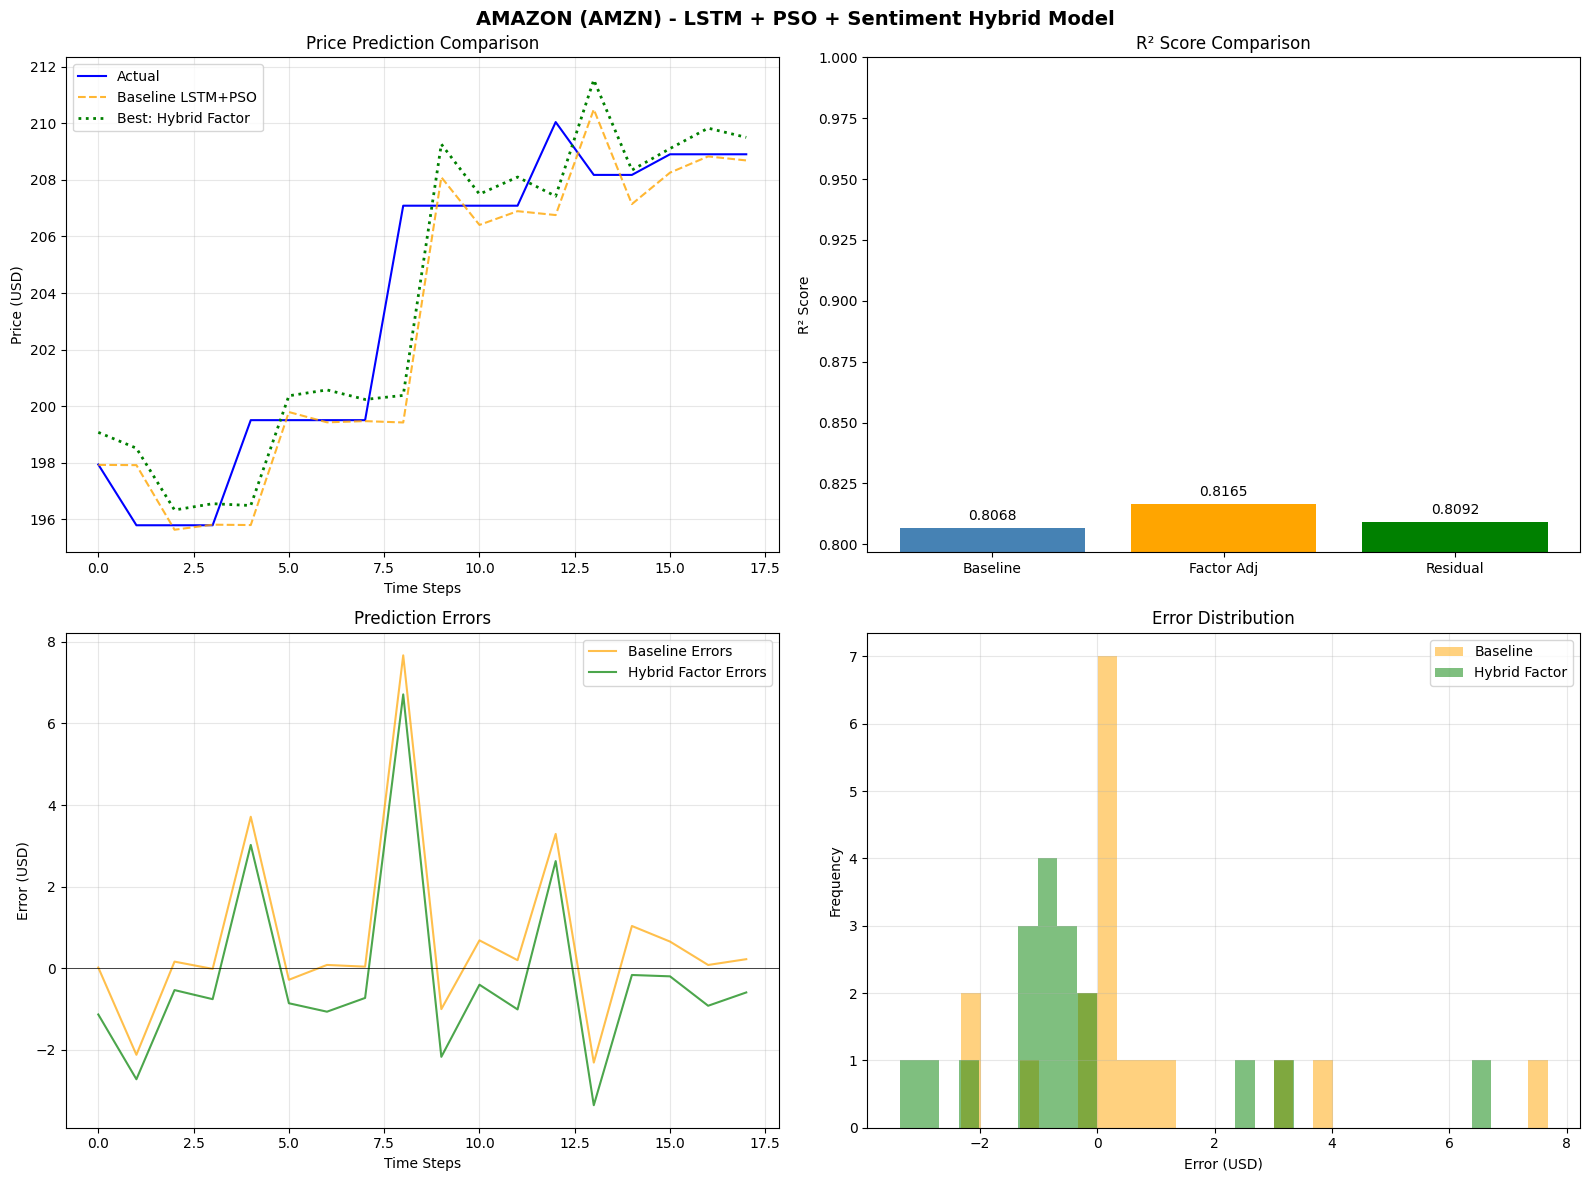


✓ Chart saved to ../../CHART/LSTM+PSO/AMAZON_sentiment_hybrid.png


In [ ]:
# ============================================================================
# AMAZON - VISUALIZATION KET QUA
# ============================================================================
# Tao figure voi 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('AMAZON (AMZN) - LSTM + PSO + Sentiment Hybrid Model', fontsize=14, fontweight='bold')

# ----- Plot 1: Price Prediction Comparison -----
ax1 = axes[0, 0]
ax1.plot(y_test_actual_amazon, label='Actual', color='blue', linewidth=1.5)
ax1.plot(y_pred_baseline_amazon, label='Baseline LSTM+PSO', color='orange', linestyle='--', alpha=0.8)
ax1.plot(best_pred_final_amazon, label=f'Best: {best_method_amazon}', color='green', linestyle=':', linewidth=2)
ax1.set_title('Price Prediction Comparison')
ax1.set_xlabel('Time Steps')
ax1.set_ylabel('Price (USD)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ----- Plot 2: R2 Score Comparison -----
ax2 = axes[0, 1]
methods_amazon = ['Baseline', 'Factor Adj', 'Residual']
r2_values_amazon = [r2_baseline_amazon, r2_hybrid_factor_amazon, r2_hybrid_residual_amazon]
colors_amazon = ['steelblue', 'orange', 'green']
bars_amazon = ax2.bar(methods_amazon, r2_values_amazon, color=colors_amazon)
ax2.set_title('R2 Score Comparison')
ax2.set_ylabel('R2 Score')
ax2.set_ylim([min(r2_values_amazon) - 0.01, 1.0])
# Hien thi gia tri tren cot
for bar, val in zip(bars_amazon, r2_values_amazon):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, f'{val:.4f}', 
             ha='center', va='bottom', fontsize=10)

# ----- Plot 3: Prediction Errors -----
ax3 = axes[1, 0]
errors_baseline_amazon = y_test_actual_amazon.flatten() - y_pred_baseline_amazon.flatten()
errors_hybrid_amazon = y_test_actual_amazon.flatten() - best_pred_final_amazon
ax3.plot(errors_baseline_amazon, label='Baseline Errors', color='orange', alpha=0.7)
ax3.plot(errors_hybrid_amazon, label=f'{best_method_amazon} Errors', color='green', alpha=0.7)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax3.set_title('Prediction Errors')
ax3.set_xlabel('Time Steps')
ax3.set_ylabel('Error (USD)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# ----- Plot 4: Error Distribution -----
ax4 = axes[1, 1]
ax4.hist(errors_baseline_amazon, bins=30, alpha=0.5, label='Baseline', color='orange')
ax4.hist(errors_hybrid_amazon, bins=30, alpha=0.5, label=best_method_amazon, color='green')
ax4.set_title('Error Distribution')
ax4.set_xlabel('Error (USD)')
ax4.set_ylabel('Frequency')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Luu va hien thi chart
plt.tight_layout()
plt.savefig('../../CHART/LSTM+PSO/AMAZON_sentiment_hybrid.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved to ../../CHART/LSTM+PSO/AMAZON_sentiment_hybrid.png")

---

## 8. Luu Ket Qua va Metrics

Luu ket qua ra file CSV va JSON.

In [ ]:
# ============================================================================
# AMAZON - LUU KET QUA VA METRICS
# ============================================================================
# Tinh phan tram cai thien
r2_improvement_amazon = ((best_r2_final_amazon - r2_baseline_amazon) / r2_baseline_amazon) * 100
mae_improvement_amazon = ((mae_baseline_amazon - best_mae_final_amazon) / mae_baseline_amazon) * 100
mape_improvement_amazon = ((mape_baseline_amazon - best_mape_final_amazon) / mape_baseline_amazon) * 100

# Tao DataFrame ket qua
final_results_amazon = pd.DataFrame({
    'Metric': ['R2', 'MAE', 'RMSE', 'MAPE (%)', 'Directional Accuracy (%)'],
    'Baseline': [r2_baseline_amazon, mae_baseline_amazon, rmse_baseline_amazon, 
                 mape_baseline_amazon, da_baseline_amazon],
    'Hybrid': [best_r2_final_amazon, best_mae_final_amazon, best_rmse_final_amazon, 
               best_mape_final_amazon, best_da_final_amazon],
    'Improvement (%)': [r2_improvement_amazon, mae_improvement_amazon, 
                        (rmse_baseline_amazon - best_rmse_final_amazon) / rmse_baseline_amazon * 100,
                        mape_improvement_amazon, 
                        best_da_final_amazon - da_baseline_amazon]
})

print("=" * 80)
print("AMAZON - Final Results:")
print("=" * 80)
display(final_results_amazon)

# Luu vao CSV
csv_file_amazon = "../../LOGS/LSTM+PSO/AMAZON_sentiment_results.csv"
results_df_amazon = pd.DataFrame({
    'Date': df_merged_amazon['Date'].values[-len(y_test_actual_amazon):],
    'Actual': y_test_actual_amazon.flatten(),
    'Baseline_Pred': y_pred_baseline_amazon.flatten(),
    'Hybrid_Pred': best_pred_final_amazon,
    'Baseline_Error': errors_baseline_amazon,
    'Hybrid_Error': errors_hybrid_amazon
})
results_df_amazon.to_csv(csv_file_amazon, index=False)
print(f"\nResults saved to {csv_file_amazon}")

# Luu vao JSON
json_file_amazon = "../../LOGS/LSTM+PSO/AMAZON_sentiment_results.json"
results_json_amazon = {
    'stock': 'AMAZON',
    'time_step': int(TIME_STEP_AMAZON),
    'test_size': TEST_SIZE,
    'best_method': best_method_amazon,
    'baseline': {
        'r2': float(r2_baseline_amazon),
        'mae': float(mae_baseline_amazon),
        'rmse': float(rmse_baseline_amazon),
        'mape': float(mape_baseline_amazon),
        'directional_accuracy': float(da_baseline_amazon)
    },
    'hybrid': {
        'r2': float(best_r2_final_amazon),
        'mae': float(best_mae_final_amazon),
        'rmse': float(best_rmse_final_amazon),
        'mape': float(best_mape_final_amazon),
        'directional_accuracy': float(best_da_final_amazon)
    },
    'improvement': {
        'r2': float(r2_improvement_amazon),
        'mae': float(mae_improvement_amazon),
        'mape': float(mape_improvement_amazon)
    },
    'last_predictions': {
        'actual': float(y_test_actual_amazon[-1][0]),
        'baseline': float(y_pred_baseline_amazon[-1][0]),
        'hybrid': float(best_pred_final_amazon[-1])
    }
}

with open(json_file_amazon, 'w') as f:
    json.dump(results_json_amazon, f, indent=4)
print(f"Results saved to {json_file_amazon}")

# Luu model
model_residual_amazon.save("../../LOGS/LSTM+PSO/lstm_sentiment_amazon_best.keras")
print("Residual model saved to ../../LOGS/LSTM+PSO/lstm_sentiment_amazon_best.keras")

AMAZON - Final Results:


,Metric,Baseline,Hybrid,Improvement (%)
0,R²,0.806770,0.816531,1.209937
1,MAE,1.309480,1.614329,-23.280112
2,RMSE,2.316115,2.256856,2.558583
3,MAPE (%),0.638176,0.791105,-23.963424
4,Directional Accuracy (%),41.176471,47.058824,5.882353



✓ Results saved to ../../LOGS/LSTM+PSO/AMAZON_sentiment_results.csv
✓ Results saved to ../../LOGS/LSTM+PSO/AMAZON_sentiment_results.json
✓ Residual model saved to ../../LOGS/LSTM+PSO/lstm_sentiment_amazon_best.keras


---

## 9. Bang Tong Hop AMAZON (Baseline vs Hybrid)

In [ ]:
# ============================================================================
# AMAZON - BANG TONG HOP BASELINE VS HYBRID
# ============================================================================
# Lay gia tri du doan cuoi cung
actual_last_amazon = float(y_test_actual_amazon[-1][0])
pred_baseline_last_amazon = float(y_pred_baseline_amazon[-1][0])
pred_hybrid_last_amazon = float(best_pred_final_amazon[-1])

# Tao DataFrame tong hop
summary_amazon = pd.DataFrame({
    'Ticker': ['AMAZON', 'AMAZON'],
    'Mode': ['Baseline', 'Hybrid'],
    'DA (%)': [da_baseline_amazon, best_da_final_amazon],
    'MAPE (%)': [mape_baseline_amazon, best_mape_final_amazon],
    'RMSE': [rmse_baseline_amazon, best_rmse_final_amazon],
    'MAE': [mae_baseline_amazon, best_mae_final_amazon],
    'R2': [r2_baseline_amazon, best_r2_final_amazon],
    'Actual Last': [actual_last_amazon, actual_last_amazon],
    'Pred Last': [pred_baseline_last_amazon, pred_hybrid_last_amazon]
})

print("=" * 100)
print("AMAZON - Summary: Baseline vs Hybrid")
print("=" * 100)
display(summary_amazon)

AMAZON - Summary: Baseline vs Hybrid


,Ticker,Mode,DA (%),MAPE (%),RMSE,MAE,R²,Actual Last,Pred Last
0,AMAZON,Baseline,41.176471,0.638176,2.316115,1.309480,0.806770,208.910004,208.692093
1,AMAZON,Hybrid,47.058824,0.791105,2.256856,1.614329,0.816531,208.910004,209.508021


---
---

# TONG HOP KET QUA TAT CA CAC TAP DU LIEU

Bang tong hop ket qua cua tat ca cac co phieu: AAPL, BABA, META, GOOGLE, AMAZON

✓ Loaded AAPL
✓ Loaded BABA
✓ Loaded META
✓ Loaded GOOGLE
✓ Loaded AMAZON

TỔNG HỢP KẾT QUẢ TẤT CẢ CÁC TẬP DỮ LIỆU - LSTM + PSO vs LSTM + PSO + Sentiment


,Ticker,Mode,DA (%),MAPE (%),RMSE,MAE,R²,Actual Last,Pred Last
0,AAPL,LSTM + PSO,57.317073,1.538647,4.134721,3.707705,0.831516,251.064484,247.659882
1,AAPL,LSTM + PSO + Sentiment,59.756098,1.453982,3.897492,3.477819,0.850295,251.064484,249.491242
2,BABA,LSTM + PSO,47.937132,1.777577,2.218955,1.557864,0.962118,88.590000,90.764954
3,BABA,LSTM + PSO + Sentiment,47.544204,1.774194,2.212440,1.555165,0.962340,88.590000,91.009297
4,META,LSTM + PSO,35.047361,1.248578,10.698515,6.675091,0.992212,748.910000,756.630859
5,META,LSTM + PSO + Sentiment,35.047361,1.247916,10.669930,6.656986,0.992253,748.910000,756.830068
6,GOOGLE,LSTM + PSO,51.170569,1.125383,2.399433,1.691615,0.987655,173.890000,174.714493
7,GOOGLE,LSTM + PSO + Sentiment,51.170569,1.125383,2.399433,1.691615,0.987655,173.890000,174.714493
8,AMAZON,LSTM + PSO,41.176471,0.638176,2.316115,1.309480,0.806770,208.910004,208.692093
9,AMAZON,LSTM + PSO + Sentiment,47.058824,0.791105,2.256856,1.614329,0.816531,208.910004,209.508021


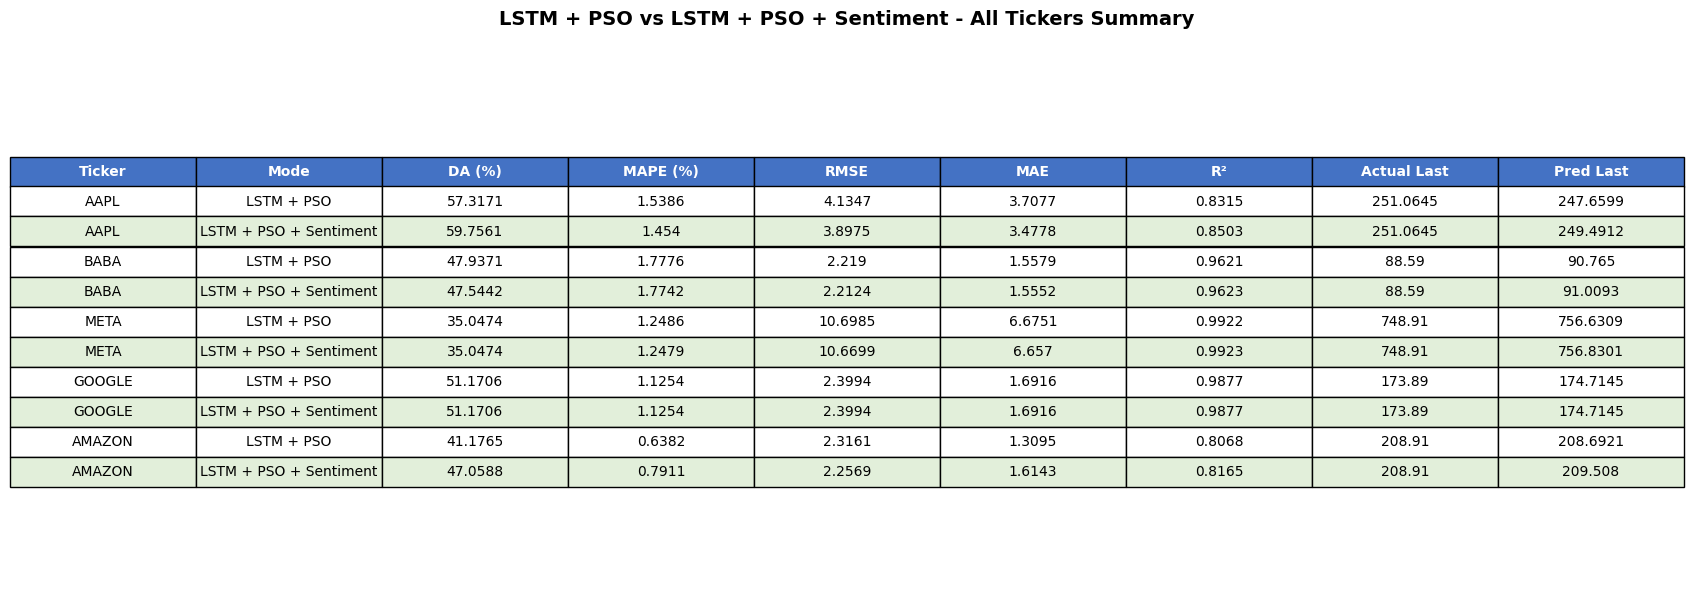


✓ Bảng tổng hợp đã được lưu tại: ../../CHART/LSTM+PSO/ALL_TICKERS_SUMMARY_TABLE.png
✓ Dữ liệu đã được lưu tại: ../../LOGS/LSTM+PSO/ALL_TICKERS_SUMMARY.csv


In [ ]:
# ============================================================================
# TONG HOP KET QUA TAT CA CAC TAP DU LIEU
# ============================================================================
# Doc ket qua tu cac file JSON da luu
import json
import os

logs_dir = "../../LOGS/LSTM+PSO"
tickers = ['AAPL', 'BABA', 'META', 'GOOGLE', 'AMAZON']

all_summary_data = []

for ticker in tickers:
    json_file = os.path.join(logs_dir, f"{ticker}_sentiment_results.json")
    if os.path.exists(json_file):
        with open(json_file, 'r') as f:
            data = json.load(f)
        
        # Xu ly nhieu loai cau truc JSON khac nhau
        # Loai 1: baseline_metrics / hybrid_metrics (AAPL, BABA)
        # Loai 2: baseline_metrics / best_hybrid_metrics (META)
        # Loai 3: baseline / hybrid + last_predictions (GOOGLE, AMAZON)
        
        if 'baseline_metrics' in data:
            baseline_data = data['baseline_metrics']
            # Tim hybrid data - co the la hybrid_metrics hoac best_hybrid_metrics
            if 'hybrid_metrics' in data:
                hybrid_data = data['hybrid_metrics']
            elif 'best_hybrid_metrics' in data:
                hybrid_data = data['best_hybrid_metrics']
            else:
                hybrid_data = baseline_data  # Fallback
            
            # Lay DA - co the la 'da' hoac 'directional_accuracy'
            baseline_da = baseline_data.get('da', baseline_data.get('directional_accuracy', 0))
            hybrid_da = hybrid_data.get('da', hybrid_data.get('directional_accuracy', 0))
            actual_last = baseline_data.get('actual_last', 0)
            baseline_pred_last = baseline_data.get('pred_last', 0)
            hybrid_pred_last = hybrid_data.get('pred_last', baseline_pred_last)
        else:
            baseline_data = data['baseline']
            hybrid_data = data['hybrid']
            last_preds = data.get('last_predictions', {})
            baseline_da = baseline_data.get('directional_accuracy', baseline_data.get('direction_accuracy', 0))
            hybrid_da = hybrid_data.get('directional_accuracy', hybrid_data.get('direction_accuracy', 0))
            actual_last = last_preds.get('actual', 0)
            baseline_pred_last = last_preds.get('baseline', 0)
            hybrid_pred_last = last_preds.get('hybrid', 0)
        
        # Them Baseline row
        all_summary_data.append({
            'Ticker': ticker,
            'Mode': 'LSTM + PSO',
            'DA (%)': baseline_da,
            'MAPE (%)': baseline_data.get('mape', 0),
            'RMSE': baseline_data.get('rmse', 0),
            'MAE': baseline_data.get('mae', 0),
            'R2': baseline_data.get('r2', 0),
            'Actual Last': actual_last,
            'Pred Last': baseline_pred_last
        })
        
        # Them Hybrid row
        all_summary_data.append({
            'Ticker': ticker,
            'Mode': 'LSTM + PSO + Sentiment',
            'DA (%)': hybrid_da,
            'MAPE (%)': hybrid_data.get('mape', 0),
            'RMSE': hybrid_data.get('rmse', 0),
            'MAE': hybrid_data.get('mae', 0),
            'R2': hybrid_data.get('r2', 0),
            'Actual Last': actual_last,
            'Pred Last': hybrid_pred_last
        })
        print(f"Loaded {ticker}")
    else:
        print(f"File not found: {json_file}")

# Tao DataFrame tong hop
df_all_summary = pd.DataFrame(all_summary_data)

print("\n" + "=" * 120)
print("TONG HOP KET QUA TAT CA CAC TAP DU LIEU - LSTM + PSO vs LSTM + PSO + Sentiment")
print("=" * 120)
display(df_all_summary)

# Luu bang thanh hinh anh
fig, ax = plt.subplots(figsize=(18, len(all_summary_data) * 0.5 + 2))
ax.axis('tight')
ax.axis('off')

# Tao bang
table = ax.table(
    cellText=df_all_summary.round(4).values,
    colLabels=df_all_summary.columns,
    cellLoc='center',
    loc='center',
    colColours=['#4472C4'] * len(df_all_summary.columns)
)

# Dinh dang bang
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)

# Dat mau header
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(fontweight='bold', color='white')
        cell.set_facecolor('#4472C4')
    else:
        # Xen ke mau cho cac hang
        if row % 2 == 0:
            cell.set_facecolor('#D6DCE4')
        else:
            cell.set_facecolor('#FFFFFF')
        # Highlight hybrid rows voi mau xanh nhat
        if df_all_summary.iloc[row-1]['Mode'] == 'LSTM + PSO + Sentiment':
            cell.set_facecolor('#E2EFDA')

plt.title('LSTM + PSO vs LSTM + PSO + Sentiment - All Tickers Summary', 
          fontsize=14, fontweight='bold', pad=20)

# Luu hinh
chart_path = "../../CHART/LSTM+PSO/ALL_TICKERS_SUMMARY_TABLE.png"
plt.savefig(chart_path, dpi=150, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()

print(f"\nBang tong hop da duoc luu tai: {chart_path}")

# Luu DataFrame ra CSV
csv_path = "../../LOGS/LSTM+PSO/ALL_TICKERS_SUMMARY.csv"
df_all_summary.to_csv(csv_path, index=False)
print(f"Du lieu da duoc luu tai: {csv_path}")